# 0. Importaciones y helpers reutilizables

Esta sección define únicamente herramientas reutilizables para el notebook.

La intención no es esconder la lógica de diseño de recompensa, sino evitar repetir operaciones mecánicas:
normalización, agregación, compuertas, simulación física básica del cart-pole y gráficos continuos.

El notebook conserva el mismo contrato del proyecto:

- registros planos por step;
- señales físicas con sufijo `_raw`;
- señales normalizadas con sufijo `_norm`;
- señales de control por lazo como `error_<var_obj>`, `derivative_error_<var_obj>`, `integral_error_<var_obj>` y `u_eff_<var_obj>`;
- componentes de recompensa como `L_e_<var_obj>`, `L_edot_<var_obj>`, `L_I_<var_obj>` y `L_u_<var_obj>`.

No se usa `L_delta_u_<var_obj>`.
No se usan extra rewards.

In [1]:
import math
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from IPython.display import display

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

## 0.0 Constantes canónicas del notebook

In [2]:
# Features válidas para este notebook:
#   L_e      -> error agregado y normalizado
#   L_edot   -> derivada del error agregada y normalizada
#   L_I      -> integral del error agregada y normalizada
#   L_u      -> esfuerzo efectivo agregado y normalizado
#
# No usar:
#   L_delta_u

REWARD_FEATURES = ("L_e", "L_edot", "L_I", "L_u")

# Métodos de agregación disponibles:
#   "mean"          -> promedio firmado
#   "mean_squared"  -> promedio cuadrático
#   "rms"           -> raíz del promedio cuadrático
#   "abs"           -> promedio de valor absoluto
#   "accum"         -> suma directa
#   "proportion"    -> proporción de valores positivos
#   "keep_last"     -> último valor del intervalo

AGGREGATION_METHODS = (
    "mean",
    "mean_squared",
    "rms",
    "abs",
    "accum",
    "proportion",
    "keep_last",
)

# Tipos de compuerta disponibles:
#   "exp"   -> compuerta suave centrada en setpoint
#   "tanh"  -> compuerta monotónica respecto a la distancia al setpoint

GATE_TYPES = ("exp", "tanh")

# Tipos de gráfico continuos disponibles:
#   "line"          -> serie temporal o curva continua
#   "scatter"       -> nube de puntos o espacio de fase
#   "distribution"  -> distribución empírica continua

PLOT_TYPES = ("line", "scatter", "distribution")

## 0.1 Helpers de agregación y normalización

In [3]:
def finite_array(values: Iterable[float]) -> np.ndarray:
    """
    Convierte una serie en np.ndarray y elimina valores no finitos.
    """
    arr = np.asarray(list(values), dtype=float)
    return arr[np.isfinite(arr)]


def aggregate_series(values: Iterable[float], method: str) -> float:
    """
    Agrega una serie de valores usando la misma semántica general del proyecto.
    """
    arr = finite_array(values)

    if arr.size == 0:
        return 0.0

    if method == "mean":
        return float(np.mean(arr))

    if method == "mean_squared":
        return float(np.mean(arr ** 2))

    if method == "rms":
        return float(np.sqrt(np.mean(arr ** 2)))

    if method == "abs":
        return float(np.mean(np.abs(arr)))

    if method == "accum":
        return float(np.sum(arr))

    if method == "proportion":
        return float(np.mean(arr > 0.0))

    if method == "keep_last":
        return float(arr[-1])

    raise ValueError(f"Método de agregación no soportado: {method}")


def normalize_metric(
    value: float,
    value_range: Sequence[float],
    output_limits: Sequence[float] = (0.0, 1.0),
    method: str = "mean_squared",
) -> float:
    """
    Normaliza un valor agregado hacia output_limits.

    Mantiene la misma lectura conceptual usada por MetricProcessing:
    - mean_squared normaliza contra max(abs(range))^2
    - rms y abs normalizan contra max(abs(range))
    - proportion normaliza contra 1
    - mean, accum y keep_last usan span lineal del rango
    """
    range_min, range_max = float(value_range[0]), float(value_range[1])
    out_min, out_max = float(output_limits[0]), float(output_limits[1])

    if method == "mean_squared":
        range_span = max(abs(range_min), abs(range_max)) ** 2
        normalized_01 = abs(value) / range_span if range_span > 0.0 else 0.0

    elif method in ("rms", "abs"):
        range_span = max(abs(range_min), abs(range_max))
        normalized_01 = abs(value) / range_span if range_span > 0.0 else 0.0

    elif method == "proportion":
        normalized_01 = abs(value)

    else:
        range_span = range_max - range_min
        normalized_01 = abs(value - range_min) / range_span if range_span != 0.0 else 0.0

    normalized_01 = float(np.clip(normalized_01, 0.0, 1.0))
    return out_min + normalized_01 * (out_max - out_min)


def build_feature_key(feature_name: str, var_obj: str) -> str:
    """
    Construye una llave canónica de recompensa.
    """
    return f"{feature_name}_{var_obj}"


def build_feature_keys(var_objs: Sequence[str]) -> List[str]:
    """
    Construye todas las llaves L_*_<var_obj> usadas por el notebook.
    """
    keys = []

    for var_obj in var_objs:
        for feature_name in REWARD_FEATURES:
            keys.append(build_feature_key(feature_name, var_obj))

    return keys

## 0.2 Helpers de recompensa principal y compuertas

In [4]:
def sigma_to_scaled(sigma: float) -> float:
    """
    Convierte una sensibilidad tipo sigma a la forma scaled usada por:

        exp(-scaled * (value - setpoint)^2)

    Si se desea:

        exp(-((value - setpoint) / sigma)^2)

    entonces:

        scaled = 1 / sigma^2
    """
    sigma = float(sigma)

    if sigma <= 0.0:
        raise ValueError(f"sigma debe ser positivo. Valor recibido: {sigma}")

    return 1.0 / (sigma ** 2)


def gaussian_similarity(value: float, setpoint: float = 0.0, sigma: float = 0.25) -> float:
    """
    Similitud gaussiana acotada en [0, 1].

    value = setpoint produce 1.
    Alejarse del setpoint reduce suavemente la similitud.
    """
    scaled = sigma_to_scaled(sigma)
    return math.exp(-scaled * ((float(value) - float(setpoint)) ** 2))


def weighted_exponential_penalty(
    value: float,
    weight: float,
    sigma: float,
    setpoint: float = 0.0,
    gate: float = 1.0,
) -> float:
    """
    Penalización gaussiana densa y acotada.

    Forma compatible con la recompensa principal weighted_exponential:

        -gate * weight * (1 - exp(-scaled * (value - setpoint)^2))
    """
    similarity = gaussian_similarity(value=value, setpoint=setpoint, sigma=sigma)
    return -float(gate) * float(weight) * (1.0 - similarity)


def gate_factor(
    source_value: float,
    gate_type: str = "exp",
    strength: float = 0.25,
    setpoint: float = 0.0,
    invert: bool = False,
    min_factor: float = 0.0,
    max_factor: float = 1.0,
    use_abs: bool = True,
    use_sqrt: bool = False,
) -> float:
    """
    Calcula una compuerta multiplicativa.

    Opciones:
        gate_type:
            "exp"   -> exp(-((value - setpoint) / strength)^2)
            "tanh"  -> tanh(strength * abs(value - setpoint))

        invert:
            False -> usa la compuerta directa
            True  -> usa 1 - compuerta

        min_factor:
            valor mínimo para evitar que una feature desaparezca completamente

        max_factor:
            techo del factor de compuerta
    """
    if strength < 0.0:
        raise ValueError(f"strength debe ser no negativo. Valor recibido: {strength}")

    value = float(source_value)

    if use_abs:
        value = abs(value)

    if use_sqrt:
        value = math.sqrt(max(value, 0.0))

    distance = abs(value - float(setpoint))

    if gate_type == "exp":
        factor = math.exp(-((distance / strength) ** 2)) if strength > 0.0 else 0.0

    elif gate_type == "tanh":
        factor = math.tanh(strength * distance)

    else:
        raise ValueError(f"Tipo de compuerta no soportado: {gate_type}")

    if invert:
        factor = 1.0 - factor

    return float(np.clip(factor, min_factor, max_factor))

## 0.3 Helpers físicos del cart-pole con odeint

In [5]:
def wrap_angle_rad(angle_value):
    """
    Normaliza ángulos a [-pi, pi].

    Acepta escalares o arrays.
    """
    return (np.asarray(angle_value) + np.pi) % (2.0 * np.pi) - np.pi


def cartpole_force_from_u_total(
    u_total: float,
    actuator_params: Dict[str, float],
    clip_u: bool = True,
) -> float:
    """
    Convierte acción normalizada u_total en fuerza aplicada al carro.

    u_total:
        acción total normalizada. Usualmente en [-1, 1].
    """
    u = float(u_total)

    if clip_u:
        u = float(np.clip(u, -1.0, 1.0))

    tau = u * actuator_params["max_torque_nm"]
    force = actuator_params["gear_ratio"] * tau / actuator_params["pinion_radius_m"]

    return float(force)


def cartpole_dynamics(
    state_vector: Sequence[float],
    time_t: float,
    force: float,
    physical_params: Dict[str, float],
) -> List[float]:
    """
    Ecuaciones de movimiento del cart-pole.

    Estado:
        x1 = posición del carro
        x2 = velocidad del carro
        x3 = ángulo del péndulo
        x4 = velocidad angular del péndulo

    Convención:
        pendulum_angle = 0 representa péndulo vertical hacia arriba.
    """
    x1, x2, x3, x4 = state_vector

    m1 = physical_params["mass_cart_kg"]
    m2 = physical_params["mass_pendulum_kg"]
    l_bar = physical_params["l"]
    g_accel = physical_params["g"]
    cr_friction = physical_params["cart_friction_coef"]
    ca_friction = physical_params["pivot_friction_coef"]

    sin_x3 = np.sin(x3)
    cos_x3 = np.cos(x3)

    net_force = force - cr_friction * x2
    common_denom = m1 + m2 * sin_x3 ** 2

    dx1_dt = x2

    dx2_dt = (
        net_force
        + m2 * l_bar * (x4 ** 2) * sin_x3
        - m2 * g_accel * sin_x3 * cos_x3
    ) / common_denom

    dx3_dt = x4

    numerator_dx4 = (
        -net_force * cos_x3
        + (m1 + m2) * g_accel * sin_x3
        - m2 * l_bar * (x4 ** 2) * sin_x3 * cos_x3
        - ca_friction * x4
    )

    dx4_dt = numerator_dx4 / (l_bar * common_denom)

    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt]


def simulate_cartpole_from_u_total(
    t_sec: Sequence[float],
    u_total: Sequence[float],
    initial_state: Dict[str, float],
    physical_params: Dict[str, float],
    actuator_params: Dict[str, float],
    clip_u: bool = True,
) -> pd.DataFrame:
    """
    Simula el cart-pole usando una acción total u_total definida por el usuario.

    La acción se interpreta como control de orden cero:
    u_total[k] se mantiene entre t[k] y t[k+1].

    Esta función será útil para construir trayectorias físicas desde:
    - sliders;
    - funciones características de estabilización;
    - puntos definidos visualmente;
    - señales de control dibujadas o parametrizadas.
    """
    t_arr = np.asarray(t_sec, dtype=float)
    u_arr = np.asarray(u_total, dtype=float)

    if t_arr.ndim != 1:
        raise ValueError("t_sec debe ser un arreglo unidimensional.")

    if u_arr.shape != t_arr.shape:
        raise ValueError("u_total debe tener la misma longitud que t_sec.")

    if len(t_arr) < 2:
        raise ValueError("Se requieren al menos dos puntos de tiempo.")

    if np.any(np.diff(t_arr) <= 0.0):
        raise ValueError("t_sec debe ser estrictamente creciente.")

    state = np.array(
        [
            initial_state["cart_position"],
            initial_state["cart_velocity"],
            wrap_angle_rad(initial_state["pendulum_angle"]),
            initial_state["pendulum_velocity"],
        ],
        dtype=float,
    )

    records = []

    for idx, t_value in enumerate(t_arr):
        u_value = float(u_arr[idx])
        force = cartpole_force_from_u_total(
            u_total=u_value,
            actuator_params=actuator_params,
            clip_u=clip_u,
        )

        records.append(
            {
                "t_sec": float(t_value),
                "cart_position_raw": float(state[0]),
                "cart_velocity_raw": float(state[1]),
                "pendulum_angle_raw": float(state[2]),
                "pendulum_velocity_raw": float(state[3]),
                "u_total": float(np.clip(u_value, -1.0, 1.0)) if clip_u else u_value,
                "cart_force": force,
            }
        )

        if idx == len(t_arr) - 1:
            break

        time_points = [t_arr[idx], t_arr[idx + 1]]

        state = odeint(
            cartpole_dynamics,
            state,
            time_points,
            args=(force, physical_params),
        )[-1]

        state[2] = wrap_angle_rad(state[2])

    return pd.DataFrame.from_records(records)

## 0.4 Helpers para errores, señales de control y features

In [6]:
def compute_error_series(
    measured_values: Sequence[float],
    setpoint: float,
    error_definition: str = "setpoint_minus_pv",
    is_angle: bool = False,
) -> np.ndarray:
    """
    Calcula error firmado.

    Opciones para error_definition:
        "setpoint_minus_pv" -> error = setpoint - measured
        "pv_minus_setpoint" -> error = measured - setpoint
    """
    measured = np.asarray(measured_values, dtype=float)

    if error_definition == "setpoint_minus_pv":
        error = float(setpoint) - measured

    elif error_definition == "pv_minus_setpoint":
        error = measured - float(setpoint)

    else:
        raise ValueError(f"Definición de error no soportada: {error_definition}")

    if is_angle:
        error = wrap_angle_rad(error)

    return np.asarray(error, dtype=float)


def add_error_signals(
    trace_df: pd.DataFrame,
    var_objs: Sequence[str],
    setpoints_raw: Dict[str, float],
    error_definitions: Dict[str, str],
    angle_vars: Sequence[str],
) -> pd.DataFrame:
    """
    Agrega señales canónicas de error al trace_df:

        error_<var_obj>
        derivative_error_<var_obj>
        integral_error_<var_obj>

    Estas señales quedan en formato plano para mantener continuidad con el proyecto.
    """
    df = trace_df.copy()
    t = df["t_sec"].to_numpy(dtype=float)
    dt = np.diff(t, prepend=t[0])

    for var_obj in var_objs:
        raw_key = f"{var_obj}_raw"

        if raw_key not in df.columns:
            raise KeyError(f"No existe la columna requerida: {raw_key}")

        error = compute_error_series(
            measured_values=df[raw_key].to_numpy(dtype=float),
            setpoint=setpoints_raw[var_obj],
            error_definition=error_definitions[var_obj],
            is_angle=var_obj in angle_vars,
        )

        derivative_error = np.gradient(error, t)
        integral_error = np.cumsum(error * dt)

        df[f"error_{var_obj}"] = error
        df[f"derivative_error_{var_obj}"] = derivative_error
        df[f"integral_error_{var_obj}"] = integral_error

    return df


def add_u_eff_from_total(
    trace_df: pd.DataFrame,
    var_objs: Sequence[str],
    u_eff_weights: Optional[Dict[str, float]] = None,
) -> pd.DataFrame:
    """
    Agrega señales de esfuerzo efectivo por lazo desde u_total.

    Este reparto no reemplaza al ControllerBase real.
    Solo permite estudiar recompensa cuando la trayectoria se construye desde una única señal visual u_total.

    Si u_eff_weights es None, reparte u_total en partes iguales.
    """
    df = trace_df.copy()

    if "u_total" not in df.columns:
        raise KeyError("No existe la columna requerida: u_total")

    if u_eff_weights is None:
        weight_value = 1.0 / max(len(var_objs), 1)
        u_eff_weights = {var_obj: weight_value for var_obj in var_objs}

    weight_sum = sum(abs(v) for v in u_eff_weights.values())

    if weight_sum <= 0.0:
        raise ValueError("La suma absoluta de u_eff_weights debe ser positiva.")

    for var_obj in var_objs:
        weight = u_eff_weights[var_obj] / weight_sum
        df[f"u_eff_{var_obj}"] = weight * df["u_total"]
        df[f"control_action_{var_obj}"] = df[f"u_eff_{var_obj}"]

    return df


def compute_interval_features(
    trace_df: pd.DataFrame,
    var_objs: Sequence[str],
    aggregation_config: Dict[str, Dict[str, Dict[str, object]]],
    output_limits: Sequence[float] = (0.0, 1.0),
) -> Dict[str, float]:
    """
    Calcula componentes L_*_<var_obj> desde un trace_df.

    Espera señales:
        error_<var_obj>
        derivative_error_<var_obj>
        integral_error_<var_obj>
        u_eff_<var_obj>

    Features generadas:
        L_e_<var_obj>
        L_edot_<var_obj>
        L_I_<var_obj>
        L_u_<var_obj>
    """
    signal_map = {
        "e": "error",
        "edot": "derivative_error",
        "I": "integral_error",
        "u": "u_eff",
    }

    feature_name_map = {
        "e": "L_e",
        "edot": "L_edot",
        "I": "L_I",
        "u": "L_u",
    }

    feature_values = {}

    for var_obj in var_objs:
        for local_feature, signal_prefix in signal_map.items():
            signal_key = f"{signal_prefix}_{var_obj}"

            if signal_key not in trace_df.columns:
                raise KeyError(f"No existe la columna requerida: {signal_key}")

            cfg = aggregation_config[var_obj][local_feature]
            method = cfg["method"]
            value_range = cfg["range"]

            aggregated = aggregate_series(trace_df[signal_key], method)
            normalized = normalize_metric(
                value=aggregated,
                value_range=value_range,
                output_limits=output_limits,
                method=method,
            )

            feature_key = f"{feature_name_map[local_feature]}_{var_obj}"
            feature_values[feature_key] = normalized

    return feature_values

## 0.5 Helpers de gráficos continuos

In [7]:
def require_columns(df: pd.DataFrame, columns: Sequence[str]) -> None:
    """
    Verifica que existan columnas antes de graficar o procesar.
    """
    missing = [col for col in columns if col not in df.columns]

    if missing:
        raise KeyError(f"Columnas faltantes: {missing}")


def finish_axis(
    ax,
    title: Optional[str] = None,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
):
    """
    Aplica formato mínimo y consistente a un eje.
    """
    if title:
        ax.set_title(title)

    if xlabel:
        ax.set_xlabel(xlabel)

    if ylabel:
        ax.set_ylabel(ylabel)

    ax.grid(True, alpha=0.3)
    return ax


def plot_line(
    df: pd.DataFrame,
    x_key: str,
    y_key: str,
    title: Optional[str] = None,
    ax=None,
):
    """
    Gráfico de línea para series temporales o curvas continuas.

    Variables típicas para x_key:
        "t_sec"
        cualquier variable continua ordenable

    Variables típicas para y_key:
        "<state_var>_raw"
        "<state_var>_norm"
        "u_total"
        "cart_force"
        "error_<var_obj>"
        "derivative_error_<var_obj>"
        "integral_error_<var_obj>"
        "u_eff_<var_obj>"
        "L_e_<var_obj>"
        "L_edot_<var_obj>"
        "L_I_<var_obj>"
        "L_u_<var_obj>"
    """
    require_columns(df, [x_key, y_key])

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))

    ax.plot(df[x_key], df[y_key])
    return finish_axis(ax, title=title, xlabel=x_key, ylabel=y_key)


def plot_scatter(
    df: pd.DataFrame,
    x_key: str,
    y_key: str,
    color_key: Optional[str] = None,
    title: Optional[str] = None,
    ax=None,
):
    """
    Gráfico scatter para espacios de fase o relaciones entre variables.

    Variables típicas:
        x_key = "pendulum_angle_raw"
        y_key = "pendulum_velocity_raw"

        x_key = "cart_position_raw"
        y_key = "cart_velocity_raw"

        x_key = "error_<var_obj>"
        y_key = "u_eff_<var_obj>"

    color_key opcional:
        "t_sec"
        "u_total"
        "cart_force"
        cualquier feature o señal continua
    """
    columns = [x_key, y_key]

    if color_key is not None:
        columns.append(color_key)

    require_columns(df, columns)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    if color_key is None:
        ax.scatter(df[x_key], df[y_key], s=18)
    else:
        scatter = ax.scatter(df[x_key], df[y_key], c=df[color_key], s=18)
        plt.colorbar(scatter, ax=ax, label=color_key)

    return finish_axis(ax, title=title, xlabel=x_key, ylabel=y_key)


def plot_distribution(
    df: pd.DataFrame,
    value_key: str,
    kind: str = "ecdf",
    bins: int = 60,
    title: Optional[str] = None,
    ax=None,
):
    """
    Distribución de una variable continua.

    Opciones para kind:
        "ecdf" -> distribución acumulada empírica como línea
        "hist" -> histograma de densidad

    Variables típicas:
        "<state_var>_raw"
        "error_<var_obj>"
        "u_total"
        "cart_force"
        "L_e_<var_obj>"
        "L_edot_<var_obj>"
        "L_I_<var_obj>"
        "L_u_<var_obj>"
    """
    require_columns(df, [value_key])

    values = finite_array(df[value_key])

    if values.size == 0:
        raise ValueError(f"No hay valores finitos para graficar: {value_key}")

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    if kind == "ecdf":
        sorted_values = np.sort(values)
        probability = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
        ax.plot(sorted_values, probability)
        ylabel = "probabilidad acumulada"

    elif kind == "hist":
        ax.hist(values, bins=bins, density=True)
        ylabel = "densidad"

    else:
        raise ValueError(f"Tipo de distribución no soportado: {kind}")

    return finish_axis(ax, title=title, xlabel=value_key, ylabel=ylabel)

# 1. Contexto físico y contrato canónico de variables

Esta sección declara el sistema físico que se analizará y las señales que el notebook usará en las secciones posteriores.

Aquí no se diseña todavía la recompensa.
Tampoco se construye una trayectoria.

Solo se fija el contrato mínimo para que las siguientes secciones puedan heredar:

- variables físicas del cart-pole;
- variables objetivo controladas;
- setpoints;
- definición del error;
- parámetros físicos;
- parámetros de actuador;
- normalización de estado;
- llaves canónicas esperadas para métricas y recompensa.

Los inputs configurables de esta sección son únicamente los asociados al contexto físico y al contrato de nombres.

## 1.1 Inputs de contexto físico

In [8]:
# ============================================================
# 1.1 Inputs configurables de esta sección
# ============================================================

system_name = "cart_pole"

# Variables físicas disponibles para dinámica y gráficos:
#   "cart_position"
#   "cart_velocity"
#   "pendulum_angle"
#   "pendulum_velocity"

state_vars = [
    "cart_position",
    "cart_velocity",
    "pendulum_angle",
    "pendulum_velocity",
]

# Variables que tendrán lazo de control y componentes L_*_<var_obj>:
#   "pendulum_angle"
#   "cart_position"
#
# No usar aquí variables que no tengan controlador conceptual asociado.

var_objs = [
    "pendulum_angle",
    "cart_position",
]

# Variables angulares:
#   "pendulum_angle"

angle_vars = [
    "pendulum_angle",
]

# Setpoints físicos.
#
# pendulum_angle = 0.0 representa péndulo vertical hacia arriba.
# cart_position = 0.0 representa carro centrado.

setpoints_raw = {
    "pendulum_angle": 0.0,
    "cart_position": 0.0,
}

# Definición del error por variable objetivo.
#
# Opciones:
#   "setpoint_minus_pv" -> error = setpoint - valor_medido
#   "pv_minus_setpoint" -> error = valor_medido - setpoint

error_definitions = {
    "pendulum_angle": "setpoint_minus_pv",
    "cart_position": "setpoint_minus_pv",
}

# Condición inicial base para futuras trayectorias visuales o simuladas.
#
# Estas condiciones no definen aún una trayectoria completa.
# Solo establecen desde dónde partiría una simulación física.

initial_state = {
    "cart_position": 0.0,
    "cart_velocity": 0.0,
    "pendulum_angle": np.deg2rad(9.0),
    "pendulum_velocity": 0.0,
}

# Parámetros físicos del cart-pole.
#
# Ajustar aquí solo si se desea estudiar otra planta física.

physical_params = {
    "mass_cart_kg": 5.0,
    "mass_pendulum_kg": 1.0,
    "l": 1.0,
    "g": 9.81,
    "cart_friction_coef": 0.0,
    "pivot_friction_coef": 0.0,
}

# Parámetros del actuador.
#
# u_total es una acción normalizada.
# La fuerza física aplicada al carro se obtiene desde:
#   torque = u_total * max_torque_nm
#   force = gear_ratio * torque / pinion_radius_m

actuator_params = {
    "max_torque_nm": 2.0,
    "gear_ratio": 1.0,
    "pinion_radius_m": 0.05,
}

# Límites globales de acción normalizada.
#
# Opciones típicas:
#   (-1.0, 1.0)
#   (-0.5, 0.5)
#   (-0.25, 0.25)

u_total_limits = (-1.0, 1.0)

# Configuración temporal base para simulación visual posterior.
#
# dt_sec:
#   paso de integración.
#
# decision_interval_sec:
#   ventana sobre la cual se agregarán señales para construir L_e, L_edot, L_I y L_u.
#
# preview_duration_sec:
#   duración usada en visualizaciones interactivas o trayectorias de prueba.

dt_sec = 0.02
decision_interval_sec = 0.20
preview_duration_sec = 5.0

## 1.2 Normalización de estado para interpretación visual

In [9]:
# ============================================================
# 1.2 Normalización física de estados
# ============================================================

# Variables disponibles para ranges_params:
#   "cart_position"
#   "cart_velocity"
#   "pendulum_angle"
#   "pendulum_velocity"
#
# Estos rangos no son todavía los rangos de normalización de la recompensa.
# Aquí solo se define cómo interpretar estados físicos en escala normalizada.

state_normalization_enabled = True

state_output_limits = (-1.0, 1.0)

state_ranges_params = {
    "cart_position": (-5.0, 5.0),
    "cart_velocity": (-8.0, 8.0),
    "pendulum_angle": (-1.0472, 1.0472),
    "pendulum_velocity": (-4.0, 4.0),
}


def normalize_state_value(
    value: float,
    var_name: str,
    ranges_params: Dict[str, Tuple[float, float]],
    output_limits: Tuple[float, float],
) -> float:
    """
    Normalización lineal de una variable física de estado.
    """
    if var_name not in ranges_params:
        return float(value)

    in_min, in_max = ranges_params[var_name]
    out_min, out_max = output_limits

    if in_max == in_min:
        return 0.0

    normalized = out_min + (float(value) - in_min) * (out_max - out_min) / (in_max - in_min)
    return float(np.clip(normalized, out_min, out_max))


def normalize_state_dict(
    state_dict: Dict[str, float],
    ranges_params: Dict[str, Tuple[float, float]],
    output_limits: Tuple[float, float],
    enabled: bool = True,
) -> Dict[str, float]:
    """
    Normaliza un estado físico completo.
    """
    if not enabled:
        return dict(state_dict)

    return {
        var_name: normalize_state_value(
            value=value,
            var_name=var_name,
            ranges_params=ranges_params,
            output_limits=output_limits,
        )
        for var_name, value in state_dict.items()
    }


initial_state_norm = normalize_state_dict(
    state_dict=initial_state,
    ranges_params=state_ranges_params,
    output_limits=state_output_limits,
    enabled=state_normalization_enabled,
)

display(pd.DataFrame({
    "var_name": list(initial_state.keys()),
    "initial_raw": list(initial_state.values()),
    "initial_norm": [initial_state_norm[var_name] for var_name in initial_state.keys()],
}))

,var_name,initial_raw,initial_norm
0,cart_position,0.00000,0.00
1,cart_velocity,0.00000,0.00
2,pendulum_angle,0.15708,0.15
3,pendulum_velocity,0.00000,0.00


## 1.3 Validación mínima del contrato

In [10]:
# ============================================================
# 1.3 Validación mínima del contrato físico
# ============================================================

missing_var_objs = [var_obj for var_obj in var_objs if var_obj not in state_vars]
missing_setpoints = [var_obj for var_obj in var_objs if var_obj not in setpoints_raw]
missing_error_definitions = [var_obj for var_obj in var_objs if var_obj not in error_definitions]
missing_state_ranges = [var_name for var_name in state_vars if var_name not in state_ranges_params]

if missing_var_objs:
    raise ValueError(f"var_objs no presentes en state_vars: {missing_var_objs}")

if missing_setpoints:
    raise ValueError(f"Faltan setpoints para: {missing_setpoints}")

if missing_error_definitions:
    raise ValueError(f"Faltan definiciones de error para: {missing_error_definitions}")

if missing_state_ranges:
    raise ValueError(f"Faltan rangos de normalización de estado para: {missing_state_ranges}")

if decision_interval_sec <= 0.0:
    raise ValueError("decision_interval_sec debe ser positivo.")

if dt_sec <= 0.0:
    raise ValueError("dt_sec debe ser positivo.")

steps_per_interval = int(round(decision_interval_sec / dt_sec))

if steps_per_interval < 1:
    raise ValueError("decision_interval_sec debe contener al menos un dt_sec.")

if not np.isclose(steps_per_interval * dt_sec, decision_interval_sec):
    raise ValueError("decision_interval_sec debe ser múltiplo de dt_sec para mantener intervalos limpios.")

print("Contrato físico validado.")
print(f"steps_per_interval = {steps_per_interval}")

Contrato físico validado.
steps_per_interval = 10


## 1.4 Construcción del contrato canónico de señales

In [11]:
# ============================================================
# 1.4 Contrato canónico de señales planas
# ============================================================

contract_rows = []

for var_obj in var_objs:
    contract_rows.append(
        {
            "var_obj": var_obj,
            "state_raw_key": f"{var_obj}_raw",
            "state_norm_key": f"{var_obj}_norm",
            "error_key": f"error_{var_obj}",
            "derivative_error_key": f"derivative_error_{var_obj}",
            "integral_error_key": f"integral_error_{var_obj}",
            "control_action_key": f"control_action_{var_obj}",
            "u_eff_key": f"u_eff_{var_obj}",
            "L_e_key": f"L_e_{var_obj}",
            "L_edot_key": f"L_edot_{var_obj}",
            "L_I_key": f"L_I_{var_obj}",
            "L_u_key": f"L_u_{var_obj}",
        }
    )

signal_contract_df = pd.DataFrame(contract_rows)

display(signal_contract_df)

,var_obj,state_raw_key,state_norm_key,error_key,derivative_error_key,integral_error_key,control_action_key,u_eff_key,L_e_key,L_edot_key,L_I_key,L_u_key
0,pendulum_angle,pendulum_angle_raw,pendulum_angle_norm,error_pendulum_angle,derivative_error_pendulum_angle,integral_error_pendulum_angle,control_action_pendulum_angle,u_eff_pendulum_angle,L_e_pendulum_angle,L_edot_pendulum_angle,L_I_pendulum_angle,L_u_pendulum_angle
1,cart_position,cart_position_raw,cart_position_norm,error_cart_position,derivative_error_cart_position,integral_error_cart_position,control_action_cart_position,u_eff_cart_position,L_e_cart_position,L_edot_cart_position,L_I_cart_position,L_u_cart_position


## 1.5 Opciones explícitas para graficar en secciones posteriores

In [12]:
# ============================================================
# 1.5 Opciones explícitas para gráficos posteriores
# ============================================================

# Variables físicas crudas disponibles:
#   "cart_position_raw"
#   "cart_velocity_raw"
#   "pendulum_angle_raw"
#   "pendulum_velocity_raw"

raw_state_plot_options = [f"{var_name}_raw" for var_name in state_vars]

# Variables físicas normalizadas disponibles:
#   "cart_position_norm"
#   "cart_velocity_norm"
#   "pendulum_angle_norm"
#   "pendulum_velocity_norm"

norm_state_plot_options = [f"{var_name}_norm" for var_name in state_vars]

# Señales de error disponibles:
#   "error_pendulum_angle"
#   "derivative_error_pendulum_angle"
#   "integral_error_pendulum_angle"
#   "error_cart_position"
#   "derivative_error_cart_position"
#   "integral_error_cart_position"

error_plot_options = []

for var_obj in var_objs:
    error_plot_options.extend(
        [
            f"error_{var_obj}",
            f"derivative_error_{var_obj}",
            f"integral_error_{var_obj}",
        ]
    )

# Señales de control disponibles:
#   "u_total"
#   "cart_force"
#   "u_eff_pendulum_angle"
#   "u_eff_cart_position"
#   "control_action_pendulum_angle"
#   "control_action_cart_position"

control_plot_options = [
    "u_total",
    "cart_force",
]

for var_obj in var_objs:
    control_plot_options.extend(
        [
            f"u_eff_{var_obj}",
            f"control_action_{var_obj}",
        ]
    )

# Features de recompensa disponibles:
#   "L_e_pendulum_angle"
#   "L_edot_pendulum_angle"
#   "L_I_pendulum_angle"
#   "L_u_pendulum_angle"
#   "L_e_cart_position"
#   "L_edot_cart_position"
#   "L_I_cart_position"
#   "L_u_cart_position"

reward_feature_plot_options = build_feature_keys(var_objs)

plot_options_df = pd.DataFrame(
    {
        "group": (
            ["raw_state"] * len(raw_state_plot_options)
            + ["norm_state"] * len(norm_state_plot_options)
            + ["error"] * len(error_plot_options)
            + ["control"] * len(control_plot_options)
            + ["reward_feature"] * len(reward_feature_plot_options)
        ),
        "key": (
            raw_state_plot_options
            + norm_state_plot_options
            + error_plot_options
            + control_plot_options
            + reward_feature_plot_options
        ),
    }
)

display(plot_options_df)

,group,key
0,raw_state,cart_position_raw
1,raw_state,cart_velocity_raw
2,raw_state,pendulum_angle_raw
3,raw_state,pendulum_velocity_raw
4,norm_state,cart_position_norm
5,norm_state,cart_velocity_norm
6,norm_state,pendulum_angle_norm
7,norm_state,pendulum_velocity_norm
8,error,error_pendulum_angle
9,error,derivative_error_pendulum_angle


## 1.6 Estado persistente mínimo para heredar a las siguientes

In [13]:
# ============================================================
# 1.6 Estado persistente mínimo del notebook
# ============================================================

# Este diccionario NO contiene toda la configuración del notebook.
# Solo guarda lo definido en esta sección para que las siguientes secciones hereden contexto.

reward_design = {}

reward_design["system_context"] = {
    "system_name": system_name,
    "state_vars": state_vars,
    "var_objs": var_objs,
    "angle_vars": angle_vars,
    "setpoints_raw": setpoints_raw,
    "error_definitions": error_definitions,
    "initial_state": initial_state,
    "initial_state_norm": initial_state_norm,
    "physical_params": physical_params,
    "actuator_params": actuator_params,
    "u_total_limits": u_total_limits,
    "dt_sec": dt_sec,
    "decision_interval_sec": decision_interval_sec,
    "steps_per_interval": steps_per_interval,
    "preview_duration_sec": preview_duration_sec,
    "state_normalization_enabled": state_normalization_enabled,
    "state_output_limits": state_output_limits,
    "state_ranges_params": state_ranges_params,
}

reward_design["signal_contract"] = signal_contract_df.copy()
reward_design["plot_options"] = plot_options_df.copy()

print("Contexto de sistema registrado en reward_design['system_context'].")
print("Contrato de señales registrado en reward_design['signal_contract'].")
print("Opciones de gráfico registradas en reward_design['plot_options'].")

Contexto de sistema registrado en reward_design['system_context'].
Contrato de señales registrado en reward_design['signal_contract'].
Opciones de gráfico registradas en reward_design['plot_options'].


# 2. Construcción visual de trayectorias físicas de referencia

Esta sección construye una trayectoria física desde una acción total de control definida visualmente.

No se usan ganancias PID.
No se ajusta ningún controlador.
No se entrena ningún agente.
No se definen escenarios artificiales.

La lógica es directa:

1. El usuario dibuja `u_total(t)` usando puntos de control.
2. La curva se interpola y se aplica a la dinámica física del cart-pole.
3. La dinámica se integra con las ecuaciones del sistema.
4. Se generan registros planos por step, siguiendo la misma idea operacional del proyecto.
5. Se calcula el estado normalizado.
6. Se calculan señales tipo controlador:
   - `error_<var_obj>`
   - `derivative_error_<var_obj>`
   - `integral_error_<var_obj>`
7. Como solo se dibuja `u_total(t)`, se usa un perfil proxy para repartir esa acción en:
   - `control_action_<var_obj>`
   - `u_eff_<var_obj>`
8. Finalmente se construyen ventanas por intervalo para que la sección siguiente pueda calcular métricas `L_*`.

La salida principal será:

- `trajectory_df`: registros step-level planos.
- `window_df`: metadata de ventanas por intervalo.
- `window_step_records`: diccionario `interval_id -> list[dict]`, consistente con la idea de `flat_step_records`.

## 2.1 Inputs locales de construcción de trayectorias

In [600]:
# ============================================================
# 2.1 Inputs configurables de esta sección
# ============================================================

system_context = reward_design["system_context"]

var_objs = system_context["var_objs"]
state_vars = system_context["state_vars"]
setpoints_raw = system_context["setpoints_raw"]
error_definitions = system_context["error_definitions"]

physical_params = system_context["physical_params"]
actuator_params = system_context["actuator_params"]

state_ranges_params = system_context["state_ranges_params"]
state_output_limits = system_context["state_output_limits"]
state_normalization_enabled = system_context["state_normalization_enabled"]

dt_sec = system_context["dt_sec"]
decision_interval_sec = system_context["decision_interval_sec"]
preview_duration_sec = system_context["preview_duration_sec"]
u_total_limits = system_context["u_total_limits"]

# Nombre de la trayectoria construida.
#
# Opciones sugeridas:
#   "manual_u_total_reference"
#   "drawn_u_total_reference"
#   "custom_u_total_reference"

active_trajectory_name = "manual_u_total_reference"

# Condición inicial física.
#
# Variables disponibles:
#   "cart_position"
#   "cart_velocity"
#   "pendulum_angle"
#   "pendulum_velocity"

initial_state = {
    "cart_position": 0.0,
    "cart_velocity": 0.0,
    "pendulum_angle": np.deg2rad(9.0),
    "pendulum_velocity": 0.0,
}

# Puntos de tiempo para dibujar u_total(t).
#
# Cada tiempo tendrá un slider en el dashboard.
# La curva se interpola linealmente entre estos puntos.

u_total_knot_times = np.linspace(0.0, preview_duration_sec, 15)

# Valores iniciales de u_total en cada punto.
#
# Opciones típicas:
#   valores dentro de [-1.0, 1.0] para no saturar
#   valores fuera de [-1.0, 1.0] para estudiar saturación global

u_total_knot_values = np.array([
    0.0,
    0.9,
    -0.9,
    -0.25,
    0.05,
    0.05,
    -0.05,
    -0.05348,
    0.31177,
    0.02520,
    -0.09475,
    0.06332,
    -0.04941,
    0.01388,
    0.0,
], dtype=float)

# Suavizado de la curva u_total(t).
#
# Opciones típicas:
#   1   -> sin suavizado
#   5   -> suavizado leve
#   11  -> suavizado medio
#   21  -> suavizado fuerte

u_total_smoothing_window = 14

# Perfil proxy para repartir u_total hacia cada lazo.
#
# Opciones:
#   "manual_time_profile" -> usa directamente alpha_pendulum_angle(t)
#   "error_weighted"      -> reparte según |error_pendulum| vs |error_cart|
#   "hybrid"              -> mezcla perfil manual + reparto por error

u_eff_profile_mode = "error_weighted"

# Perfil manual de atribución.
#
# Se define alpha_pendulum_angle(t).
# El carro recibe:
#   alpha_cart_position(t) = 1 - alpha_pendulum_angle(t)
#
# Lectura:
#   alpha_pendulum_angle = 1.0 -> toda la acción se atribuye al péndulo
#   alpha_pendulum_angle = 0.0 -> toda la acción se atribuye al carro

u_share_pendulum_knot_values = np.array([
    0.85,
    0.80,
    0.72,
    0.62,
    0.52,
    0.45,
    0.40,
    0.35,
    0.35,
    0.00,
    0.00,
    0.00,
    0.0,
    0.0,
    0.0
], dtype=float)

# Mezcla para u_eff_profile_mode = "hybrid".
#
# 0.0 -> solo perfil manual
# 1.0 -> solo reparto basado en error

error_weight_mix = 0.35

## 2.2 Helpers simples de curva, simulación y registros planos

In [15]:
# ============================================================
# 2.2 Helpers simples de curva, simulación y registros planos
# ============================================================

def build_time_vector(duration_sec: float, dt_sec: float) -> np.ndarray:
    """
    Construye el vector temporal step-level.
    """
    return np.arange(0.0, duration_sec + 0.5 * dt_sec, dt_sec)


def smooth_signal(values: Sequence[float], window_samples: int) -> np.ndarray:
    """
    Suavizado simple por promedio móvil.
    """
    arr = np.asarray(values, dtype=float)

    if window_samples <= 1:
        return arr

    kernel = np.ones(window_samples, dtype=float) / window_samples
    return np.convolve(arr, kernel, mode="same")


def build_signal_from_knots(
    t_sec: Sequence[float],
    knot_times: Sequence[float],
    knot_values: Sequence[float],
    smoothing_window: int = 1,
    clip_limits: Optional[Tuple[float, float]] = None,
) -> np.ndarray:
    """
    Construye una señal temporal interpolada desde puntos de control.
    """
    t = np.asarray(t_sec, dtype=float)
    values = np.interp(t, knot_times, knot_values)
    values = smooth_signal(values, smoothing_window)

    if clip_limits is not None:
        values = np.clip(values, clip_limits[0], clip_limits[1])

    return values


def simulate_cartpole_with_u_total_curve(
    t_sec: Sequence[float],
    u_total_raw: Sequence[float],
    initial_state: Dict[str, float],
    physical_params: Dict[str, float],
    actuator_params: Dict[str, float],
    u_total_limits: Tuple[float, float],
) -> pd.DataFrame:
    """
    Simula el cart-pole aplicando directamente una curva u_total(t).

    u_total_raw:
        acción total antes de saturación global.

    u_total:
        acción total saturada, que es la que se aplica físicamente a la planta.
    """
    t_arr = np.asarray(t_sec, dtype=float)
    u_raw_arr = np.asarray(u_total_raw, dtype=float)
    u_sat_arr = np.clip(u_raw_arr, u_total_limits[0], u_total_limits[1])

    state = np.array(
        [
            initial_state["cart_position"],
            initial_state["cart_velocity"],
            wrap_angle_rad(initial_state["pendulum_angle"]),
            initial_state["pendulum_velocity"],
        ],
        dtype=float,
    )

    records = []

    for idx, t_value in enumerate(t_arr):
        u_raw = float(u_raw_arr[idx])
        u_sat = float(u_sat_arr[idx])

        force = cartpole_force_from_u_total(
            u_total=u_sat,
            actuator_params=actuator_params,
            clip_u=True,
        )

        records.append(
            {
                "step_idx": int(idx),
                "t_sec": float(t_value),
                "cart_position_raw": float(state[0]),
                "cart_velocity_raw": float(state[1]),
                "pendulum_angle_raw": float(state[2]),
                "pendulum_velocity_raw": float(state[3]),
                "cart_force": float(force),
                "u_total_raw": u_raw,
                "u_total_saturated": u_sat,
                "u_total": u_sat,
                "is_saturated_global": bool(abs(u_raw - u_sat) > 1e-12),
            }
        )

        if idx < len(t_arr) - 1:
            state = odeint(
                cartpole_dynamics,
                state,
                [t_arr[idx], t_arr[idx + 1]],
                args=(force, physical_params),
            )[-1]

            state[2] = float(wrap_angle_rad(state[2]))

    df = pd.DataFrame.from_records(records)

    df["prev_u_total"] = df["u_total"].shift(1).fillna(0.0)
    df["delta_u_total"] = df["u_total"] - df["prev_u_total"]

    return df


def add_state_norm_columns(
    trace_df: pd.DataFrame,
    state_vars: Sequence[str],
    state_ranges_params: Dict[str, Tuple[float, float]],
    state_output_limits: Tuple[float, float],
    enabled: bool,
) -> pd.DataFrame:
    """
    Agrega columnas <state_var>_norm desde <state_var>_raw.
    """
    df = trace_df.copy()

    for var_name in state_vars:
        raw_key = f"{var_name}_raw"
        norm_key = f"{var_name}_norm"

        df[norm_key] = [
            normalize_state_value(
                value=value,
                var_name=var_name,
                ranges_params=state_ranges_params,
                output_limits=state_output_limits,
            )
            if enabled
            else value
            for value in df[raw_key]
        ]

    return df

## 2.3 Helpers de error normalizado y atribución u_eff

In [16]:
# ============================================================
# 2.3 Helpers de error normalizado y atribución u_eff
# ============================================================

def add_normalized_error_signals(
    trace_df: pd.DataFrame,
    var_objs: Sequence[str],
    setpoints_raw: Dict[str, float],
    error_definitions: Dict[str, str],
    state_ranges_params: Dict[str, Tuple[float, float]],
    state_output_limits: Tuple[float, float],
) -> pd.DataFrame:
    """
    Agrega señales tipo PID usando estados normalizados:

        error_<var_obj>
        derivative_error_<var_obj>
        integral_error_<var_obj>
    """
    df = trace_df.copy()
    t = df["t_sec"].to_numpy(dtype=float)
    dt = np.diff(t, prepend=t[0])

    for var_obj in var_objs:
        setpoint_norm = normalize_state_value(
            value=setpoints_raw[var_obj],
            var_name=var_obj,
            ranges_params=state_ranges_params,
            output_limits=state_output_limits,
        )

        current_norm = df[f"{var_obj}_norm"].to_numpy(dtype=float)

        if error_definitions[var_obj] == "setpoint_minus_pv":
            error = setpoint_norm - current_norm
        else:
            error = current_norm - setpoint_norm

        df[f"error_{var_obj}"] = error
        df[f"derivative_error_{var_obj}"] = np.gradient(error, t)
        df[f"integral_error_{var_obj}"] = np.cumsum(error * dt)

    return df


def build_u_share_profile(
    trace_df: pd.DataFrame,
    knot_times: Sequence[float],
    pendulum_share_knots: Sequence[float],
    mode: str,
    error_weight_mix: float,
) -> pd.DataFrame:
    """
    Construye el perfil proxy de atribución de u_total.

    Para este notebook:

        u_share_pendulum_angle + u_share_cart_position = 1
    """
    df = trace_df.copy()
    t = df["t_sec"].to_numpy(dtype=float)

    manual_share_pendulum = build_signal_from_knots(
        t_sec=t,
        knot_times=knot_times,
        knot_values=pendulum_share_knots,
        smoothing_window=1,
        clip_limits=(0.0, 1.0),
    )

    e_pendulum = np.abs(df["error_pendulum_angle"].to_numpy(dtype=float))
    e_cart = np.abs(df["error_cart_position"].to_numpy(dtype=float))
    error_share_pendulum = e_pendulum / (e_pendulum + e_cart + 1e-12)

    if mode == "manual_time_profile":
        share_pendulum = manual_share_pendulum

    elif mode == "error_weighted":
        share_pendulum = error_share_pendulum

    else:
        share_pendulum = (
            (1.0 - error_weight_mix) * manual_share_pendulum
            + error_weight_mix * error_share_pendulum
        )

    share_pendulum = np.clip(share_pendulum, 0.0, 1.0)
    share_cart = 1.0 - share_pendulum

    return pd.DataFrame(
        {
            "t_sec": t,
            "u_share_pendulum_angle": share_pendulum,
            "u_share_cart_position": share_cart,
        }
    )


def add_u_eff_from_share_profile(
    trace_df: pd.DataFrame,
    knot_times: Sequence[float],
    pendulum_share_knots: Sequence[float],
    mode: str,
    error_weight_mix: float,
) -> pd.DataFrame:
    """
    Agrega acciones proxy por lazo.

    La consistencia buscada es:

        sum(control_action_<var_obj>) = u_total_raw
        sum(u_eff_<var_obj>)         = u_total_saturated

    Esto replica la idea operacional de ControllerBase:
    acciones individuales antes de saturación y acciones efectivas después de saturación.
    """
    df = trace_df.copy()

    share_df = build_u_share_profile(
        trace_df=df,
        knot_times=knot_times,
        pendulum_share_knots=pendulum_share_knots,
        mode=mode,
        error_weight_mix=error_weight_mix,
    )

    df = df.merge(share_df, on="t_sec", how="left")

    df["control_action_pendulum_angle"] = df["u_share_pendulum_angle"] * df["u_total_raw"]
    df["control_action_cart_position"] = df["u_share_cart_position"] * df["u_total_raw"]

    df["u_eff_pendulum_angle"] = df["u_share_pendulum_angle"] * df["u_total"]
    df["u_eff_cart_position"] = df["u_share_cart_position"] * df["u_total"]

    df["u_contrib_pendulum_angle"] = df["control_action_pendulum_angle"]
    df["u_contrib_cart_position"] = df["control_action_cart_position"]

    for var_obj in ["pendulum_angle", "cart_position"]:
        df[f"prev_control_action_{var_obj}"] = df[f"control_action_{var_obj}"].shift(1).fillna(0.0)
        df[f"delta_control_action_{var_obj}"] = (
            df[f"control_action_{var_obj}"] - df[f"prev_control_action_{var_obj}"]
        )

        df[f"prev_u_eff_{var_obj}"] = df[f"u_eff_{var_obj}"].shift(1).fillna(0.0)
        df[f"delta_u_eff_{var_obj}"] = df[f"u_eff_{var_obj}"] - df[f"prev_u_eff_{var_obj}"]

        df[f"is_saturated_{var_obj}"] = df["is_saturated_global"]

        df[f"saturation_proportion_{var_obj}"] = np.where(
            np.abs(df[f"control_action_{var_obj}"]) > 1e-12,
            np.abs(df[f"u_eff_{var_obj}"] / df[f"control_action_{var_obj}"]),
            1.0,
        )

    return df

## 2.4 Helpers para ventanas por intervalo

In [614]:
# ============================================================
# 2.4 Helpers para ventanas por intervalo
# ============================================================

def build_interval_windows(
    trace_df: pd.DataFrame,
    decision_interval_sec: float,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[int, List[Dict[str, float]]]]:
    """
    Construye ventanas usando conteo de steps, no cortes por float de tiempo.

    Esto replica la idea operativa del SimulationManager:
        steps_per_interval = int(decision_interval_sec / dt_sec)

    Salidas:
        trajectory_df:
            registros step-level con interval_id.

        window_df:
            metadata interval-level.

        window_step_records:
            dict interval_id -> list[dict] con registros planos por step.
    """
    df = trace_df.copy()

    local_dt_sec = float(np.median(np.diff(df["t_sec"].to_numpy(dtype=float))))
    local_steps_per_interval = int(round(decision_interval_sec / local_dt_sec))

    n_full_steps = (len(df) // local_steps_per_interval) * local_steps_per_interval
    df = df.iloc[:n_full_steps].copy()

    df["interval_id"] = (np.arange(len(df)) // local_steps_per_interval).astype(int)

    window_rows = []
    window_step_records = {}

    for interval_id, interval_df in df.groupby("interval_id", sort=True):
        interval_records = interval_df.to_dict("records")
        window_step_records[int(interval_id)] = interval_records

        window_rows.append(
            {
                "interval_id": int(interval_id),
                "interval_start_step_idx": int(interval_df["step_idx"].iloc[0]),
                "interval_end_step_idx": int(interval_df["step_idx"].iloc[-1]),
                "interval_t_start_sec": float(interval_df["t_sec"].iloc[0]),
                "interval_t_end_sec": float(interval_df["t_sec"].iloc[-1]),
                "interval_t_mid_sec": float(
                    0.5 * (
                        interval_df["t_sec"].iloc[0]
                        + interval_df["t_sec"].iloc[-1]
                    )
                ),
                "interval_n_steps": int(len(interval_df)),
            }
        )

    window_df = pd.DataFrame(window_rows)

    return df, window_df, window_step_records

## 2.5 Construcción base de trayectoria

In [601]:
# ============================================================
# 2.5 Construir trayectoria base desde u_total(t)
# ============================================================

t_sec = build_time_vector(
    duration_sec=preview_duration_sec,
    dt_sec=dt_sec,
)

u_total_raw_curve = build_signal_from_knots(
    t_sec=t_sec,
    knot_times=u_total_knot_times,
    knot_values=u_total_knot_values,
    smoothing_window=u_total_smoothing_window,
    clip_limits=None,
)

raw_trajectory_df = simulate_cartpole_with_u_total_curve(
    t_sec=t_sec,
    u_total_raw=u_total_raw_curve,
    initial_state=initial_state,
    physical_params=physical_params,
    actuator_params=actuator_params,
    u_total_limits=u_total_limits,
)

trajectory_df = add_state_norm_columns(
    trace_df=raw_trajectory_df,
    state_vars=state_vars,
    state_ranges_params=state_ranges_params,
    state_output_limits=state_output_limits,
    enabled=state_normalization_enabled,
)

trajectory_df = add_normalized_error_signals(
    trace_df=trajectory_df,
    var_objs=var_objs,
    setpoints_raw=setpoints_raw,
    error_definitions=error_definitions,
    state_ranges_params=state_ranges_params,
    state_output_limits=state_output_limits,
)

trajectory_df = add_u_eff_from_share_profile(
    trace_df=trajectory_df,
    knot_times=u_total_knot_times,
    pendulum_share_knots=u_share_pendulum_knot_values,
    mode=u_eff_profile_mode,
    error_weight_mix=error_weight_mix,
)

trajectory_df, window_df, window_step_records = build_interval_windows(
    trace_df=trajectory_df,
    decision_interval_sec=decision_interval_sec,
)

display(
    trajectory_df[
        [
            "step_idx",
            "interval_id",
            "t_sec",
            "pendulum_angle_raw",
            "pendulum_velocity_raw",
            "cart_position_raw",
            "cart_velocity_raw",
            "u_total_raw",
            "u_total",
            "u_share_pendulum_angle",
            "u_eff_pendulum_angle",
            "u_eff_cart_position",
        ]
    ].head(10)
)

display(window_df.head(10))

,step_idx,interval_id,t_sec,pendulum_angle_raw,pendulum_velocity_raw,cart_position_raw,cart_velocity_raw,u_total_raw,u_total,u_share_pendulum_angle,u_eff_pendulum_angle,u_eff_cart_position
0,0,0,0.00,0.157080,0.000000,0.000000,0.000000,0.0756,0.0756,1.000000,0.075600,5.040000e-13
1,1,0,0.02,0.157327,0.024782,0.000060,0.006001,0.1008,0.1008,0.999920,0.100792,8.053649e-06
2,2,0,0.04,0.158032,0.045712,0.000280,0.015996,0.1296,0.1296,0.999629,0.129552,4.808065e-05
3,3,0,0.06,0.159112,0.062323,0.000746,0.030544,0.1620,0.1620,0.999020,0.161841,1.588166e-04
4,4,0,0.08,0.160476,0.074128,0.001553,0.050204,0.1980,0.1980,0.997977,0.197599,4.005223e-04
5,5,0,0.10,0.162023,0.080619,0.002811,0.075539,0.2376,0.2376,0.996380,0.236740,8.601114e-04
6,6,0,0.12,0.163641,0.081266,0.004637,0.107117,0.2808,0.2808,0.994100,0.279143,1.656750e-03
7,7,0,0.14,0.165208,0.075511,0.007164,0.145506,0.3276,0.3276,0.991000,0.324652,2.948337e-03
8,8,0,0.16,0.166590,0.062767,0.010532,0.191284,0.3780,0.3780,0.986933,0.373060,4.939501e-03
9,9,0,0.18,0.167642,0.042411,0.014895,0.245031,0.4284,0.4284,0.981731,0.420574,7.826266e-03


,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_t_end_sec,interval_t_mid_sec,interval_n_steps
0,0,0,9,0.00,0.18,0.09,10
1,1,10,19,0.20,0.38,0.29,10
2,2,20,30,0.40,0.60,0.50,11
3,3,31,39,0.62,0.78,0.70,9
4,4,40,49,0.80,0.98,0.89,10
5,5,50,60,1.00,1.20,1.10,11
6,6,61,69,1.22,1.38,1.30,9
7,7,70,79,1.40,1.58,1.49,10
8,8,80,89,1.60,1.78,1.69,10
9,9,90,99,1.80,1.98,1.89,10


## 2.6 Gráfico de acción total y atribución proxy

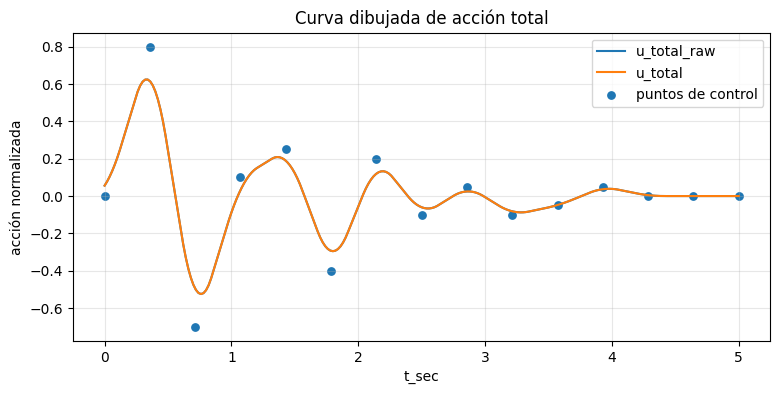

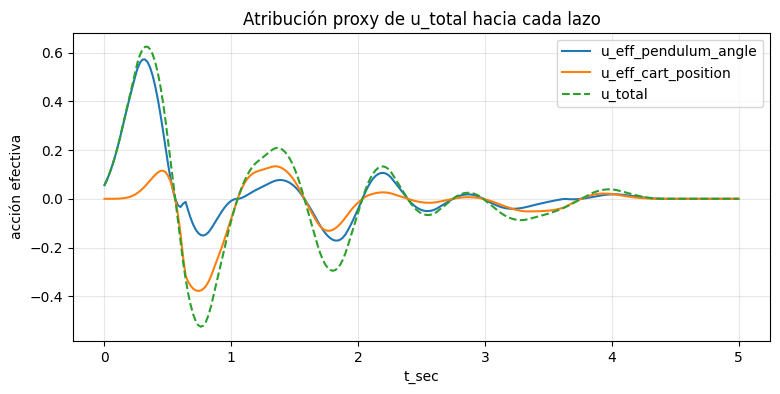

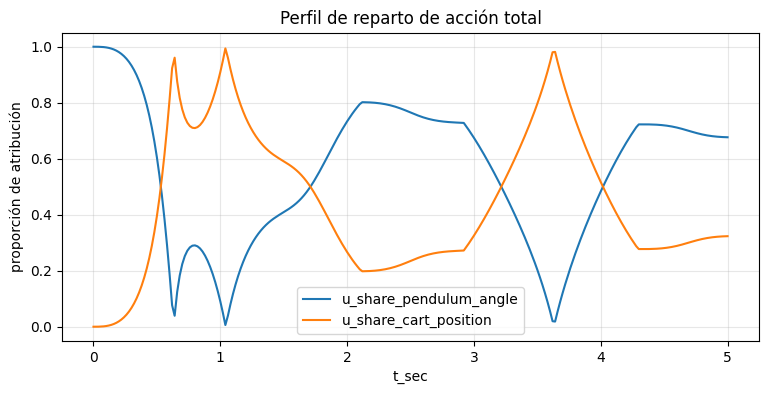

In [442]:
# ============================================================
# 2.6 Acción total y acciones efectivas proxy
# ============================================================

# Variables disponibles para control:
#   "u_total_raw"
#   "u_total_saturated"
#   "u_total"
#   "prev_u_total"
#   "delta_u_total"
#   "cart_force"
#   "u_share_pendulum_angle"
#   "u_share_cart_position"
#   "control_action_pendulum_angle"
#   "control_action_cart_position"
#   "u_eff_pendulum_angle"
#   "u_eff_cart_position"

plt.figure(figsize=(9, 4))
plt.plot(trajectory_df["t_sec"], trajectory_df["u_total_raw"], label="u_total_raw")
plt.plot(trajectory_df["t_sec"], trajectory_df["u_total"], label="u_total")
plt.scatter(u_total_knot_times, u_total_knot_values, s=28, label="puntos de control")
plt.xlabel("t_sec")
plt.ylabel("acción normalizada")
plt.title("Curva dibujada de acción total")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(9, 4))
plt.plot(trajectory_df["t_sec"], trajectory_df["u_eff_pendulum_angle"], label="u_eff_pendulum_angle")
plt.plot(trajectory_df["t_sec"], trajectory_df["u_eff_cart_position"], label="u_eff_cart_position")
plt.plot(trajectory_df["t_sec"], trajectory_df["u_total"], linestyle="--", label="u_total")
plt.xlabel("t_sec")
plt.ylabel("acción efectiva")
plt.title("Atribución proxy de u_total hacia cada lazo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(9, 4))
plt.plot(trajectory_df["t_sec"], trajectory_df["u_share_pendulum_angle"], label="u_share_pendulum_angle")
plt.plot(trajectory_df["t_sec"], trajectory_df["u_share_cart_position"], label="u_share_cart_position")
plt.xlabel("t_sec")
plt.ylabel("proporción de atribución")
plt.title("Perfil de reparto de acción total")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2.7 Gráficos físicos principales

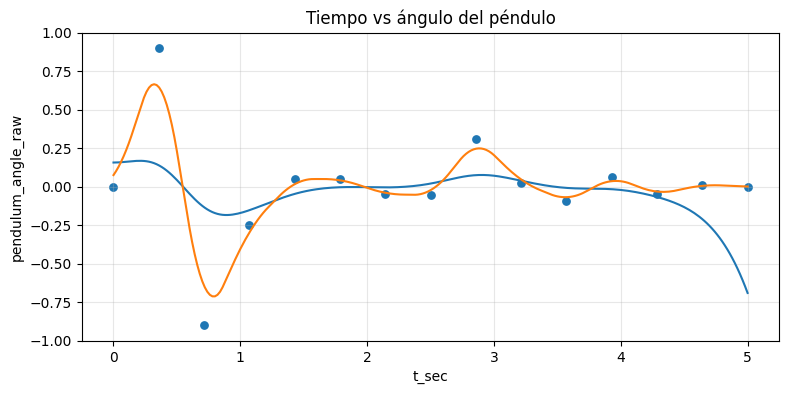

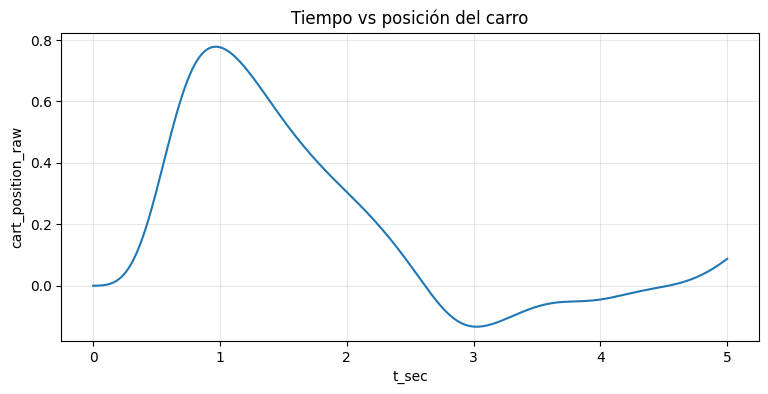

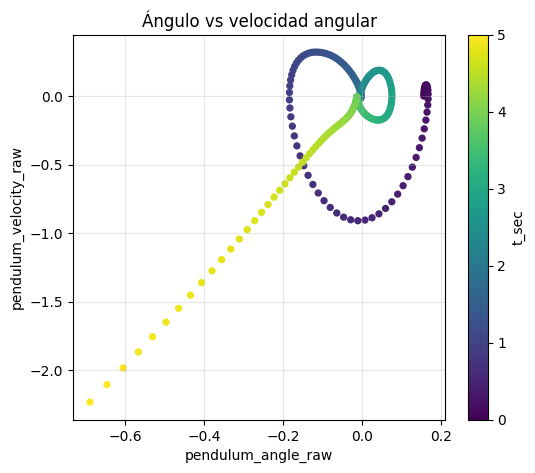

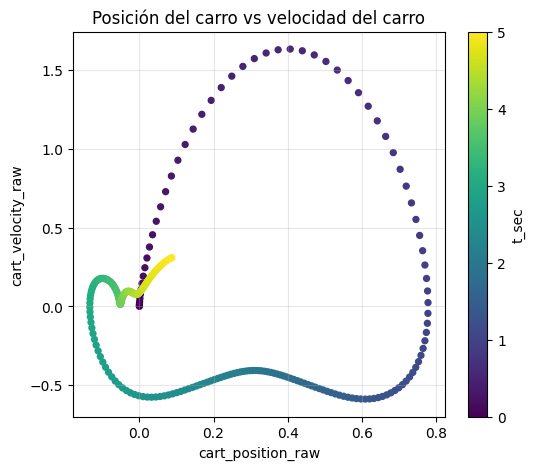

In [602]:
# ============================================================
# 2.7 Gráficos físicos principales
# ============================================================

# Variables físicas raw disponibles:
#   "cart_position_raw"
#   "cart_velocity_raw"
#   "pendulum_angle_raw"
#   "pendulum_velocity_raw"
#
# Variables normalizadas disponibles:
#   "cart_position_norm"
#   "cart_velocity_norm"
#   "pendulum_angle_norm"
#   "pendulum_velocity_norm"

plt.figure(figsize=(9, 4))
plt.plot(trajectory_df["t_sec"], trajectory_df["pendulum_angle_raw"])
plt.scatter(u_total_knot_times, u_total_knot_values, s=28, label="puntos de control")
plt.plot(trajectory_df["t_sec"], trajectory_df["u_total"], label="u_total")
plt.xlabel("t_sec")
plt.ylabel("pendulum_angle_raw")
plt.ylim(-1, 1)
plt.title("Tiempo vs ángulo del péndulo")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(9, 4))
plt.plot(trajectory_df["t_sec"], trajectory_df["cart_position_raw"])
plt.xlabel("t_sec")
plt.ylabel("cart_position_raw")
plt.title("Tiempo vs posición del carro")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    trajectory_df["pendulum_angle_raw"],
    trajectory_df["pendulum_velocity_raw"],
    c=trajectory_df["t_sec"],
    s=18,
)
plt.colorbar(scatter, label="t_sec")
plt.xlabel("pendulum_angle_raw")
plt.ylabel("pendulum_velocity_raw")
plt.title("Ángulo vs velocidad angular")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    trajectory_df["cart_position_raw"],
    trajectory_df["cart_velocity_raw"],
    c=trajectory_df["t_sec"],
    s=18,
)
plt.colorbar(scatter, label="t_sec")
plt.xlabel("cart_position_raw")
plt.ylabel("cart_velocity_raw")
plt.title("Posición del carro vs velocidad del carro")
plt.grid(True, alpha=0.3)
plt.show()

## 2.8 Gráfico genérico configurable

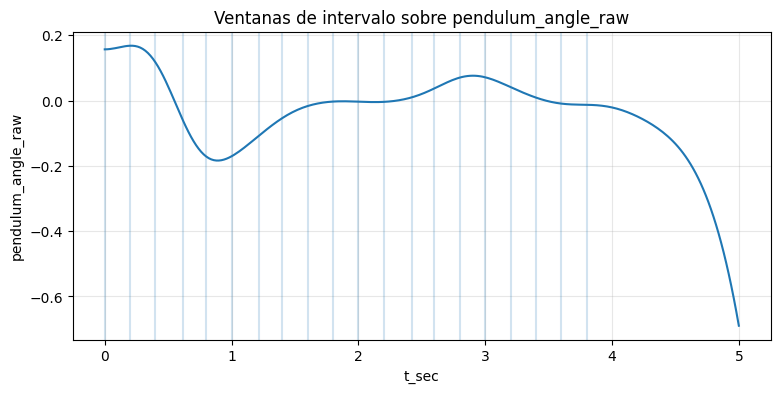

,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_t_end_sec,interval_n_steps
0,0,0,9,0.00,0.18,10
1,1,10,19,0.20,0.38,10
2,2,20,30,0.40,0.60,11
3,3,31,39,0.62,0.78,9
4,4,40,49,0.80,0.98,10
5,5,50,60,1.00,1.20,11
6,6,61,69,1.22,1.38,9
7,7,70,79,1.40,1.58,10
8,8,80,89,1.60,1.78,10
9,9,90,99,1.80,1.98,10


In [603]:
# ============================================================
# 2.8 Visualización de ventanas de intervalo
# ============================================================

# Variables disponibles para y_window_key:
#   "pendulum_angle_raw"
#   "pendulum_velocity_raw"
#   "cart_position_raw"
#   "cart_velocity_raw"
#   "pendulum_angle_norm"
#   "cart_position_norm"
#   "u_total"
#   "cart_force"
#   "error_pendulum_angle"
#   "error_cart_position"
#   "u_eff_pendulum_angle"
#   "u_eff_cart_position"

y_window_key = "pendulum_angle_raw"

# Número de ventanas a marcar visualmente.
#
# Opciones típicas:
#   5
#   10
#   20

n_window_lines_to_show = 20

plt.figure(figsize=(9, 4))
plt.plot(trajectory_df["t_sec"], trajectory_df[y_window_key])

for _, row in window_df.head(n_window_lines_to_show).iterrows():
    plt.axvline(row["interval_t_start_sec"], alpha=0.20)

plt.xlabel("t_sec")
plt.ylabel(y_window_key)
plt.title(f"Ventanas de intervalo sobre {y_window_key}")
plt.grid(True, alpha=0.3)
plt.show()


display(
    window_df[
        [
            "interval_id",
            "interval_start_step_idx",
            "interval_end_step_idx",
            "interval_t_start_sec",
            "interval_t_end_sec",
            "interval_n_steps",
        ]
    ].head(10)
)

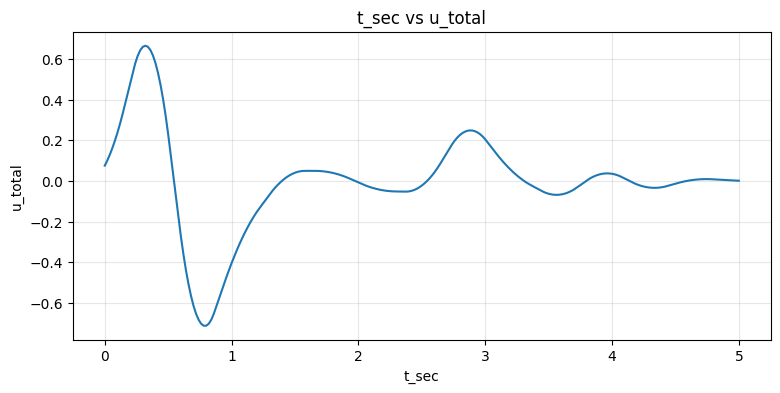

In [605]:
# ============================================================
# 2.9 Gráfico configurable simple
# ============================================================

# Opciones para plot_type:
#   "line"
#   "scatter"

plot_type = "line"

# Opciones típicas para x_key:
#   "t_sec"
#   "pendulum_angle_raw"
#   "pendulum_velocity_raw"
#   "cart_position_raw"
#   "cart_velocity_raw"
#   "pendulum_angle_norm"
#   "cart_position_norm"
#   "u_total"
#   "cart_force"
#   "error_pendulum_angle"
#   "error_cart_position"
#   "u_eff_pendulum_angle"
#   "u_eff_cart_position"

x_key = "t_sec"

# Opciones típicas para y_key:
#   "pendulum_angle_raw"
#   "pendulum_velocity_raw"
#   "cart_position_raw"
#   "cart_velocity_raw"
#   "pendulum_angle_norm"
#   "cart_position_norm"
#   "u_total"
#   "cart_force"
#   "error_pendulum_angle"
#   "error_cart_position"
#   "u_eff_pendulum_angle"
#   "u_eff_cart_position"

y_key = "u_total"

# Opciones para color_key si plot_type = "scatter":
#   None
#   "t_sec"
#   "u_total"
#   "cart_force"
#   "u_share_pendulum_angle"
#   "u_eff_pendulum_angle"
#   "u_eff_cart_position"
#   "interval_id"

color_key = "t_sec"

if plot_type == "line":
    plt.figure(figsize=(9, 4))
    plt.plot(trajectory_df[x_key], trajectory_df[y_key])
    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.title(f"{x_key} vs {y_key}")
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    plt.figure(figsize=(6, 5))

    if color_key is None:
        plt.scatter(trajectory_df[x_key], trajectory_df[y_key], s=18)
    else:
        scatter = plt.scatter(
            trajectory_df[x_key],
            trajectory_df[y_key],
            c=trajectory_df[color_key],
            s=18,
        )
        plt.colorbar(scatter, label=color_key)

    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.title(f"{x_key} vs {y_key}")
    plt.grid(True, alpha=0.3)
    plt.show()

## 2.10 Dashboard interactivo para ajustar la trayectoria activa

In [615]:
# ============================================================
# 2.10 Dashboard interactivo para dibujar u_total(t)
# ============================================================

last_interactive_trajectory_df = trajectory_df.copy()
last_interactive_window_df = window_df.copy()
last_interactive_window_step_records = dict(window_step_records)
last_interactive_u_total_knot_values = np.asarray(u_total_knot_values, dtype=float).copy()
last_interactive_u_share_pendulum_knot_values = np.asarray(u_share_pendulum_knot_values, dtype=float).copy()

n_u_knots = len(u_total_knot_times)

if widgets is None:
    print("ipywidgets no está disponible. Se conserva trajectory_df actual y se omite el dashboard interactivo.")
else:
    u_controls = {
        f"u{i}": widgets.FloatSlider(
            value=float(last_interactive_u_total_knot_values[i]),
            min=-1.5,
            max=1.5,
            step=0.01,
            description=f"u{i}",
            continuous_update=False,
            readout_format=".2f",
        )
        for i in range(n_u_knots)
    }

    share_controls = {
        f"alpha{i}": widgets.FloatSlider(
            value=float(last_interactive_u_share_pendulum_knot_values[i]),
            min=0.0,
            max=1.0,
            step=0.01,
            description=f"a{i}",
            continuous_update=False,
            readout_format=".2f",
        )
        for i in range(n_u_knots)
    }

    base_controls = {
        "initial_angle_deg": widgets.FloatSlider(
            value=float(np.rad2deg(initial_state["pendulum_angle"])),
            min=-25.0,
            max=25.0,
            step=1.0,
            description="angle_deg",
            continuous_update=False,
        ),
        "initial_cart_position": widgets.FloatSlider(
            value=float(initial_state["cart_position"]),
            min=-1.0,
            max=1.0,
            step=0.05,
            description="cart_x0",
            continuous_update=False,
        ),
        "smoothing_window": widgets.IntSlider(
            value=int(u_total_smoothing_window),
            min=1,
            max=31,
            step=1,
            description="smooth",
            continuous_update=False,
        ),
        "profile_mode": widgets.Dropdown(
            options=["manual_time_profile", "error_weighted", "hybrid"],
            value=u_eff_profile_mode,
            description="u_eff",
        ),
        "mix_error_weight": widgets.FloatSlider(
            value=float(error_weight_mix),
            min=0.0,
            max=1.0,
            step=0.01,
            description="mix_err",
            continuous_update=False,
            readout_format=".2f",
        ),
    }

    all_controls = {}
    all_controls.update(u_controls)
    all_controls.update(share_controls)
    all_controls.update(base_controls)

    def interactive_u_total_trajectory_preview(**kwargs):
        """
        Dashboard operativo:

        - u0...uN dibujan u_total(t).
        - alpha0...alphaN dibujan la proporción atribuida al lazo pendulum_angle.
        - La dinámica se simula directamente con u_total(t).
        """
        global last_interactive_trajectory_df
        global last_interactive_window_df
        global last_interactive_window_step_records
        global last_interactive_u_total_knot_values
        global last_interactive_u_share_pendulum_knot_values

        local_u_values = np.array(
            [kwargs[f"u{i}"] for i in range(n_u_knots)],
            dtype=float,
        )

        local_share_values = np.array(
            [kwargs[f"alpha{i}"] for i in range(n_u_knots)],
            dtype=float,
        )

        local_initial_state = {
            "cart_position": float(kwargs["initial_cart_position"]),
            "cart_velocity": 0.0,
            "pendulum_angle": np.deg2rad(float(kwargs["initial_angle_deg"])),
            "pendulum_velocity": 0.0,
        }

        local_trajectory_df, local_window_df, local_window_step_records = build_manual_control_trajectory(
            initial_state=local_initial_state,
            u_knot_values=local_u_values,
            share_knot_values=local_share_values,
            smoothing_window=int(kwargs["smoothing_window"]),
            profile_mode=kwargs["profile_mode"],
            error_weight_mix=float(kwargs["mix_error_weight"]),
        )

        last_interactive_trajectory_df = local_trajectory_df.copy()
        last_interactive_window_df = local_window_df.copy()
        last_interactive_window_step_records = dict(local_window_step_records)
        last_interactive_u_total_knot_values = local_u_values.copy()
        last_interactive_u_share_pendulum_knot_values = local_share_values.copy()

        plt.figure(figsize=(9, 4))
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_total_raw"], label="u_total_raw")
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_total"], label="u_total")
        plt.scatter(u_total_knot_times, local_u_values, s=28, label="puntos de control")
        plt.xlabel("t_sec")
        plt.ylabel("acción normalizada")
        plt.title("u_total(t) dibujado")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(9, 4))
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_eff_pendulum_angle"], label="u_eff_pendulum_angle")
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_eff_cart_position"], label="u_eff_cart_position")
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_share_pendulum_angle"], linestyle="--", label="u_share_pendulum_angle")
        plt.xlabel("t_sec")
        plt.ylabel("acción / proporción")
        plt.title("Atribución proxy de acción total")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(9, 4))
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["pendulum_angle_raw"], label="pendulum_angle_raw")
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["cart_position_raw"], label="cart_position_raw")
        plt.xlabel("t_sec")
        plt.ylabel("estado físico")
        plt.title("Respuesta física del sistema")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(6, 5))
        scatter = plt.scatter(
            local_trajectory_df["pendulum_angle_raw"],
            local_trajectory_df["pendulum_velocity_raw"],
            c=local_trajectory_df["t_sec"],
            s=18,
        )
        plt.colorbar(scatter, label="t_sec")
        plt.xlabel("pendulum_angle_raw")
        plt.ylabel("pendulum_velocity_raw")
        plt.title("Ángulo vs velocidad angular")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(6, 5))
        scatter = plt.scatter(
            local_trajectory_df["cart_position_raw"],
            local_trajectory_df["cart_velocity_raw"],
            c=local_trajectory_df["t_sec"],
            s=18,
        )
        plt.colorbar(scatter, label="t_sec")
        plt.xlabel("cart_position_raw")
        plt.ylabel("cart_velocity_raw")
        plt.title("Posición vs velocidad del carro")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(9, 4))
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["pendulum_angle_raw"])

        for _, row in local_window_df.head(20).iterrows():
            plt.axvline(row["interval_t_start_sec"], alpha=0.20)

        plt.xlabel("t_sec")
        plt.ylabel("pendulum_angle_raw")
        plt.title("Ventanas sobre trayectoria del péndulo")
        plt.grid(True, alpha=0.3)
        plt.show()

    u_grid = widgets.GridBox(
        children=list(u_controls.values()),
        layout=widgets.Layout(grid_template_columns="repeat(5, 170px)")
    )

    share_grid = widgets.GridBox(
        children=list(share_controls.values()),
        layout=widgets.Layout(grid_template_columns="repeat(5, 170px)")
    )

    base_box = widgets.VBox(list(base_controls.values()))

    ui = widgets.VBox(
        [
            widgets.HTML("<b>Curva de acción total u_total(t)</b>"),
            u_grid,
            widgets.HTML("<b>Perfil proxy de atribución al lazo pendulum_angle</b>"),
            share_grid,
            widgets.HTML("<b>Condición inicial y modo de atribución</b>"),
            base_box,
        ]
    )

    out = widgets.interactive_output(
        interactive_u_total_trajectory_preview,
        all_controls,
    )

    display(ui, out)

Output()

In [616]:
# ============================================================
# 2.10 Dashboard interactivo para dibujar u_total(t)
# ============================================================

last_interactive_trajectory_df = trajectory_df.copy()
last_interactive_window_df = window_df.copy()
last_interactive_window_step_records = dict(window_step_records)
last_interactive_u_total_knot_values = np.asarray(u_total_knot_values, dtype=float).copy()
last_interactive_u_share_pendulum_knot_values = np.asarray(u_share_pendulum_knot_values, dtype=float).copy()

n_u_knots = len(u_total_knot_times)

if widgets is None:
    print("ipywidgets no está disponible. Se conserva trajectory_df actual y se omite el dashboard interactivo.")
else:
    u_controls = {
        f"u{i}": widgets.FloatSlider(
            value=float(last_interactive_u_total_knot_values[i]),
            min=-1.5,
            max=1.5,
            step=0.01,
            description=f"u{i}",
            continuous_update=False,
            readout_format=".2f",
        )
        for i in range(n_u_knots)
    }

    share_controls = {
        f"alpha{i}": widgets.FloatSlider(
            value=float(last_interactive_u_share_pendulum_knot_values[i]),
            min=0.0,
            max=1.0,
            step=0.01,
            description=f"a{i}",
            continuous_update=False,
            readout_format=".2f",
        )
        for i in range(n_u_knots)
    }

    base_controls = {
        "initial_angle_deg": widgets.FloatSlider(
            value=float(np.rad2deg(initial_state["pendulum_angle"])),
            min=-25.0,
            max=25.0,
            step=1.0,
            description="angle_deg",
            continuous_update=False,
        ),
        "initial_cart_position": widgets.FloatSlider(
            value=float(initial_state["cart_position"]),
            min=-1.0,
            max=1.0,
            step=0.05,
            description="cart_x0",
            continuous_update=False,
        ),
        "smoothing_window": widgets.IntSlider(
            value=int(u_total_smoothing_window),
            min=1,
            max=31,
            step=1,
            description="smooth",
            continuous_update=False,
        ),
        "profile_mode": widgets.Dropdown(
            options=["manual_time_profile", "error_weighted", "hybrid"],
            value=u_eff_profile_mode,
            description="u_eff",
        ),
        "mix_error_weight": widgets.FloatSlider(
            value=float(error_weight_mix),
            min=0.0,
            max=1.0,
            step=0.01,
            description="mix_err",
            continuous_update=False,
            readout_format=".2f",
        ),
    }

    all_controls = {}
    all_controls.update(u_controls)
    all_controls.update(share_controls)
    all_controls.update(base_controls)

    def interactive_u_total_trajectory_preview(**kwargs):
        """
        Dashboard operativo:

        - u0...uN dibujan u_total(t).
        - alpha0...alphaN dibujan la proporción atribuida al lazo pendulum_angle.
        - La dinámica se simula directamente con u_total(t).
        """
        global last_interactive_trajectory_df
        global last_interactive_window_df
        global last_interactive_window_step_records
        global last_interactive_u_total_knot_values
        global last_interactive_u_share_pendulum_knot_values

        local_u_values = np.array(
            [kwargs[f"u{i}"] for i in range(n_u_knots)],
            dtype=float,
        )

        local_share_values = np.array(
            [kwargs[f"alpha{i}"] for i in range(n_u_knots)],
            dtype=float,
        )

        local_initial_state = {
            "cart_position": float(kwargs["initial_cart_position"]),
            "cart_velocity": 0.0,
            "pendulum_angle": np.deg2rad(float(kwargs["initial_angle_deg"])),
            "pendulum_velocity": 0.0,
        }

        local_trajectory_df, local_window_df, local_window_step_records = build_manual_control_trajectory(
            initial_state=local_initial_state,
            u_knot_values=local_u_values,
            share_knot_values=local_share_values,
            smoothing_window=int(kwargs["smoothing_window"]),
            profile_mode=kwargs["profile_mode"],
            error_weight_mix=float(kwargs["mix_error_weight"]),
        )

        last_interactive_trajectory_df = local_trajectory_df.copy()
        last_interactive_window_df = local_window_df.copy()
        last_interactive_window_step_records = dict(local_window_step_records)
        last_interactive_u_total_knot_values = local_u_values.copy()
        last_interactive_u_share_pendulum_knot_values = local_share_values.copy()

        plt.figure(figsize=(9, 4))
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_total_raw"], label="u_total_raw")
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_total"], label="u_total")
        plt.scatter(u_total_knot_times, local_u_values, s=28, label="puntos de control")
        plt.xlabel("t_sec")
        plt.ylabel("acción normalizada")
        plt.title("u_total(t) dibujado")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(9, 4))
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_eff_pendulum_angle"], label="u_eff_pendulum_angle")
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_eff_cart_position"], label="u_eff_cart_position")
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["u_share_pendulum_angle"], linestyle="--", label="u_share_pendulum_angle")
        plt.xlabel("t_sec")
        plt.ylabel("acción / proporción")
        plt.title("Atribución proxy de acción total")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(9, 4))
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["pendulum_angle_raw"], label="pendulum_angle_raw")
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["cart_position_raw"], label="cart_position_raw")
        plt.xlabel("t_sec")
        plt.ylabel("estado físico")
        plt.title("Respuesta física del sistema")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(6, 5))
        scatter = plt.scatter(
            local_trajectory_df["pendulum_angle_raw"],
            local_trajectory_df["pendulum_velocity_raw"],
            c=local_trajectory_df["t_sec"],
            s=18,
        )
        plt.colorbar(scatter, label="t_sec")
        plt.xlabel("pendulum_angle_raw")
        plt.ylabel("pendulum_velocity_raw")
        plt.title("Ángulo vs velocidad angular")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(6, 5))
        scatter = plt.scatter(
            local_trajectory_df["cart_position_raw"],
            local_trajectory_df["cart_velocity_raw"],
            c=local_trajectory_df["t_sec"],
            s=18,
        )
        plt.colorbar(scatter, label="t_sec")
        plt.xlabel("cart_position_raw")
        plt.ylabel("cart_velocity_raw")
        plt.title("Posición vs velocidad del carro")
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(9, 4))
        plt.plot(local_trajectory_df["t_sec"], local_trajectory_df["pendulum_angle_raw"])

        for _, row in local_window_df.head(20).iterrows():
            plt.axvline(row["interval_t_start_sec"], alpha=0.20)

        plt.xlabel("t_sec")
        plt.ylabel("pendulum_angle_raw")
        plt.title("Ventanas sobre trayectoria del péndulo")
        plt.grid(True, alpha=0.3)
        plt.show()

    u_grid = widgets.GridBox(
        children=list(u_controls.values()),
        layout=widgets.Layout(grid_template_columns="repeat(5, 170px)")
    )

    share_grid = widgets.GridBox(
        children=list(share_controls.values()),
        layout=widgets.Layout(grid_template_columns="repeat(5, 170px)")
    )

    base_box = widgets.VBox(list(base_controls.values()))

    ui = widgets.VBox(
        [
            widgets.HTML("<b>Curva de acción total u_total(t)</b>"),
            u_grid,
            widgets.HTML("<b>Perfil proxy de atribución al lazo pendulum_angle</b>"),
            share_grid,
            widgets.HTML("<b>Condición inicial y modo de atribución</b>"),
            base_box,
        ]
    )

    out = widgets.interactive_output(
        interactive_u_total_trajectory_preview,
        all_controls,
    )

    display(ui, out)

Output()

## 2.11 Registrar la trayectoria interactiva como referencia activa

In [609]:
# ============================================================
# 2.11 Registrar trayectoria interactiva como activa
# ============================================================

trajectory_df = last_interactive_trajectory_df.copy()
window_df = last_interactive_window_df.copy()
window_step_records = dict(last_interactive_window_step_records)

trajectory_registry = {
    active_trajectory_name: trajectory_df.copy(),
}

display(
    trajectory_df[
        [
            "step_idx",
            "interval_id",
            "t_sec",
            "pendulum_angle_raw",
            "pendulum_velocity_raw",
            "cart_position_raw",
            "cart_velocity_raw",
            "u_total",
            "u_eff_pendulum_angle",
            "u_eff_cart_position",
        ]
    ].head(10)
)

display(window_df.head(10))

,step_idx,interval_id,t_sec,pendulum_angle_raw,pendulum_velocity_raw,cart_position_raw,cart_velocity_raw,u_total,u_eff_pendulum_angle,u_eff_cart_position
0,0,0,0.00,0.157080,0.000000,0.000000,0.000000,0.0756,0.075600,5.040000e-13
1,1,0,0.02,0.157327,0.024782,0.000060,0.006001,0.1008,0.100792,8.053649e-06
2,2,0,0.04,0.158032,0.045712,0.000280,0.015996,0.1296,0.129552,4.808065e-05
3,3,0,0.06,0.159112,0.062323,0.000746,0.030544,0.1620,0.161841,1.588166e-04
4,4,0,0.08,0.160476,0.074128,0.001553,0.050204,0.1980,0.197599,4.005223e-04
5,5,0,0.10,0.162023,0.080619,0.002811,0.075539,0.2376,0.236740,8.601114e-04
6,6,0,0.12,0.163641,0.081266,0.004637,0.107117,0.2808,0.279143,1.656750e-03
7,7,0,0.14,0.165208,0.075511,0.007164,0.145506,0.3276,0.324652,2.948337e-03
8,8,0,0.16,0.166590,0.062767,0.010532,0.191284,0.3780,0.373060,4.939501e-03
9,9,0,0.18,0.167642,0.042411,0.014895,0.245031,0.4284,0.420574,7.826266e-03


,interval_id,interval_start_step_idx,interval_end_step_idx,interval_t_start_sec,interval_t_end_sec,interval_t_mid_sec,interval_n_steps
0,0,0,9,0.00,0.18,0.09,10
1,1,10,19,0.20,0.38,0.29,10
2,2,20,30,0.40,0.60,0.50,11
3,3,31,39,0.62,0.78,0.70,9
4,4,40,49,0.80,0.98,0.89,10
5,5,50,60,1.00,1.20,1.10,11
6,6,61,69,1.22,1.38,1.30,9
7,7,70,79,1.40,1.58,1.49,10
8,8,80,89,1.60,1.78,1.69,10
9,9,90,99,1.80,1.98,1.89,10


## 2.12 Persistencia mínima de la sección

In [617]:
# ============================================================
# 2.12 Persistencia mínima de esta sección
# ============================================================

reward_design["trajectory_design"] = {
    "active_trajectory_name": active_trajectory_name,
    "trajectory_registry": {
        active_trajectory_name: trajectory_df.copy(),
    },
    "trajectory_df": trajectory_df.copy(),
    "window_df": window_df.copy(),
    "window_step_records": dict(window_step_records),
    "u_total_knot_times": np.asarray(u_total_knot_times, dtype=float),
    "u_total_knot_values": np.asarray(last_interactive_u_total_knot_values, dtype=float),
    "u_total_smoothing_window": int(u_total_smoothing_window),
    "u_eff_profile_mode": u_eff_profile_mode,
    "u_share_pendulum_knot_values": np.asarray(last_interactive_u_share_pendulum_knot_values, dtype=float),
    "error_weight_mix": error_weight_mix,
}

print("Trayectoria step-level registrada en reward_design['trajectory_design']['trajectory_df'].")
print("Ventanas registradas en reward_design['trajectory_design']['window_df'].")
print("Registros planos por ventana registrados en reward_design['trajectory_design']['window_step_records'].")

Trayectoria step-level registrada en reward_design['trajectory_design']['trajectory_df'].
Ventanas registradas en reward_design['trajectory_design']['window_df'].
Registros planos por ventana registrados en reward_design['trajectory_design']['window_step_records'].


# 3. Agregación y normalización de componentes L_*_<var_obj>

Esta sección traduce las trayectorias físicas de referencia en componentes normalizados de recompensa.

Se construyen únicamente:

- `L_e_<var_obj>`
- `L_edot_<var_obj>`
- `L_I_<var_obj>`
- `L_u_<var_obj>`

No se construye `L_delta_u_<var_obj>`.

La lógica sigue el mismo relato del proyecto:

1. tomar registros planos por step;
2. dividir la trayectoria en intervalos de decisión;
3. agregar señales continuas dentro de cada intervalo;
4. normalizar cada magnitud agregada;
5. obtener un `interval_feature_df` plano con columnas listas para analizar recompensa.

En esta sección los rangos de normalización se derivan desde las trayectorias construidas en la sección 2.
No se introducen bandas físicas manuales.

## 3.1 Inputs locales de agregación y normalización

In [631]:
# ============================================================
# 3.1 Inputs configurables de esta sección
# ============================================================

system_context = reward_design["system_context"]
trajectory_design = reward_design["trajectory_design"]

var_objs = system_context["var_objs"]
decision_interval_sec = system_context["decision_interval_sec"]

active_trajectory_name = trajectory_design["active_trajectory_name"]
trajectory_df = trajectory_design["trajectory_df"].copy()
window_df = trajectory_design["window_df"].copy()
window_step_records = dict(trajectory_design["window_step_records"])

# En este flujo existe una trayectoria activa construida desde u_total(t).
# Por lo tanto, la normalización de recompensa se diseña desde esa trayectoria.

active_normalization_preset = "active"

# Features disponibles:
#   "e"     -> error_<var_obj>
#   "edot"  -> derivative_error_<var_obj>
#   "I"     -> integral_error_<var_obj>
#   "u"     -> u_eff_<var_obj>
#
# No usar:
#   "delta_u"

# Métodos disponibles:
#   "mean"
#   "mean_squared"
#   "rms"
#   "abs"
#   "accum"
#   "proportion"
#   "keep_last"

aggregation_methods = {
    "pendulum_angle": {
        "e": "rms",
        "edot": "rms",
        "I": "rms",
        "u": "rms",
    },
    "cart_position": {
        "e": "rms",
        "edot": "rms",
        "I": "rms",
        "u": "rms",
    },
}

# Fuente para rangos de normalización.
#
# Opciones:
#   "manual"       -> usa manual_normalization_ranges
#   "quantile_abs" -> deriva rango desde cuantiles de la señal
#   "max_abs"      -> deriva rango desde máximo absoluto observado
#   "std_abs"      -> deriva rango desde desviación estándar

range_source_by_feature = {
    "e": "manual",
    "edot": "manual",
    "I": "manual",
    "u": "manual",
}

range_quantile_by_feature = {
    "e": 0.98,
    "edot": 0.98,
    "I": 0.98,
    "u": 0.98,
}

std_factor_by_feature = {
    "e": 3.0,
    "edot": 3.0,
    "I": 3.0,
    "u": 3.0,
}

normalization_safety_factor = {
    "pendulum_angle": {
        "e": 1.0,
        "edot": 1.0,
        "I": 1.0,
        "u": 1.0,
    },
    "cart_position": {
        "e": 1.0,
        "edot": 1.0,
        "I": 1.0,
        "u": 1.0,
    },
}

# Rangos manuales para señales step-level ya normalizadas o derivadas desde ellas.
#
# Variables disponibles:
#   "pendulum_angle"
#   "cart_position"
#
# Features disponibles:
#   "e"
#   "edot"
#   "I"
#   "u"

manual_normalization_ranges = {
    "pendulum_angle": {
        "e": (-0.35, 0.35),
        "edot": (-1.20, 1.20),
        "I": (-2.00, 2.00),
        "u": (-1.00, 1.00),
    },
    "cart_position": {
        "e": (-1.00, 1.00),
        "edot": (-1.70, 1.70),
        "I": (-2.00, 2.00),
        "u": (-1.00, 1.00),
    },
}

reward_component_output_limits = (0.0, 1.0)

## 3.2 Helpers locales para rangos derivados desde trayectoria

In [632]:
# ============================================================
# 3.2 Helpers locales para construir rangos y configuración
# ============================================================

def build_reference_df_from_windows(
    trajectory_df: pd.DataFrame,
    window_step_records: Dict[int, List[Dict[str, float]]],
) -> pd.DataFrame:
    """
    Construye una trayectoria de referencia desde los registros planos por ventana.

    En este notebook la trayectoria ya existe como DataFrame, pero usar
    window_step_records mantiene la misma idea operacional del sistema:
    métricas calculadas desde flat_step_records.
    """
    frames = [
        pd.DataFrame(step_records)
        for _, step_records in sorted(window_step_records.items())
    ]

    if frames:
        return pd.concat(frames, ignore_index=True)

    return trajectory_df.copy()


def estimate_symmetric_range_from_signal(
    values: Sequence[float],
    source: str,
    quantile: float,
    std_factor: float,
    safety_factor: float,
    manual_range: Tuple[float, float],
) -> Tuple[float, float]:
    """
    Estima un rango simétrico [-limit, limit] para una señal step-level.
    """
    arr = finite_array(values)
    abs_arr = np.abs(arr)

    if source == "manual":
        range_min, range_max = manual_range
        limit = max(abs(range_min), abs(range_max))

    elif source == "max_abs":
        limit = np.max(abs_arr) if len(abs_arr) else 1.0

    elif source == "std_abs":
        limit = std_factor * np.std(arr) if len(arr) else 1.0

    else:
        limit = np.quantile(abs_arr, quantile) if len(abs_arr) else 1.0

    limit = max(float(limit) * float(safety_factor), 1e-9)
    return (-limit, limit)


def build_aggregation_config_from_reference_df(
    reference_df: pd.DataFrame,
    var_objs: Sequence[str],
    aggregation_methods: Dict[str, Dict[str, str]],
    range_source_by_feature: Dict[str, str],
    range_quantile_by_feature: Dict[str, float],
    std_factor_by_feature: Dict[str, float],
    normalization_safety_factor: Dict[str, Dict[str, float]],
    manual_normalization_ranges: Dict[str, Dict[str, Tuple[float, float]]],
) -> Dict[str, Dict[str, Dict[str, object]]]:
    """
    Construye la configuración explícita:

        aggregation_config[var_obj][feature] = {
            "method": ...,
            "range": ...
        }
    """
    signal_key_by_feature = {
        "e": "error_{var_obj}",
        "edot": "derivative_error_{var_obj}",
        "I": "integral_error_{var_obj}",
        "u": "u_eff_{var_obj}",
    }

    aggregation_config = {}

    for var_obj in var_objs:
        aggregation_config[var_obj] = {}

        for feature_key, signal_template in signal_key_by_feature.items():
            signal_key = signal_template.format(var_obj=var_obj)

            value_range = estimate_symmetric_range_from_signal(
                values=reference_df[signal_key],
                source=range_source_by_feature[feature_key],
                quantile=range_quantile_by_feature[feature_key],
                std_factor=std_factor_by_feature[feature_key],
                safety_factor=normalization_safety_factor[var_obj][feature_key],
                manual_range=manual_normalization_ranges[var_obj][feature_key],
            )

            aggregation_config[var_obj][feature_key] = {
                "method": aggregation_methods[var_obj][feature_key],
                "range": value_range,
            }

    return aggregation_config

## 3.3. Construir Agg L_*

In [633]:
# ============================================================
# 3.3 Construir aggregation_config
# ============================================================

reference_df = build_reference_df_from_windows(
    trajectory_df=trajectory_df,
    window_step_records=window_step_records,
)

aggregation_config = build_aggregation_config_from_reference_df(
    reference_df=reference_df,
    var_objs=var_objs,
    aggregation_methods=aggregation_methods,
    range_source_by_feature=range_source_by_feature,
    range_quantile_by_feature=range_quantile_by_feature,
    std_factor_by_feature=std_factor_by_feature,
    normalization_safety_factor=normalization_safety_factor,
    manual_normalization_ranges=manual_normalization_ranges,
)

normalization_presets = {
    active_normalization_preset: aggregation_config,
}

normalization_rows = []

for preset_name, preset_config in normalization_presets.items():
    for var_obj in var_objs:
        for feature_key, cfg in preset_config[var_obj].items():
            normalization_rows.append(
                {
                    "preset": preset_name,
                    "var_obj": var_obj,
                    "feature": feature_key,
                    "method": cfg["method"],
                    "range_min": cfg["range"][0],
                    "range_max": cfg["range"][1],
                }
            )

normalization_config_df = pd.DataFrame(normalization_rows)

display(normalization_config_df)

,preset,var_obj,feature,method,range_min,range_max
0,active,pendulum_angle,e,rms,-0.35,0.35
1,active,pendulum_angle,edot,rms,-1.20,1.20
2,active,pendulum_angle,I,rms,-2.00,2.00
3,active,pendulum_angle,u,rms,-1.00,1.00
4,active,cart_position,e,rms,-1.00,1.00
5,active,cart_position,edot,rms,-1.70,1.70
6,active,cart_position,I,rms,-2.00,2.00
7,active,cart_position,u,rms,-1.00,1.00


## 3.4 Helpers locales para dividir intervalos y calcular L_*

In [634]:
# ============================================================
# 3.4 Helpers locales para calcular L_* desde ventanas
# ============================================================

def add_interval_id(
    trace_df: pd.DataFrame,
    decision_interval_sec: float,
) -> pd.DataFrame:
    """
    Agrega interval_id por conteo de steps cuando no viene desde sección 2.
    """
    df = trace_df.copy()

    if "interval_id" in df.columns:
        return df

    local_dt_sec = float(np.median(np.diff(df["t_sec"].to_numpy(dtype=float))))
    local_steps_per_interval = int(round(decision_interval_sec / local_dt_sec))

    df["interval_id"] = (
        np.arange(len(df)) // local_steps_per_interval
    ).astype(int)

    return df


def compute_interval_feature_table(
    trace_df: pd.DataFrame,
    var_objs: Sequence[str],
    aggregation_config: Dict[str, Dict[str, Dict[str, object]]],
    output_limits: Tuple[float, float],
    decision_interval_sec: float,
    window_df: Optional[pd.DataFrame] = None,
    window_step_records: Optional[Dict[int, List[Dict[str, float]]]] = None,
) -> pd.DataFrame:
    """
    Calcula los componentes interval-level:

        L_e_<var_obj>
        L_edot_<var_obj>
        L_I_<var_obj>
        L_u_<var_obj>

    Usa window_step_records cuando están disponibles.
    """
    signal_key_by_feature = {
        "e": "error_{var_obj}",
        "edot": "derivative_error_{var_obj}",
        "I": "integral_error_{var_obj}",
        "u": "u_eff_{var_obj}",
    }

    L_key_by_feature = {
        "e": "L_e_{var_obj}",
        "edot": "L_edot_{var_obj}",
        "I": "L_I_{var_obj}",
        "u": "L_u_{var_obj}",
    }

    if window_step_records is not None:
        interval_iter = [
            (int(interval_id), pd.DataFrame(step_records))
            for interval_id, step_records in sorted(window_step_records.items())
        ]
    else:
        df = add_interval_id(
            trace_df=trace_df,
            decision_interval_sec=decision_interval_sec,
        )

        interval_iter = [
            (int(interval_id), interval_df.copy())
            for interval_id, interval_df in df.groupby("interval_id", sort=True)
        ]

    window_meta = {}

    if window_df is not None:
        window_meta = window_df.set_index("interval_id").to_dict("index")

    interval_records = []

    for interval_id, interval_df in interval_iter:
        meta = window_meta.get(interval_id, {})

        record = {
            "interval_id": int(interval_id),
            "interval_t_start_sec": float(
                meta.get("interval_t_start_sec", interval_df["t_sec"].iloc[0])
            ),
            "interval_t_end_sec": float(
                meta.get("interval_t_end_sec", interval_df["t_sec"].iloc[-1])
            ),
            "interval_t_mid_sec": float(
                meta.get(
                    "interval_t_mid_sec",
                    0.5 * (
                        interval_df["t_sec"].iloc[0]
                        + interval_df["t_sec"].iloc[-1]
                    ),
                )
            ),
            "interval_n_steps": int(
                meta.get("interval_n_steps", len(interval_df))
            ),
        }

        for var_obj in var_objs:
            for feature_key, signal_template in signal_key_by_feature.items():
                signal_key = signal_template.format(var_obj=var_obj)
                cfg = aggregation_config[var_obj][feature_key]

                method = cfg["method"]
                value_range = cfg["range"]

                aggregated_value = aggregate_series(
                    values=interval_df[signal_key],
                    method=method,
                )

                normalized_value = normalize_metric(
                    value=aggregated_value,
                    value_range=value_range,
                    output_limits=output_limits,
                    method=method,
                )

                aggregate_key = f"{signal_key}_{method}"
                L_key = L_key_by_feature[feature_key].format(var_obj=var_obj)

                record[aggregate_key] = aggregated_value
                record[L_key] = normalized_value

        interval_records.append(record)

    return pd.DataFrame(interval_records)

## 3.5 Calcular tabla de features por intervalo

In [635]:
# ============================================================
# 3.5 Calcular interval_feature_df
# ============================================================

interval_feature_df = compute_interval_feature_table(
    trace_df=trajectory_df,
    var_objs=var_objs,
    aggregation_config=aggregation_config,
    output_limits=reward_component_output_limits,
    decision_interval_sec=decision_interval_sec,
    window_df=window_df,
    window_step_records=window_step_records,
)

reward_feature_keys = build_feature_keys(var_objs)

selected_interval_id = int(interval_feature_df["interval_id"].iloc[0])
selected_interval_row = interval_feature_df[
    interval_feature_df["interval_id"] == selected_interval_id
].iloc[0]

reward_component_preview = {
    feature_key: float(selected_interval_row[feature_key])
    for feature_key in reward_feature_keys
}

display(
    interval_feature_df[
        [
            "interval_id",
            "interval_t_start_sec",
            "interval_t_end_sec",
            "interval_n_steps",
            *reward_feature_keys,
        ]
    ].head(10)
)

,interval_id,interval_t_start_sec,interval_t_end_sec,interval_n_steps,L_e_pendulum_angle,L_edot_pendulum_angle,L_I_pendulum_angle,L_u_pendulum_angle,L_e_cart_position,L_edot_cart_position,L_I_cart_position,L_u_cart_position
0,0,0.00,0.18,10,0.441328,0.047158,0.008203,0.255601,0.001291,0.014015,0.000035,0.003131
1,1,0.20,0.38,10,0.425758,0.227134,0.022853,0.554694,0.016406,0.087511,0.000784,0.066310
2,2,0.40,0.60,11,0.180208,0.647357,0.032694,0.222880,0.065721,0.177453,0.005118,0.135485
3,3,0.62,0.78,9,0.339458,0.516213,0.028267,0.292853,0.122906,0.148728,0.014564,0.301817
4,4,0.80,0.98,10,0.489445,0.123973,0.014198,0.317832,0.151939,0.049377,0.028019,0.280119
5,5,1.00,1.20,11,0.393688,0.230324,0.005314,0.136633,0.149804,0.041538,0.043987,0.142620
6,6,1.22,1.38,9,0.227054,0.235758,0.013881,0.031939,0.131117,0.066332,0.057882,0.047823
7,7,1.40,1.58,10,0.099493,0.155429,0.018638,0.007368,0.109292,0.066386,0.069129,0.029638
8,8,1.60,1.78,10,0.026742,0.062480,0.020388,0.004463,0.088248,0.057073,0.078826,0.043908
9,9,1.80,1.98,10,0.006603,0.010151,0.020777,0.000751,0.070280,0.049493,0.086607,0.024163


## 3.6 Curvas de transferencia hacia normalización

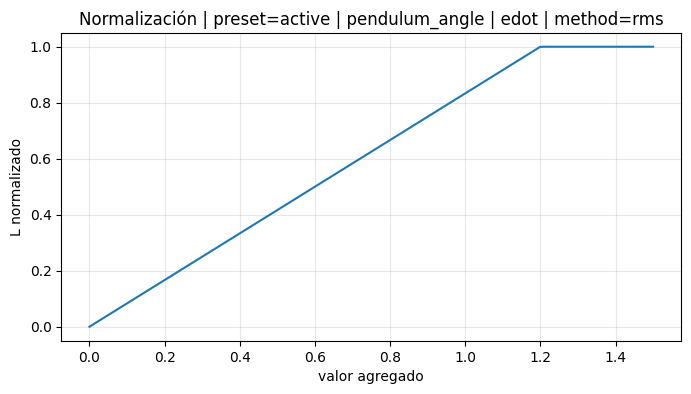

In [637]:
# ============================================================
# 3.6 Curvas de transferencia: valor agregado -> L normalizado
# ============================================================

def build_normalization_curve(
    method: str,
    value_range: Tuple[float, float],
    output_limits: Tuple[float, float],
    n_points: int = 250,
) -> pd.DataFrame:
    """
    Construye una curva de normalización para visualizar sensibilidad.
    """
    range_min, range_max = value_range
    max_abs = max(abs(range_min), abs(range_max))

    if method == "mean_squared":
        x_values = np.linspace(0.0, 1.25 * max_abs ** 2, n_points)

    elif method in ("rms", "abs"):
        x_values = np.linspace(0.0, 1.25 * max_abs, n_points)

    elif method == "proportion":
        x_values = np.linspace(0.0, 1.0, n_points)

    else:
        x_values = np.linspace(range_min, range_max, n_points)

    y_values = [
        normalize_metric(
            value=value,
            value_range=value_range,
            output_limits=output_limits,
            method=method,
        )
        for value in x_values
    ]

    return pd.DataFrame(
        {
            "aggregated_value": x_values,
            "L_normalized": y_values,
        }
    )


# Opciones para selected_var_obj:
#   "pendulum_angle"
#   "cart_position"

selected_var_obj = "pendulum_angle"

# Opciones para selected_feature:
#   "e"
#   "edot"
#   "I"
#   "u"

selected_feature = "edot"

selected_cfg = aggregation_config[selected_var_obj][selected_feature]

normalization_curve_df = build_normalization_curve(
    method=selected_cfg["method"],
    value_range=selected_cfg["range"],
    output_limits=reward_component_output_limits,
)

plt.figure(figsize=(8, 4))
plt.plot(
    normalization_curve_df["aggregated_value"],
    normalization_curve_df["L_normalized"],
)
plt.xlabel("valor agregado")
plt.ylabel("L normalizado")
plt.title(
    f"Normalización | preset={active_normalization_preset} | "
    f"{selected_var_obj} | {selected_feature} | method={selected_cfg['method']}"
)
plt.grid(True, alpha=0.3)
plt.show()

## 3.7 Evolución temporal de features normalizadas

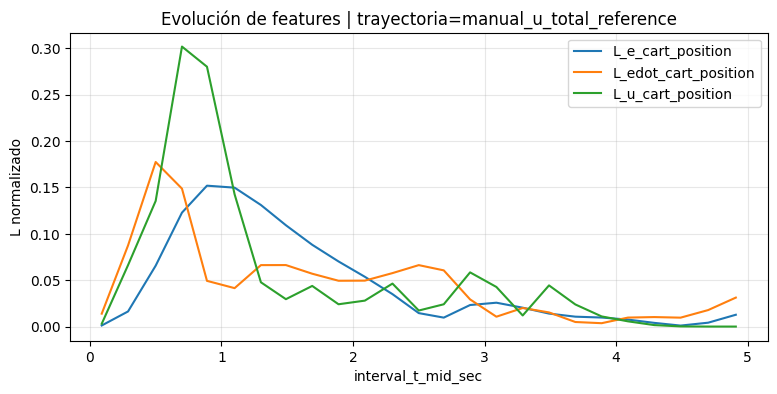

In [643]:
# ============================================================
# 3.7 Evolución temporal de features L_*_<var_obj>
# ============================================================

# Opciones para selected_feature_keys:
#   "L_e_pendulum_angle"
#   "L_edot_pendulum_angle"
#   "L_I_pendulum_angle"
#   "L_u_pendulum_angle"
#   "L_e_cart_position"
#   "L_edot_cart_position"
#   "L_I_cart_position"
#   "L_u_cart_position"

selected_feature_keys = [
    "L_e_pendulum_angle",
    "L_edot_pendulum_angle",
    "L_u_pendulum_angle",
]

selected_feature_keys2 = [
    "L_e_cart_position",
    "L_edot_cart_position",
    "L_u_cart_position",
]

plt.figure(figsize=(9, 4))

for feature_key in selected_feature_keys2:
    plt.plot(
        interval_feature_df["interval_t_mid_sec"],
        interval_feature_df[feature_key],
        label=feature_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("L normalizado")
plt.title(f"Evolución de features | trayectoria={active_trajectory_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3.8 Scatter entre features normalizadas

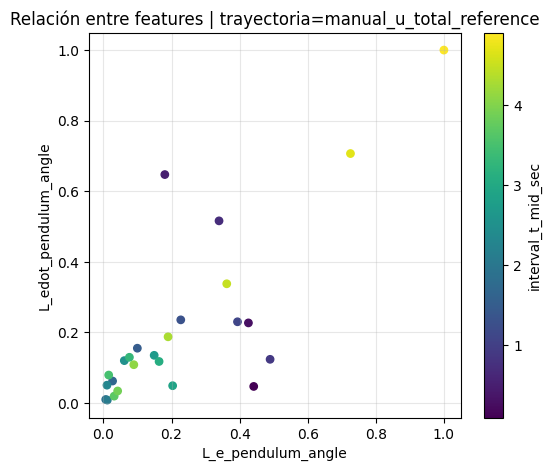

In [641]:
# ============================================================
# 3.8 Scatter entre features normalizadas
# ============================================================

# Opciones para x_feature_key:
#   "L_e_pendulum_angle"
#   "L_edot_pendulum_angle"
#   "L_I_pendulum_angle"
#   "L_u_pendulum_angle"
#   "L_e_cart_position"
#   "L_edot_cart_position"
#   "L_I_cart_position"
#   "L_u_cart_position"

x_feature_key = "L_e_pendulum_angle"

# Opciones para y_feature_key:
#   "L_e_pendulum_angle"
#   "L_edot_pendulum_angle"
#   "L_I_pendulum_angle"
#   "L_u_pendulum_angle"
#   "L_e_cart_position"
#   "L_edot_cart_position"
#   "L_I_cart_position"
#   "L_u_cart_position"

y_feature_key = "L_edot_pendulum_angle"

# Opciones para color_key:
#   "interval_t_mid_sec"
#   "interval_id"
#   cualquiera de las features L_* disponibles

color_key = "interval_t_mid_sec"

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    interval_feature_df[x_feature_key],
    interval_feature_df[y_feature_key],
    c=interval_feature_df[color_key],
    s=28,
)

plt.colorbar(scatter, label=color_key)
plt.xlabel(x_feature_key)
plt.ylabel(y_feature_key)
plt.title(f"Relación entre features | trayectoria={active_trajectory_name}")
plt.grid(True, alpha=0.3)
plt.show()

## 3.9 Comparación entre presets de normalización

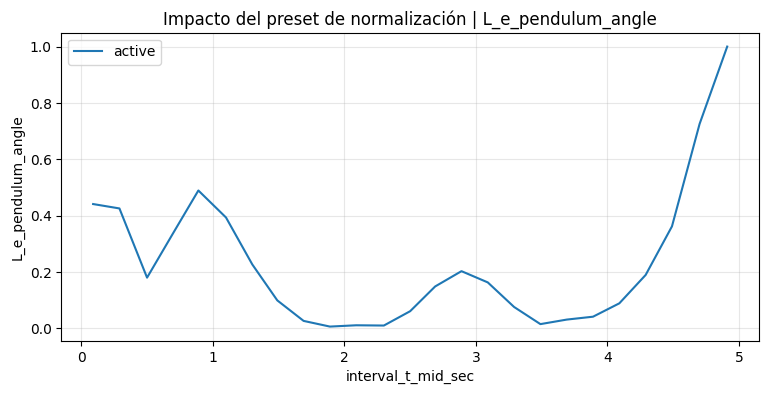

In [644]:
# ============================================================
# 3.19 Comparación entre presets de normalización
# ============================================================

# Opciones para comparison_feature_key:
#   "L_e_pendulum_angle"
#   "L_edot_pendulum_angle"
#   "L_I_pendulum_angle"
#   "L_u_pendulum_angle"
#   "L_e_cart_position"
#   "L_edot_cart_position"
#   "L_I_cart_position"
#   "L_u_cart_position"

comparison_feature_key = "L_e_pendulum_angle"

preset_feature_tables = {}

for preset_name, preset_config in normalization_presets.items():
    preset_feature_tables[preset_name] = compute_interval_feature_table(
        trace_df=trajectory_df,
        var_objs=var_objs,
        aggregation_config=preset_config,
        output_limits=reward_component_output_limits,
        decision_interval_sec=decision_interval_sec,
    )

plt.figure(figsize=(9, 4))

for preset_name, preset_df in preset_feature_tables.items():
    plt.plot(
        preset_df["interval_t_mid_sec"],
        preset_df[comparison_feature_key],
        label=preset_name,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel(comparison_feature_key)
plt.title(f"Impacto del preset de normalización | {comparison_feature_key}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3.10 Vista plana tipo reward_component

In [646]:
# ============================================================
# 3.10 Vista plana compatible con reward_component
# ============================================================

# Seleccionar intervalo para inspección.
#
# Opciones:
#   cualquier valor de interval_id presente en interval_feature_df

selected_interval_id = 2

selected_interval_row = interval_feature_df[
    interval_feature_df["interval_id"] == selected_interval_id
].iloc[0]

reward_component_preview = {
    feature_key: float(selected_interval_row[feature_key])
    for feature_key in reward_feature_keys
}

display(pd.DataFrame([reward_component_preview]).T.rename(columns={0: "value"}))

,value
L_e_pendulum_angle,0.180208
L_edot_pendulum_angle,0.647357
L_I_pendulum_angle,0.032694
L_u_pendulum_angle,0.222880
L_e_cart_position,0.065721
L_edot_cart_position,0.177453
L_I_cart_position,0.005118
L_u_cart_position,0.135485


## 3.11 Persistencia mínima de la sección

In [647]:
# ============================================================
# 3.11 Persistencia mínima de esta sección
# ============================================================

reward_design["normalization_design"] = {
    "active_normalization_preset": active_normalization_preset,
    "normalization_presets": normalization_presets,
    "aggregation_config": aggregation_config,
    "reward_component_output_limits": reward_component_output_limits,
    "normalization_config_df": normalization_config_df.copy(),
}

reward_design["interval_features"] = {
    "active_trajectory_name": active_trajectory_name,
    "interval_feature_df": interval_feature_df.copy(),
    "reward_feature_keys": list(reward_feature_keys),
    "reward_component_preview": dict(reward_component_preview),
}

print("Normalización registrada en reward_design['normalization_design'].")
print("Features por intervalo registradas en reward_design['interval_features'].")
print(f"Preset activo: {active_normalization_preset}")
print(f"Trayectoria activa: {active_trajectory_name}")

Normalización registrada en reward_design['normalization_design'].
Features por intervalo registradas en reward_design['interval_features'].
Preset activo: active
Trayectoria activa: manual_u_total_reference


# Sección 4 - Diseño de recompensa principal gaussiana

# 4. Diseño de recompensa principal gaussiana

Esta sección diseña la recompensa principal sin compuertas.

La pregunta física es:

> ¿Cómo traducimos desempeño local de cada lazo en una señal densa, acotada e interpretable?

La recompensa principal usa los componentes normalizados construidos en la sección anterior:

- `L_e_<var_obj>`
- `L_edot_<var_obj>`
- `L_I_<var_obj>`
- `L_u_<var_obj>`

No se usa `L_delta_u_<var_obj>`.

La forma estudiada es:

$$
r_i = -w_i \cdot \left(1 - \exp(-scaled_i \cdot (L_i - setpoint_i)^2)\right)
$$

donde:

- `weight` controla la importancia relativa de cada feature;
- `sigma` controla la sensibilidad visual;
- `scaled = 1 / sigma^2`;
- `setpoint = 0` representa el desempeño ideal si las features están normalizadas como error/costo.

En esta sección no hay compuertas.
La intención es observar primero la forma pura de la penalización gaussiana.

## 4.1 Inputs locales de recompensa principal

In [653]:
# ============================================================
# 4.1 Inputs configurables de esta sección
# ============================================================

system_context = reward_design["system_context"]
normalization_design = reward_design["normalization_design"]
interval_features = reward_design["interval_features"]

var_objs = system_context["var_objs"]
interval_feature_df = interval_features["interval_feature_df"].copy()
reward_feature_keys = interval_features["reward_feature_keys"]
reward_component_output_limits = normalization_design["reward_component_output_limits"]

# Features disponibles para recompensa principal:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"
#
# No usar:
#   "L_delta_u"

# Configuración global por feature.
#
# Esta configuración es coherente con LagrangeRewardCalculator:
# las features son globales y se aplican sobre cada var_obj.
#
# Opciones para enabled:
#   True
#   False
#
# Opciones típicas para setpoint:
#   0.0  -> ideal si L representa costo/error normalizado
#
# Lectura práctica de sigma:
#   sigma pequeño -> penalización más sensible
#   sigma grande  -> penalización más tolerante

principal_reward_feature_config = {
    "L_e": {
        "enabled": True,
        "weight": 0.55,
        "sigma": 5.0,
        "setpoint": 0.0,
    },
    "L_edot": {
        "enabled": True,
        "weight": 0.35,
        "sigma": 3.0,
        "setpoint": 0.0,
    },
    "L_I": {
        "enabled": True,
        "weight": 0.0,
        "sigma": 1.0,
        "setpoint": 0.0,
    },
    "L_u": {
        "enabled": True,
        "weight": 0.1,
        "sigma": 1.0,
        "setpoint": 0.0,
    },
}

# Nombre de la trayectoria y preset usados para esta lectura.
active_trajectory_name = interval_features["active_trajectory_name"]
active_normalization_preset = normalization_design["active_normalization_preset"]

# Variables disponibles para analizar por separado:
#   "pendulum_angle"
#   "cart_position"

selected_principal_var_obj = "pendulum_angle"

## 4.2 Helpers locales para recompensa principal

In [649]:
def resolve_principal_feature_params(
    feature_name: str,
    feature_config: Dict[str, Dict[str, float]],
) -> Dict[str, float]:
    """
    Resuelve parámetros de una feature de recompensa principal.
    """
    cfg = feature_config[feature_name]

    sigma = float(cfg["sigma"])
    scaled = sigma_to_scaled(sigma)

    return {
        "enabled": bool(cfg["enabled"]),
        "weight": float(cfg["weight"]),
        "sigma": sigma,
        "scaled": scaled,
        "setpoint": float(cfg["setpoint"]),
    }


def build_principal_reward_config_table(
    feature_config: Dict[str, Dict[str, float]],
) -> pd.DataFrame:
    """
    Construye una tabla legible de configuración principal.
    """
    rows = []

    for feature_name in REWARD_FEATURES:
        params = resolve_principal_feature_params(
            feature_name=feature_name,
            feature_config=feature_config,
        )

        rows.append(
            {
                "feature": feature_name,
                "enabled": params["enabled"],
                "weight": params["weight"],
                "sigma": params["sigma"],
                "scaled": params["scaled"],
                "setpoint": params["setpoint"],
            }
        )

    return pd.DataFrame(rows)


def compute_principal_reward_table(
    interval_feature_df: pd.DataFrame,
    var_objs: Sequence[str],
    feature_config: Dict[str, Dict[str, float]],
    gate_table_df: Optional[pd.DataFrame] = None,
    record_prefix: str = "principal",
) -> pd.DataFrame:
    """
    Calcula recompensa principal por intervalo.

    Si gate_table_df es None:
        gate_factor = 1.0 para todas las contribuciones.

    Si gate_table_df existe:
        usa columnas principal_gate_<feature>_<var_obj>.
    """
    records = []

    gate_by_interval = None
    if gate_table_df is not None:
        gate_by_interval = gate_table_df.set_index("interval_id")

    for _, interval_row in interval_feature_df.iterrows():
        interval_id = int(interval_row["interval_id"])

        record = {
            "interval_id": interval_id,
            "interval_t_start_sec": float(interval_row["interval_t_start_sec"]),
            "interval_t_end_sec": float(interval_row["interval_t_end_sec"]),
            "interval_t_mid_sec": float(interval_row["interval_t_mid_sec"]),
        }

        total_reward = 0.0
        feature_reward_sum = {feature_name: 0.0 for feature_name in REWARD_FEATURES}
        feature_value_sum = {feature_name: 0.0 for feature_name in REWARD_FEATURES}

        for var_obj in var_objs:
            loop_reward = 0.0

            for feature_name in REWARD_FEATURES:
                params = resolve_principal_feature_params(
                    feature_name=feature_name,
                    feature_config=feature_config,
                )

                feature_key = f"{feature_name}_{var_obj}"
                value = float(interval_row[feature_key])

                if gate_by_interval is None:
                    gate_value = 1.0
                else:
                    gate_key = f"principal_gate_{feature_name}_{var_obj}"
                    gate_value = float(gate_by_interval.loc[interval_id, gate_key])

                if params["enabled"]:
                    exp_term = math.exp(
                        -params["scaled"] * ((value - params["setpoint"]) ** 2)
                    )
                    contribution = -gate_value * params["weight"] * (1.0 - exp_term)
                else:
                    exp_term = 1.0
                    contribution = 0.0

                contribution_key = f"{record_prefix}_contribution_{feature_name}_{var_obj}"
                similarity_key = f"{record_prefix}_similarity_{feature_name}_{var_obj}"

                record[contribution_key] = contribution
                record[similarity_key] = exp_term

                loop_reward += contribution
                total_reward += contribution
                feature_reward_sum[feature_name] += contribution
                feature_value_sum[feature_name] += value

            record[f"{record_prefix}_reward_{var_obj}"] = loop_reward

        for feature_name in REWARD_FEATURES:
            record[f"{record_prefix}_feature_value_{feature_name}"] = feature_value_sum[feature_name]
            record[f"{record_prefix}_feature_reward_{feature_name}"] = feature_reward_sum[feature_name]

        record[f"{record_prefix}_reward"] = total_reward
        records.append(record)

    return pd.DataFrame(records)

## 4.3 Calcular recompensa principal sin compuertas

In [654]:
# ============================================================
# 4.3 Calcular recompensa principal sin compuertas
# ============================================================

principal_reward_config_df = build_principal_reward_config_table(
    feature_config=principal_reward_feature_config,
)

principal_reward_df = compute_principal_reward_table(
    interval_feature_df=interval_feature_df,
    var_objs=var_objs,
    feature_config=principal_reward_feature_config,
    gate_table_df=None,
    record_prefix="principal",
)

display(principal_reward_config_df)

principal_reward_view_columns = [
    "interval_id",
    "interval_t_mid_sec",
    "principal_reward",
]

for var_obj in var_objs:
    principal_reward_view_columns.append(f"principal_reward_{var_obj}")

for feature_name in REWARD_FEATURES:
    principal_reward_view_columns.append(f"principal_feature_reward_{feature_name}")

display(principal_reward_df[principal_reward_view_columns].head(10))

,feature,enabled,weight,sigma,scaled,setpoint
0,L_e,True,0.55,5.0,0.040000,0.0
1,L_edot,True,0.35,3.0,0.111111,0.0
2,L_I,True,0.00,1.0,1.000000,0.0
3,L_u,True,0.10,1.0,1.000000,0.0


,interval_id,interval_t_mid_sec,principal_reward,principal_reward_pendulum_angle,principal_reward_cart_position,principal_feature_reward_L_e,principal_feature_reward_L_edot,principal_feature_reward_L_I,principal_feature_reward_L_u
0,0,0.09,-0.010688,-0.010679,-0.000009,-0.004268,-0.000094,0.0,-0.006325
1,1,0.29,-0.033202,-0.032459,-0.000742,-0.003979,-0.002298,0.0,-0.026924
2,2,0.50,-0.024620,-0.021484,-0.003136,-0.000809,-0.017146,0.0,-0.006665
3,3,0.70,-0.030857,-0.020959,-0.009898,-0.002861,-0.011070,0.0,-0.016926
4,4,0.89,-0.023600,-0.015451,-0.008149,-0.005753,-0.000692,0.0,-0.017155
5,5,1.10,-0.009880,-0.007306,-0.002574,-0.003893,-0.002124,0.0,-0.003863
6,6,1.30,-0.004167,-0.003390,-0.000778,-0.001511,-0.002326,0.0,-0.000330
7,7,1.49,-0.001683,-0.001161,-0.000522,-0.000480,-0.001110,0.0,-0.000093
8,8,1.69,-0.000660,-0.000170,-0.000491,-0.000187,-0.000278,0.0,-0.000195
9,9,1.89,-0.000267,-0.000005,-0.000262,-0.000110,-0.000099,0.0,-0.000058


## 4.4 Curva gaussiana de una feature

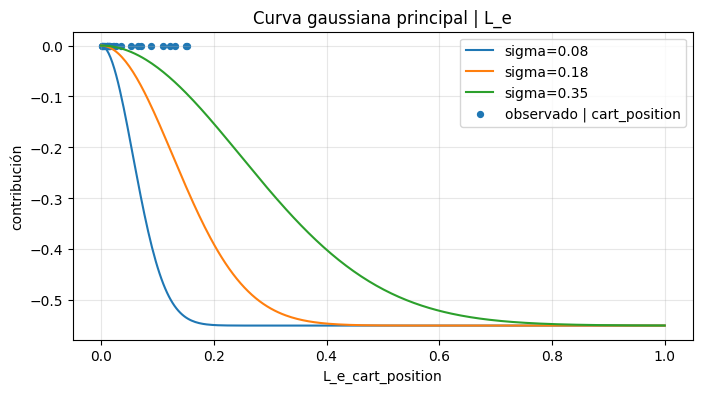

In [656]:
# ============================================================
# 4.4 Curva feature -> contribución de recompensa
# ============================================================

# Opciones para curve_feature_name:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

curve_feature_name = "L_e"

# Opciones para curve_var_obj:
#   "pendulum_angle"
#   "cart_position"

curve_var_obj = "cart_position"

# Valores sigma a comparar.
#
# Interpretación:
#   sigma pequeño -> curva más estricta
#   sigma grande  -> curva más tolerante

curve_sigma_values = [0.08, 0.18, 0.35]

params = resolve_principal_feature_params(
    feature_name=curve_feature_name,
    feature_config=principal_reward_feature_config,
)

x_values = np.linspace(
    reward_component_output_limits[0],
    reward_component_output_limits[1],
    300,
)

plt.figure(figsize=(8, 4))

for sigma_value in curve_sigma_values:
    y_values = [
        weighted_exponential_penalty(
            value=x,
            weight=params["weight"],
            sigma=sigma_value,
            setpoint=params["setpoint"],
            gate=1.0,
        )
        for x in x_values
    ]

    plt.plot(
        x_values,
        y_values,
        label=f"sigma={sigma_value}",
    )

observed_values = interval_feature_df[f"{curve_feature_name}_{curve_var_obj}"]

plt.scatter(
    observed_values,
    [
        weighted_exponential_penalty(
            value=x,
            weight=params["weight"],
            sigma=params["sigma"],
            setpoint=params["setpoint"],
            gate=1.0,
        )
        for x in observed_values
    ],
    s=18,
    label=f"observado | {curve_var_obj}",
)

plt.xlabel(f"{curve_feature_name}_{curve_var_obj}")
plt.ylabel("contribución")
plt.title(f"Curva gaussiana principal | {curve_feature_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4.5 Evolución temporal de recompensa principal

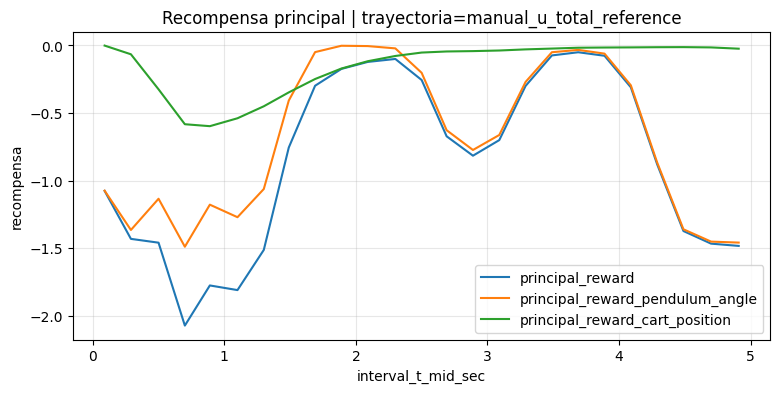

In [652]:
# ============================================================
# 4.5 Evolución temporal de recompensa principal
# ============================================================

# Opciones para selected_principal_series_keys:
#   "principal_reward"
#   "principal_reward_pendulum_angle"
#   "principal_reward_cart_position"
#   "principal_feature_reward_L_e"
#   "principal_feature_reward_L_edot"
#   "principal_feature_reward_L_I"
#   "principal_feature_reward_L_u"
#   "principal_contribution_L_e_pendulum_angle"
#   "principal_contribution_L_edot_pendulum_angle"
#   "principal_contribution_L_I_pendulum_angle"
#   "principal_contribution_L_u_pendulum_angle"
#   "principal_contribution_L_e_cart_position"
#   "principal_contribution_L_edot_cart_position"
#   "principal_contribution_L_I_cart_position"
#   "principal_contribution_L_u_cart_position"

selected_principal_series_keys = [
    "principal_reward",
    "principal_reward_pendulum_angle",
    "principal_reward_cart_position",
]

plt.figure(figsize=(9, 4))

for series_key in selected_principal_series_keys:
    plt.plot(
        principal_reward_df["interval_t_mid_sec"],
        principal_reward_df[series_key],
        label=series_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("recompensa")
plt.title(f"Recompensa principal | trayectoria={active_trajectory_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4.6 Scatter entre features y recompensa local

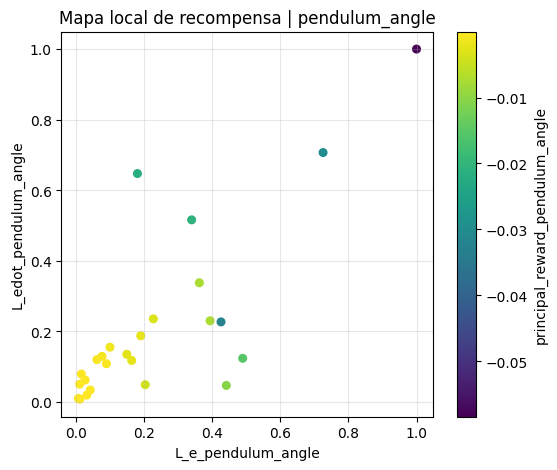

In [657]:
# ============================================================
# 4.6 Scatter entre features y recompensa local
# ============================================================

# Opciones para scatter_var_obj:
#   "pendulum_angle"
#   "cart_position"

scatter_var_obj = "pendulum_angle"

# Opciones para x_feature_name:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

x_feature_name = "L_e"

# Opciones para y_feature_name:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

y_feature_name = "L_edot"

x_key = f"{x_feature_name}_{scatter_var_obj}"
y_key = f"{y_feature_name}_{scatter_var_obj}"
reward_key = f"principal_reward_{scatter_var_obj}"

scatter_df = interval_feature_df[
    [
        "interval_id",
        "interval_t_mid_sec",
        x_key,
        y_key,
    ]
].merge(
    principal_reward_df[
        [
            "interval_id",
            reward_key,
        ]
    ],
    on="interval_id",
)

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    scatter_df[x_key],
    scatter_df[y_key],
    c=scatter_df[reward_key],
    s=30,
)

plt.colorbar(scatter, label=reward_key)
plt.xlabel(x_key)
plt.ylabel(y_key)
plt.title(f"Mapa local de recompensa | {scatter_var_obj}")
plt.grid(True, alpha=0.3)
plt.show()

## 4.7 Distribución continua de recompensa o contribución

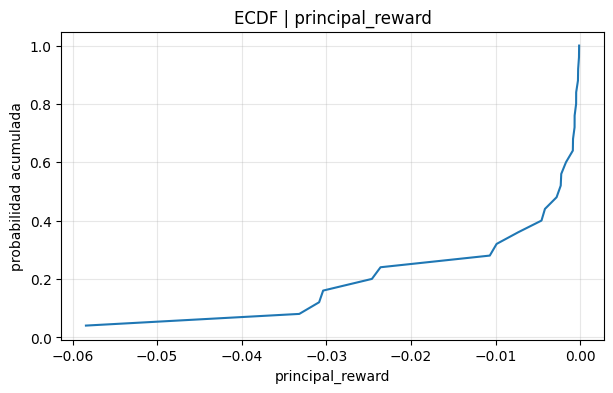

In [658]:
# ============================================================
# 4.7 Distribución continua de recompensa o contribución
# ============================================================

# Opciones para distribution_reward_key:
#   "principal_reward"
#   "principal_reward_pendulum_angle"
#   "principal_reward_cart_position"
#   "principal_feature_reward_L_e"
#   "principal_feature_reward_L_edot"
#   "principal_feature_reward_L_I"
#   "principal_feature_reward_L_u"
#   "principal_contribution_L_e_pendulum_angle"
#   "principal_contribution_L_edot_pendulum_angle"
#   "principal_contribution_L_I_pendulum_angle"
#   "principal_contribution_L_u_pendulum_angle"
#   "principal_contribution_L_e_cart_position"
#   "principal_contribution_L_edot_cart_position"
#   "principal_contribution_L_I_cart_position"
#   "principal_contribution_L_u_cart_position"

distribution_reward_key = "principal_reward"

values = np.sort(principal_reward_df[distribution_reward_key].to_numpy(dtype=float))
probability = np.arange(1, len(values) + 1) / len(values)

plt.figure(figsize=(7, 4))
plt.plot(values, probability)
plt.xlabel(distribution_reward_key)
plt.ylabel("probabilidad acumulada")
plt.title(f"ECDF | {distribution_reward_key}")
plt.grid(True, alpha=0.3)
plt.show()

## 4.8 Sensibilidad continua de peso y sigma

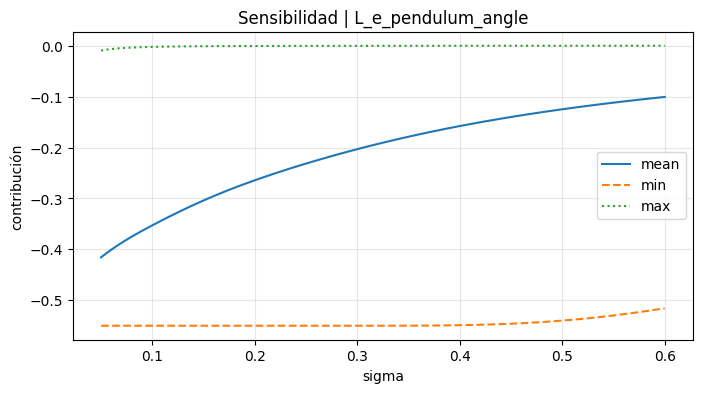

In [660]:
# ============================================================
# 4.8 Sensibilidad continua de peso y sigma
# ============================================================

# Opciones para sensitivity_feature_name:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

sensitivity_feature_name = "L_e"

# Opciones para sensitivity_var_obj:
#   "pendulum_angle"
#   "cart_position"

sensitivity_var_obj = "pendulum_angle"

# Variable que se moverá en el eje x.
#
# Opciones:
#   "weight"
#   "sigma"

sensitivity_axis = "sigma"

# Rango de sensibilidad si sensitivity_axis = "sigma".
sensitivity_sigma_values = np.linspace(0.05, 0.60, 120)

# Rango de sensibilidad si sensitivity_axis = "weight".
sensitivity_weight_values = np.linspace(0.01, 2.00, 120)

base_params = resolve_principal_feature_params(
    feature_name=sensitivity_feature_name,
    feature_config=principal_reward_feature_config,
)

feature_values = interval_feature_df[f"{sensitivity_feature_name}_{sensitivity_var_obj}"].to_numpy(dtype=float)

sensitivity_rows = []

if sensitivity_axis == "sigma":
    for sigma_value in sensitivity_sigma_values:
        contributions = [
            weighted_exponential_penalty(
                value=value,
                weight=base_params["weight"],
                sigma=sigma_value,
                setpoint=base_params["setpoint"],
                gate=1.0,
            )
            for value in feature_values
        ]

        sensitivity_rows.append(
            {
                "param_value": sigma_value,
                "mean_contribution": float(np.mean(contributions)),
                "min_contribution": float(np.min(contributions)),
                "max_contribution": float(np.max(contributions)),
            }
        )

else:
    for weight_value in sensitivity_weight_values:
        contributions = [
            weighted_exponential_penalty(
                value=value,
                weight=weight_value,
                sigma=base_params["sigma"],
                setpoint=base_params["setpoint"],
                gate=1.0,
            )
            for value in feature_values
        ]

        sensitivity_rows.append(
            {
                "param_value": weight_value,
                "mean_contribution": float(np.mean(contributions)),
                "min_contribution": float(np.min(contributions)),
                "max_contribution": float(np.max(contributions)),
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows)

plt.figure(figsize=(8, 4))
plt.plot(sensitivity_df["param_value"], sensitivity_df["mean_contribution"], label="mean")
plt.plot(sensitivity_df["param_value"], sensitivity_df["min_contribution"], linestyle="--", label="min")
plt.plot(sensitivity_df["param_value"], sensitivity_df["max_contribution"], linestyle=":", label="max")
plt.xlabel(sensitivity_axis)
plt.ylabel("contribución")
plt.title(f"Sensibilidad | {sensitivity_feature_name}_{sensitivity_var_obj}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4.9 Dashboard interactivo de recompensa principal

In [661]:
# ============================================================
# 4.9 Dashboard interactivo de recompensa principal
# ============================================================

last_interactive_principal_reward_df = principal_reward_df.copy()

def interactive_principal_reward_preview(
    selected_var_obj="pendulum_angle",
    w_e=1.00,
    sigma_e=0.18,
    w_edot=0.45,
    sigma_edot=0.25,
    w_I=0.20,
    sigma_I=0.35,
    w_u=0.12,
    sigma_u=0.30,
):
    """
    Vista interactiva de recompensa principal sin compuertas.

    La configuración modificada es global por feature.
    selected_var_obj solo decide qué lazo se muestra con mayor detalle.
    """
    global last_interactive_principal_reward_df

    local_feature_config = {
        "L_e": {
            "enabled": True,
            "weight": w_e,
            "sigma": sigma_e,
            "setpoint": 0.0,
        },
        "L_edot": {
            "enabled": True,
            "weight": w_edot,
            "sigma": sigma_edot,
            "setpoint": 0.0,
        },
        "L_I": {
            "enabled": True,
            "weight": w_I,
            "sigma": sigma_I,
            "setpoint": 0.0,
        },
        "L_u": {
            "enabled": True,
            "weight": w_u,
            "sigma": sigma_u,
            "setpoint": 0.0,
        },
    }

    local_reward_df = compute_principal_reward_table(
        interval_feature_df=interval_feature_df,
        var_objs=var_objs,
        feature_config=local_feature_config,
        gate_table_df=None,
        record_prefix="principal",
    )

    last_interactive_principal_reward_df = local_reward_df.copy()

    plt.figure(figsize=(9, 4))
    plt.plot(
        local_reward_df["interval_t_mid_sec"],
        local_reward_df["principal_reward"],
        label="principal_reward",
    )
    plt.plot(
        local_reward_df["interval_t_mid_sec"],
        local_reward_df[f"principal_reward_{selected_var_obj}"],
        label=f"principal_reward_{selected_var_obj}",
    )
    plt.xlabel("interval_t_mid_sec")
    plt.ylabel("recompensa")
    plt.title("Recompensa principal interactiva")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    x_key = f"L_e_{selected_var_obj}"
    y_key = f"L_edot_{selected_var_obj}"
    reward_key = f"principal_reward_{selected_var_obj}"

    local_scatter_df = interval_feature_df[
        [
            "interval_id",
            x_key,
            y_key,
        ]
    ].merge(
        local_reward_df[
            [
                "interval_id",
                reward_key,
            ]
        ],
        on="interval_id",
    )

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        local_scatter_df[x_key],
        local_scatter_df[y_key],
        c=local_scatter_df[reward_key],
        s=30,
    )
    plt.colorbar(scatter, label=reward_key)
    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.title(f"Espacio local | {selected_var_obj}")
    plt.grid(True, alpha=0.3)
    plt.show()

    x_values = np.linspace(
        reward_component_output_limits[0],
        reward_component_output_limits[1],
        300,
    )

    plt.figure(figsize=(8, 4))

    for feature_name in REWARD_FEATURES:
        params = resolve_principal_feature_params(
            feature_name=feature_name,
            feature_config=local_feature_config,
        )

        y_values = [
            weighted_exponential_penalty(
                value=x,
                weight=params["weight"],
                sigma=params["sigma"],
                setpoint=params["setpoint"],
                gate=1.0,
            )
            for x in x_values
        ]

        plt.plot(x_values, y_values, label=feature_name)

    plt.xlabel("L normalizado")
    plt.ylabel("contribución")
    plt.title("Curvas gaussianas por feature")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


widgets.interact(
    interactive_principal_reward_preview,
    selected_var_obj=widgets.Dropdown(
        options=list(var_objs),
        value=selected_principal_var_obj,
    ),
    w_e=widgets.FloatSlider(value=1.00, min=0.0, max=3.0, step=0.05),
    sigma_e=widgets.FloatSlider(value=0.18, min=0.03, max=1.0, step=0.01),
    w_edot=widgets.FloatSlider(value=0.45, min=0.0, max=3.0, step=0.05),
    sigma_edot=widgets.FloatSlider(value=0.25, min=0.03, max=1.0, step=0.01),
    w_I=widgets.FloatSlider(value=0.20, min=0.0, max=3.0, step=0.05),
    sigma_I=widgets.FloatSlider(value=0.35, min=0.03, max=1.0, step=0.01),
    w_u=widgets.FloatSlider(value=0.12, min=0.0, max=3.0, step=0.05),
    sigma_u=widgets.FloatSlider(value=0.30, min=0.03, max=1.0, step=0.01),
)

interactive(children=(Dropdown(description='selected_var_obj', options=('pendulum_angle', 'cart_position'), va…

<function __main__.interactive_principal_reward_preview(selected_var_obj='pendulum_angle', w_e=1.0, sigma_e=0.18, w_edot=0.45, sigma_edot=0.25, w_I=0.2, sigma_I=0.35, w_u=0.12, sigma_u=0.3)>

## 4.10 Persistencia mínima de la sección

In [662]:
# ============================================================
# 4.10 Persistencia mínima de esta sección
# ============================================================

principal_weighted_exponential_params = {
    "features": {
        feature_name: {
            "enabled": params["enabled"],
            "weight": params["weight"],
            "sigma": params["sigma"],
            "scaled": params["scaled"],
            "setpoint": params["setpoint"],
        }
        for feature_name, params in {
            feature_name: resolve_principal_feature_params(
                feature_name=feature_name,
                feature_config=principal_reward_feature_config,
            )
            for feature_name in REWARD_FEATURES
        }.items()
    }
}

reward_design["principal_reward_design"] = {
    "method": "weighted_exponential",
    "principal_reward_feature_config": principal_reward_feature_config,
    "principal_weighted_exponential_params": principal_weighted_exponential_params,
    "principal_reward_config_df": principal_reward_config_df.copy(),
    "principal_reward_df": principal_reward_df.copy(),
    "last_interactive_principal_reward_df": last_interactive_principal_reward_df.copy(),
}

print("Recompensa principal registrada en reward_design['principal_reward_design'].")
print(f"Trayectoria activa: {active_trajectory_name}")
print(f"Preset de normalización activo: {active_normalization_preset}")

Recompensa principal registrada en reward_design['principal_reward_design'].
Trayectoria activa: manual_u_total_reference
Preset de normalización activo: active


# 5. Diseño de compuertas para la recompensa principal

Esta sección agrega compuertas a la recompensa principal.

La pregunta física es:

> ¿Cuándo debe importar cada término de la recompensa?

Las compuertas permiten modular una feature usando otra señal como fuente.

Ejemplos de intención:

- No penalizar demasiado `L_u` cuando el sistema está lejos del objetivo.
- Activar más la penalización de esfuerzo cuando el sistema ya está cerca de una región útil.
- Evitar que una feature desaparezca completamente usando `min_factor`.
- Comparar compuertas suaves tipo `exp` contra compuertas monotónicas tipo `tanh`.
- Evaluar si conviene invertir la compuerta.

La forma final queda:

$$
r_i = -gate_i \cdot w_i \cdot \left(1 - \exp(-scaled_i \cdot (L_i - setpoint_i)^2)\right)
$$

Las compuertas siguen el contrato del proyecto:

- `source`: señal plana usada como fuente;
- `type`: `"exp"` o `"tanh"`;
- `strength`: sensibilidad de la compuerta;
- `setpoint`: centro o referencia;
- `invert`: inversión de la compuerta;
- `min_factor`: valor mínimo;
- `max_factor`: valor máximo;
- `per_var`: ajustes específicos por variable controlada.

## Código 5.1 Inputs locales de compuertas

In [663]:
# ============================================================
# 5.1 Inputs configurables de esta sección
# ============================================================

principal_reward_design = reward_design["principal_reward_design"]
interval_features = reward_design["interval_features"]

principal_reward_feature_config = principal_reward_design["principal_reward_feature_config"]
principal_reward_df = principal_reward_design["principal_reward_df"].copy()

interval_feature_df = interval_features["interval_feature_df"].copy()
reward_feature_keys = interval_features["reward_feature_keys"]

# Fuentes disponibles para compuertas.
#
# Fuentes normalizadas estables:
#   "L_e_{var_obj}"
#   "L_edot_{var_obj}"
#   "L_I_{var_obj}"
#   "L_u_{var_obj}"
#
# Fuentes agregadas posibles si el método de agregación coincide con la sección 3:
#   "error_{var_obj}_mean_squared"
#   "derivative_error_{var_obj}_rms"
#   "integral_error_{var_obj}_abs"
#   "u_eff_{var_obj}_mean_squared"
#
# Tipos de compuerta:
#   "exp"   -> alta cerca del setpoint, baja lejos del setpoint
#   "tanh"  -> baja cerca del setpoint, alta lejos del setpoint
#
# invert:
#   False -> usa factor directo
#   True  -> usa 1 - factor
#
# min_factor:
#   evita que una feature desaparezca completamente.
#
# max_factor:
#   techo de activación.

feature_gates = {
    "L_e": {
        "enabled": False,
        "source": "L_e_{var_obj}",
        "type": "exp",
        "strength": 0.30,
        "setpoint": 0.0,
        "invert": False,
        "min_factor": 1.0,
        "max_factor": 1.0,
        "use_abs": True,
        "use_sqrt": False,
        "per_var": {},
    },
    "L_edot": {
        "enabled": True,
        "source": "L_e_{var_obj}",
        "type": "exp",
        "strength": 0.45,
        "setpoint": 0.0,
        "invert": False,
        "min_factor": 0.15,
        "max_factor": 1.0,
        "use_abs": True,
        "use_sqrt": False,
        "per_var": {
            # Variables disponibles:
            #   "pendulum_angle"
            #   "cart_position"
            "pendulum_angle": {
                "strength": 0.35,
                "min_factor": 0.20,
            },
            "cart_position": {
                "strength": 0.55,
                "min_factor": 0.10,
            },
        },
    },
    "L_I": {
        "enabled": True,
        "source": "L_e_{var_obj}",
        "type": "exp",
        "strength": 0.35,
        "setpoint": 0.0,
        "invert": False,
        "min_factor": 0.10,
        "max_factor": 1.0,
        "use_abs": True,
        "use_sqrt": False,
        "per_var": {
            "pendulum_angle": {
                "strength": 0.30,
                "min_factor": 0.08,
            },
            "cart_position": {
                "strength": 0.45,
                "min_factor": 0.12,
            },
        },
    },
    "L_u": {
        "enabled": True,
        "source": "L_e_{var_obj}",
        "type": "exp",
        "strength": 0.25,
        "setpoint": 0.0,
        "invert": False,
        "min_factor": 0.05,
        "max_factor": 1.0,
        "use_abs": True,
        "use_sqrt": False,
        "per_var": {
            "pendulum_angle": {
                "strength": 0.22,
                "min_factor": 0.04,
            },
            "cart_position": {
                "strength": 0.40,
                "min_factor": 0.08,
            },
        },
    },
}

# Variables disponibles para inspección:
#   "pendulum_angle"
#   "cart_position"

selected_gate_var_obj = "pendulum_angle"

# Features disponibles para inspección:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

selected_gate_feature = "L_u"

## Código 5.2 Helpers locales de compuertas

In [664]:
def resolve_gate_config_for_var(
    feature_gates: Dict[str, Dict[str, object]],
    feature_name: str,
    var_obj: str,
) -> Dict[str, object]:
    """
    Resuelve la configuración de compuerta para una feature y un var_obj.
    """
    base_cfg = dict(feature_gates.get(feature_name, {}))
    per_var = base_cfg.pop("per_var", {})

    if var_obj in per_var:
        local_cfg = dict(base_cfg)
        local_cfg.update(per_var[var_obj])
    else:
        local_cfg = dict(base_cfg)

    local_cfg.setdefault("enabled", False)
    local_cfg.setdefault("source", f"{feature_name}_{var_obj}")
    local_cfg.setdefault("type", "exp")
    local_cfg.setdefault("strength", 1.0)
    local_cfg.setdefault("setpoint", 0.0)
    local_cfg.setdefault("invert", False)
    local_cfg.setdefault("min_factor", 0.0)
    local_cfg.setdefault("max_factor", 1.0)
    local_cfg.setdefault("use_abs", True)
    local_cfg.setdefault("use_sqrt", False)

    source = local_cfg["source"]

    if isinstance(source, str):
        local_cfg["source"] = source.format(var_obj=var_obj)

    return local_cfg


def build_gate_config_table(
    feature_gates: Dict[str, Dict[str, object]],
    var_objs: Sequence[str],
) -> pd.DataFrame:
    """
    Construye una tabla legible de compuertas resueltas por variable.
    """
    rows = []

    for var_obj in var_objs:
        for feature_name in REWARD_FEATURES:
            cfg = resolve_gate_config_for_var(
                feature_gates=feature_gates,
                feature_name=feature_name,
                var_obj=var_obj,
            )

            rows.append(
                {
                    "var_obj": var_obj,
                    "feature": feature_name,
                    "enabled": cfg["enabled"],
                    "source": cfg["source"],
                    "type": cfg["type"],
                    "strength": cfg["strength"],
                    "setpoint": cfg["setpoint"],
                    "invert": cfg["invert"],
                    "min_factor": cfg["min_factor"],
                    "max_factor": cfg["max_factor"],
                    "use_abs": cfg["use_abs"],
                    "use_sqrt": cfg["use_sqrt"],
                }
            )

    return pd.DataFrame(rows)


def compute_principal_gate_table(
    interval_feature_df: pd.DataFrame,
    var_objs: Sequence[str],
    feature_gates: Dict[str, Dict[str, object]],
) -> pd.DataFrame:
    """
    Calcula factores de compuerta por intervalo, feature y variable.
    """
    records = []

    for _, interval_row in interval_feature_df.iterrows():
        record = {
            "interval_id": int(interval_row["interval_id"]),
            "interval_t_mid_sec": float(interval_row["interval_t_mid_sec"]),
        }

        for var_obj in var_objs:
            for feature_name in REWARD_FEATURES:
                cfg = resolve_gate_config_for_var(
                    feature_gates=feature_gates,
                    feature_name=feature_name,
                    var_obj=var_obj,
                )

                gate_key = f"principal_gate_{feature_name}_{var_obj}"
                source_value_key = f"principal_gate_source_value_{feature_name}_{var_obj}"

                if cfg["enabled"]:
                    source_value = float(interval_row[cfg["source"]])

                    factor = gate_factor(
                        source_value=source_value,
                        gate_type=cfg["type"],
                        strength=cfg["strength"],
                        setpoint=cfg["setpoint"],
                        invert=cfg["invert"],
                        min_factor=cfg["min_factor"],
                        max_factor=cfg["max_factor"],
                        use_abs=cfg["use_abs"],
                        use_sqrt=cfg["use_sqrt"],
                    )
                else:
                    source_value = np.nan
                    factor = 1.0

                record[gate_key] = factor
                record[source_value_key] = source_value

        records.append(record)

    return pd.DataFrame(records)

## 5.3 Calcular compuertas y recompensa principal compuerta

In [665]:
# ============================================================
# 5.3 Calcular compuertas y recompensa principal compuerta
# ============================================================

gate_config_df = build_gate_config_table(
    feature_gates=feature_gates,
    var_objs=var_objs,
)

principal_gate_df = compute_principal_gate_table(
    interval_feature_df=interval_feature_df,
    var_objs=var_objs,
    feature_gates=feature_gates,
)

gated_principal_reward_df = compute_principal_reward_table(
    interval_feature_df=interval_feature_df,
    var_objs=var_objs,
    feature_config=principal_reward_feature_config,
    gate_table_df=principal_gate_df,
    record_prefix="gated_principal",
)

reward_gate_comparison_df = principal_reward_df[
    [
        "interval_id",
        "interval_t_mid_sec",
        "principal_reward",
        *[f"principal_reward_{var_obj}" for var_obj in var_objs],
    ]
].merge(
    gated_principal_reward_df[
        [
            "interval_id",
            "gated_principal_reward",
            *[f"gated_principal_reward_{var_obj}" for var_obj in var_objs],
        ]
    ],
    on="interval_id",
)

reward_gate_comparison_df["reward_delta_due_to_gates"] = (
    reward_gate_comparison_df["gated_principal_reward"]
    - reward_gate_comparison_df["principal_reward"]
)

gated_analysis_df = interval_feature_df.merge(
    principal_gate_df,
    on=["interval_id", "interval_t_mid_sec"],
).merge(
    gated_principal_reward_df,
    on=[
        "interval_id",
        "interval_t_start_sec",
        "interval_t_end_sec",
        "interval_t_mid_sec",
    ],
)

display(gate_config_df)
display(
    reward_gate_comparison_df[
        [
            "interval_id",
            "interval_t_mid_sec",
            "principal_reward",
            "gated_principal_reward",
            "reward_delta_due_to_gates",
        ]
    ].head(10)
)

,var_obj,feature,enabled,source,type,strength,setpoint,invert,min_factor,max_factor,use_abs,use_sqrt
0,pendulum_angle,L_e,False,L_e_pendulum_angle,exp,0.30,0.0,False,1.00,1.0,True,False
1,pendulum_angle,L_edot,True,L_e_pendulum_angle,exp,0.35,0.0,False,0.20,1.0,True,False
2,pendulum_angle,L_I,True,L_e_pendulum_angle,exp,0.30,0.0,False,0.08,1.0,True,False
3,pendulum_angle,L_u,True,L_e_pendulum_angle,exp,0.22,0.0,False,0.04,1.0,True,False
4,cart_position,L_e,False,L_e_cart_position,exp,0.30,0.0,False,1.00,1.0,True,False
5,cart_position,L_edot,True,L_e_cart_position,exp,0.55,0.0,False,0.10,1.0,True,False
6,cart_position,L_I,True,L_e_cart_position,exp,0.45,0.0,False,0.12,1.0,True,False
7,cart_position,L_u,True,L_e_cart_position,exp,0.40,0.0,False,0.08,1.0,True,False


,interval_id,interval_t_mid_sec,principal_reward,gated_principal_reward,reward_delta_due_to_gates
0,0,0.09,-0.010688,-0.004548,0.006140
1,1,0.29,-0.033202,-0.006230,0.026972
2,2,0.50,-0.024620,-0.018477,0.006143
3,3,0.70,-0.030857,-0.016347,0.014510
4,4,0.89,-0.023600,-0.012877,0.010723
5,5,1.10,-0.009880,-0.006361,0.003519
6,6,1.30,-0.004167,-0.003328,0.000840
7,7,1.49,-0.001683,-0.001596,0.000087
8,8,1.69,-0.000660,-0.000647,0.000013
9,9,1.89,-0.000267,-0.000264,0.000003


## 5.4 Curva de compuerta

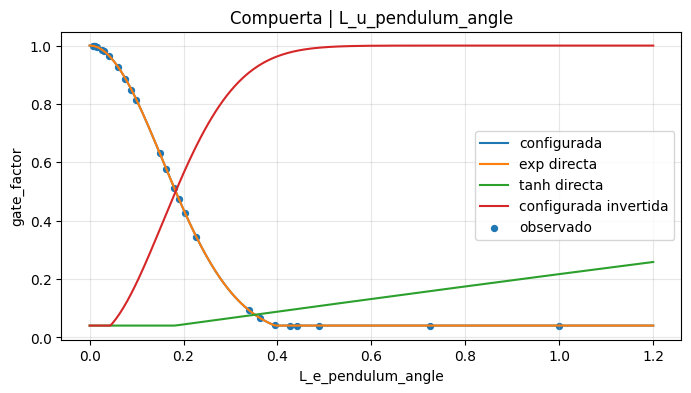

In [666]:
# ============================================================
# 5.4 Curva de compuerta
# ============================================================

# Opciones para selected_gate_feature:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

selected_gate_feature = "L_u"

# Opciones para selected_gate_var_obj:
#   "pendulum_angle"
#   "cart_position"

selected_gate_var_obj = "pendulum_angle"

cfg = resolve_gate_config_for_var(
    feature_gates=feature_gates,
    feature_name=selected_gate_feature,
    var_obj=selected_gate_var_obj,
)

source_values_observed = interval_feature_df[cfg["source"]].to_numpy(dtype=float)
x_max = max(1.0, 1.20 * np.max(np.abs(source_values_observed)))
x_values = np.linspace(0.0, x_max, 300)

gate_curve_variants = [
    {
        "label": "configurada",
        "type": cfg["type"],
        "invert": cfg["invert"],
        "strength": cfg["strength"],
        "min_factor": cfg["min_factor"],
        "max_factor": cfg["max_factor"],
    },
    {
        "label": "exp directa",
        "type": "exp",
        "invert": False,
        "strength": cfg["strength"],
        "min_factor": cfg["min_factor"],
        "max_factor": cfg["max_factor"],
    },
    {
        "label": "tanh directa",
        "type": "tanh",
        "invert": False,
        "strength": cfg["strength"],
        "min_factor": cfg["min_factor"],
        "max_factor": cfg["max_factor"],
    },
    {
        "label": "configurada invertida",
        "type": cfg["type"],
        "invert": not cfg["invert"],
        "strength": cfg["strength"],
        "min_factor": cfg["min_factor"],
        "max_factor": cfg["max_factor"],
    },
]

plt.figure(figsize=(8, 4))

for variant in gate_curve_variants:
    y_values = [
        gate_factor(
            source_value=x,
            gate_type=variant["type"],
            strength=variant["strength"],
            setpoint=cfg["setpoint"],
            invert=variant["invert"],
            min_factor=variant["min_factor"],
            max_factor=variant["max_factor"],
            use_abs=cfg["use_abs"],
            use_sqrt=cfg["use_sqrt"],
        )
        for x in x_values
    ]

    plt.plot(x_values, y_values, label=variant["label"])

plt.scatter(
    source_values_observed,
    principal_gate_df[f"principal_gate_{selected_gate_feature}_{selected_gate_var_obj}"],
    s=18,
    label="observado",
)

plt.xlabel(cfg["source"])
plt.ylabel("gate_factor")
plt.title(f"Compuerta | {selected_gate_feature}_{selected_gate_var_obj}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5.5 Evolución temporal de compuertas

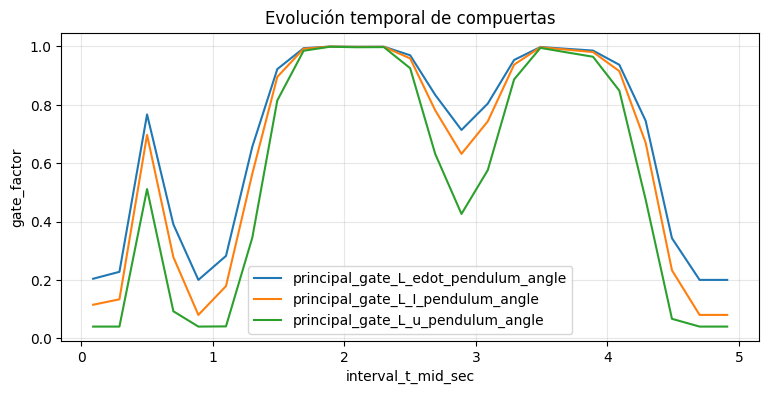

In [667]:
# ============================================================
# 5.5 Evolución temporal de compuertas
# ============================================================

# Opciones para selected_gate_series_keys:
#   "principal_gate_L_e_pendulum_angle"
#   "principal_gate_L_edot_pendulum_angle"
#   "principal_gate_L_I_pendulum_angle"
#   "principal_gate_L_u_pendulum_angle"
#   "principal_gate_L_e_cart_position"
#   "principal_gate_L_edot_cart_position"
#   "principal_gate_L_I_cart_position"
#   "principal_gate_L_u_cart_position"

selected_gate_series_keys = [
    "principal_gate_L_edot_pendulum_angle",
    "principal_gate_L_I_pendulum_angle",
    "principal_gate_L_u_pendulum_angle",
]

plt.figure(figsize=(9, 4))

for gate_key in selected_gate_series_keys:
    plt.plot(
        principal_gate_df["interval_t_mid_sec"],
        principal_gate_df[gate_key],
        label=gate_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("gate_factor")
plt.title("Evolución temporal de compuertas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5.6 Impacto de compuertas sobre recompensa principal

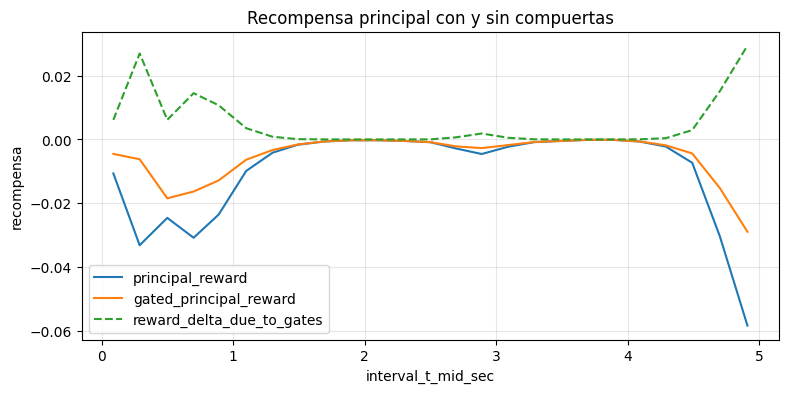

In [668]:
# ============================================================
# 5.6 Impacto de compuertas sobre recompensa principal
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(
    reward_gate_comparison_df["interval_t_mid_sec"],
    reward_gate_comparison_df["principal_reward"],
    label="principal_reward",
)

plt.plot(
    reward_gate_comparison_df["interval_t_mid_sec"],
    reward_gate_comparison_df["gated_principal_reward"],
    label="gated_principal_reward",
)

plt.plot(
    reward_gate_comparison_df["interval_t_mid_sec"],
    reward_gate_comparison_df["reward_delta_due_to_gates"],
    linestyle="--",
    label="reward_delta_due_to_gates",
)

plt.xlabel("interval_t_mid_sec")
plt.ylabel("recompensa")
plt.title("Recompensa principal con y sin compuertas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5.7 Scatter: fuente de compuerta vs contribución compuerta

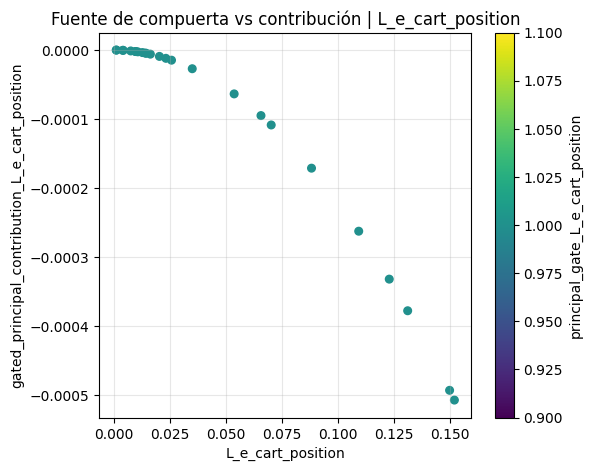

In [671]:
# ============================================================
# 5.7 Scatter: fuente de compuerta vs contribución compuerta
# ============================================================

# Opciones para scatter_gate_feature:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

scatter_gate_feature = "L_e"

# Opciones para scatter_gate_var_obj:
#   "pendulum_angle"
#   "cart_position"

scatter_gate_var_obj = "cart_position"

scatter_gate_cfg = resolve_gate_config_for_var(
    feature_gates=feature_gates,
    feature_name=scatter_gate_feature,
    var_obj=scatter_gate_var_obj,
)

x_key = scatter_gate_cfg["source"]
y_key = f"gated_principal_contribution_{scatter_gate_feature}_{scatter_gate_var_obj}"
color_key = f"principal_gate_{scatter_gate_feature}_{scatter_gate_var_obj}"

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    gated_analysis_df[x_key],
    gated_analysis_df[y_key],
    c=gated_analysis_df[color_key],
    s=30,
)

plt.colorbar(scatter, label=color_key)
plt.xlabel(x_key)
plt.ylabel(y_key)
plt.title(f"Fuente de compuerta vs contribución | {scatter_gate_feature}_{scatter_gate_var_obj}")
plt.grid(True, alpha=0.3)
plt.show()

## 5.8 Distribución continua del efecto de compuerta

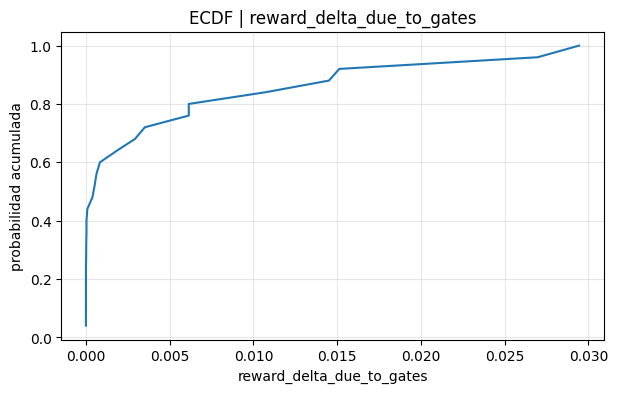

In [672]:
# ============================================================
# 5.8 Distribución continua del efecto de compuerta
# ============================================================

# Opciones para distribution_gate_effect_key:
#   "reward_delta_due_to_gates"
#   "gated_principal_reward"
#   "gated_principal_reward_pendulum_angle"
#   "gated_principal_reward_cart_position"
#   "gated_principal_contribution_L_e_pendulum_angle"
#   "gated_principal_contribution_L_edot_pendulum_angle"
#   "gated_principal_contribution_L_I_pendulum_angle"
#   "gated_principal_contribution_L_u_pendulum_angle"
#   "gated_principal_contribution_L_e_cart_position"
#   "gated_principal_contribution_L_edot_cart_position"
#   "gated_principal_contribution_L_I_cart_position"
#   "gated_principal_contribution_L_u_cart_position"

distribution_gate_effect_key = "reward_delta_due_to_gates"

if distribution_gate_effect_key in reward_gate_comparison_df.columns:
    distribution_values = reward_gate_comparison_df[distribution_gate_effect_key].to_numpy(dtype=float)
else:
    distribution_values = gated_principal_reward_df[distribution_gate_effect_key].to_numpy(dtype=float)

values = np.sort(distribution_values)
probability = np.arange(1, len(values) + 1) / len(values)

plt.figure(figsize=(7, 4))
plt.plot(values, probability)
plt.xlabel(distribution_gate_effect_key)
plt.ylabel("probabilidad acumulada")
plt.title(f"ECDF | {distribution_gate_effect_key}")
plt.grid(True, alpha=0.3)
plt.show()

## 5.9 Dashboard interactivo de compuertas

In [673]:
# ============================================================
# 5.9 Dashboard interactivo de compuertas
# ============================================================

last_interactive_gate_df = principal_gate_df.copy()
last_interactive_gated_reward_df = gated_principal_reward_df.copy()

def interactive_gate_preview(
    feature_name="L_u",
    var_obj="pendulum_angle",
    source_template="L_e_{var_obj}",
    gate_type="exp",
    strength=0.25,
    setpoint=0.0,
    invert=False,
    min_factor=0.05,
    max_factor=1.0,
    use_sqrt=False,
):
    """
    Vista interactiva de una compuerta.

    Modifica una sola compuerta feature-var_obj y conserva el resto igual.
    """
    global last_interactive_gate_df
    global last_interactive_gated_reward_df

    local_feature_gates = {
        feature_key: dict(cfg)
        for feature_key, cfg in feature_gates.items()
    }

    for feature_key in local_feature_gates:
        local_feature_gates[feature_key]["per_var"] = dict(
            feature_gates[feature_key].get("per_var", {})
        )

    local_feature_gates[feature_name]["enabled"] = True
    local_feature_gates[feature_name]["source"] = source_template
    local_feature_gates[feature_name]["type"] = gate_type
    local_feature_gates[feature_name]["strength"] = strength
    local_feature_gates[feature_name]["setpoint"] = setpoint
    local_feature_gates[feature_name]["invert"] = invert
    local_feature_gates[feature_name]["min_factor"] = min_factor
    local_feature_gates[feature_name]["max_factor"] = max_factor
    local_feature_gates[feature_name]["use_abs"] = True
    local_feature_gates[feature_name]["use_sqrt"] = use_sqrt

    local_feature_gates[feature_name]["per_var"][var_obj] = {
        "source": source_template,
        "type": gate_type,
        "strength": strength,
        "setpoint": setpoint,
        "invert": invert,
        "min_factor": min_factor,
        "max_factor": max_factor,
        "use_abs": True,
        "use_sqrt": use_sqrt,
    }

    local_gate_df = compute_principal_gate_table(
        interval_feature_df=interval_feature_df,
        var_objs=var_objs,
        feature_gates=local_feature_gates,
    )

    local_gated_reward_df = compute_principal_reward_table(
        interval_feature_df=interval_feature_df,
        var_objs=var_objs,
        feature_config=principal_reward_feature_config,
        gate_table_df=local_gate_df,
        record_prefix="gated_principal",
    )

    last_interactive_gate_df = local_gate_df.copy()
    last_interactive_gated_reward_df = local_gated_reward_df.copy()

    resolved_cfg = resolve_gate_config_for_var(
        feature_gates=local_feature_gates,
        feature_name=feature_name,
        var_obj=var_obj,
    )

    source_values_observed = interval_feature_df[resolved_cfg["source"]].to_numpy(dtype=float)
    x_max = max(1.0, 1.20 * np.max(np.abs(source_values_observed)))
    x_values = np.linspace(0.0, x_max, 300)

    y_values = [
        gate_factor(
            source_value=x,
            gate_type=gate_type,
            strength=strength,
            setpoint=setpoint,
            invert=invert,
            min_factor=min_factor,
            max_factor=max_factor,
            use_abs=True,
            use_sqrt=use_sqrt,
        )
        for x in x_values
    ]

    gate_key = f"principal_gate_{feature_name}_{var_obj}"

    plt.figure(figsize=(8, 4))
    plt.plot(x_values, y_values, label="curva")
    plt.scatter(
        source_values_observed,
        local_gate_df[gate_key],
        s=18,
        label="observado",
    )
    plt.xlabel(resolved_cfg["source"])
    plt.ylabel("gate_factor")
    plt.title(f"Compuerta interactiva | {feature_name}_{var_obj}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    comparison_df = principal_reward_df[
        [
            "interval_id",
            "interval_t_mid_sec",
            "principal_reward",
            f"principal_reward_{var_obj}",
        ]
    ].merge(
        local_gated_reward_df[
            [
                "interval_id",
                "gated_principal_reward",
                f"gated_principal_reward_{var_obj}",
            ]
        ],
        on="interval_id",
    )

    comparison_df["reward_delta_due_to_gates"] = (
        comparison_df["gated_principal_reward"]
        - comparison_df["principal_reward"]
    )

    plt.figure(figsize=(9, 4))
    plt.plot(
        comparison_df["interval_t_mid_sec"],
        comparison_df["principal_reward"],
        label="principal_reward",
    )
    plt.plot(
        comparison_df["interval_t_mid_sec"],
        comparison_df["gated_principal_reward"],
        label="gated_principal_reward",
    )
    plt.plot(
        comparison_df["interval_t_mid_sec"],
        comparison_df["reward_delta_due_to_gates"],
        linestyle="--",
        label="reward_delta_due_to_gates",
    )
    plt.xlabel("interval_t_mid_sec")
    plt.ylabel("recompensa")
    plt.title("Impacto interactivo de compuerta")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    local_analysis_df = interval_feature_df.merge(
        local_gate_df,
        on=["interval_id", "interval_t_mid_sec"],
    ).merge(
        local_gated_reward_df,
        on=[
            "interval_id",
            "interval_t_start_sec",
            "interval_t_end_sec",
            "interval_t_mid_sec",
        ],
    )

    x_key = resolved_cfg["source"]
    y_key = f"gated_principal_contribution_{feature_name}_{var_obj}"

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        local_analysis_df[x_key],
        local_analysis_df[y_key],
        c=local_analysis_df[gate_key],
        s=30,
    )
    plt.colorbar(scatter, label=gate_key)
    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.title("Fuente vs contribución compuerta")
    plt.grid(True, alpha=0.3)
    plt.show()


widgets.interact(
    interactive_gate_preview,
    feature_name=widgets.Dropdown(
        options=list(REWARD_FEATURES),
        value=selected_gate_feature,
    ),
    var_obj=widgets.Dropdown(
        options=list(var_objs),
        value=selected_gate_var_obj,
    ),
    source_template=widgets.Dropdown(
        options=[
            "L_e_{var_obj}",
            "L_edot_{var_obj}",
            "L_I_{var_obj}",
            "L_u_{var_obj}",
        ],
        value="L_e_{var_obj}",
    ),
    gate_type=widgets.Dropdown(
        options=list(GATE_TYPES),
        value="exp",
    ),
    strength=widgets.FloatSlider(value=0.25, min=0.01, max=2.0, step=0.01),
    setpoint=widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01),
    invert=widgets.Checkbox(value=False),
    min_factor=widgets.FloatSlider(value=0.05, min=0.0, max=1.0, step=0.01),
    max_factor=widgets.FloatSlider(value=1.0, min=0.0, max=1.0, step=0.01),
    use_sqrt=widgets.Checkbox(value=False),
)

interactive(children=(Dropdown(description='feature_name', index=3, options=('L_e', 'L_edot', 'L_I', 'L_u'), v…

<function __main__.interactive_gate_preview(feature_name='L_u', var_obj='pendulum_angle', source_template='L_e_{var_obj}', gate_type='exp', strength=0.25, setpoint=0.0, invert=False, min_factor=0.05, max_factor=1.0, use_sqrt=False)>

## 5.10 Vista de configuración compatible con recompensa principal

In [674]:
# ============================================================
# 5.10 Vista de configuración compatible con recompensa principal
# ============================================================

principal_reward_candidate_config = {
    "method": "weighted_exponential",
    "features": {
        feature_name: {
            "weight": principal_weighted_exponential_params["features"][feature_name]["weight"],
            "scaled": principal_weighted_exponential_params["features"][feature_name]["scaled"],
            "setpoint": principal_weighted_exponential_params["features"][feature_name]["setpoint"],
        }
        for feature_name in REWARD_FEATURES
    },
    "feature_gates": feature_gates,
}

display(pd.DataFrame(principal_reward_candidate_config["features"]).T)

print("feature_gates:")
for feature_name, cfg in principal_reward_candidate_config["feature_gates"].items():
    print(f"\n{feature_name}:")
    for key, value in cfg.items():
        if key != "per_var":
            print(f"  {key}: {value}")

    if cfg.get("per_var"):
        print("  per_var:")
        for var_obj, override in cfg["per_var"].items():
            print(f"    {var_obj}: {override}")

,weight,scaled,setpoint
L_e,0.55,0.040000,0.0
L_edot,0.35,0.111111,0.0
L_I,0.00,1.000000,0.0
L_u,0.10,1.000000,0.0


feature_gates:

L_e:
  enabled: False
  source: L_e_{var_obj}
  type: exp
  strength: 0.3
  setpoint: 0.0
  invert: False
  min_factor: 1.0
  max_factor: 1.0
  use_abs: True
  use_sqrt: False

L_edot:
  enabled: True
  source: L_e_{var_obj}
  type: exp
  strength: 0.45
  setpoint: 0.0
  invert: False
  min_factor: 0.15
  max_factor: 1.0
  use_abs: True
  use_sqrt: False
  per_var:
    pendulum_angle: {'strength': 0.35, 'min_factor': 0.2}
    cart_position: {'strength': 0.55, 'min_factor': 0.1}

L_I:
  enabled: True
  source: L_e_{var_obj}
  type: exp
  strength: 0.35
  setpoint: 0.0
  invert: False
  min_factor: 0.1
  max_factor: 1.0
  use_abs: True
  use_sqrt: False
  per_var:
    pendulum_angle: {'strength': 0.3, 'min_factor': 0.08}
    cart_position: {'strength': 0.45, 'min_factor': 0.12}

L_u:
  enabled: True
  source: L_e_{var_obj}
  type: exp
  strength: 0.25
  setpoint: 0.0
  invert: False
  min_factor: 0.05
  max_factor: 1.0
  use_abs: True
  use_sqrt: False
  per_var:
    pend

## 5.11 Persistencia mínima de la sección

In [675]:
# ============================================================
# 5.11 Persistencia mínima de esta sección
# ============================================================

reward_design["principal_reward_design"]["feature_gates"] = feature_gates
reward_design["principal_reward_design"]["principal_reward_candidate_config"] = principal_reward_candidate_config
reward_design["principal_reward_design"]["gate_config_df"] = gate_config_df.copy()
reward_design["principal_reward_design"]["principal_gate_df"] = principal_gate_df.copy()
reward_design["principal_reward_design"]["gated_principal_reward_df"] = gated_principal_reward_df.copy()
reward_design["principal_reward_design"]["reward_gate_comparison_df"] = reward_gate_comparison_df.copy()
reward_design["principal_reward_design"]["gated_analysis_df"] = gated_analysis_df.copy()
reward_design["principal_reward_design"]["last_interactive_gate_df"] = last_interactive_gate_df.copy()
reward_design["principal_reward_design"]["last_interactive_gated_reward_df"] = last_interactive_gated_reward_df.copy()

print("Compuertas registradas en reward_design['principal_reward_design']['feature_gates'].")
print("Recompensa principal compuerta registrada en reward_design['principal_reward_design']['gated_principal_reward_df'].")
print("Comparación sin/con compuertas registrada en reward_design['principal_reward_design']['reward_gate_comparison_df'].")

Compuertas registradas en reward_design['principal_reward_design']['feature_gates'].
Recompensa principal compuerta registrada en reward_design['principal_reward_design']['gated_principal_reward_df'].
Comparación sin/con compuertas registrada en reward_design['principal_reward_design']['reward_gate_comparison_df'].


# 6. Potencial global y progreso coordinativo

Esta sección diseña la parte global de la recompensa coordinativa.

La coordinación no intenta premiar directamente que un lazo tenga una feature pequeña.
Eso ya lo hace la recompensa principal.

La coordinación responde otra pregunta:

> ¿El sistema completo mejoró entre un intervalo y el siguiente?

Para eso se define un potencial global:

$$
\Phi(k) = \sum_{feature,var} w_{feature,var} \cdot L_{feature,var}(k)
$$

donde menor potencial significa mejor estado global.

Luego se calcula el progreso:

$$
\Delta \Phi(k) = \Phi(k-1) - \Phi(k)
$$

Si `Delta Phi` es positivo, el sistema completo redujo su potencial.
Si es negativo, el sistema empeoró.

La salida de esta sección será:

- `coordination_task_potential`
- `coordination_task_progress_delta`
- `coordination_task_progress_positive`

Aunque la llave se llama `coordination_task_progress_positive`, puede representar progreso firmado si
`progress_positive_only = False`, siguiendo la misma estructura plana del handler coordinativo.

## 6.1 Inputs locales del potencial global

In [677]:
# ============================================================
# 6.1 Inputs configurables de esta sección
# ============================================================

system_context = reward_design["system_context"]
interval_features = reward_design["interval_features"]

var_objs = system_context["var_objs"]
interval_feature_df = interval_features["interval_feature_df"].copy()
reward_feature_keys = interval_features["reward_feature_keys"]
active_trajectory_name = interval_features["active_trajectory_name"]

# Features disponibles para potencial global:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"
#
# No usar:
#   "L_delta_u"

coordination_potential_features = [
    "L_e",
    "L_edot",
    "L_I",
    "L_u",
]

# Escenarios de pesos para estudiar si todas las variables importan igual.
#
# Variables disponibles:
#   "pendulum_angle"
#   "cart_position"
#
# Features disponibles:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"
#
# Lectura:
#   peso mayor -> esa feature/variable pesa más en el potencial global
#   peso menor -> esa feature/variable pesa menos en el potencial global

potential_weight_scenarios = {
    "balanced": {
        "L_e": {
            "pendulum_angle": 1.00,
            "cart_position": 0.70,
        },
        "L_edot": {
            "pendulum_angle": 0.45,
            "cart_position": 0.30,
        },
        "L_I": {
            "pendulum_angle": 0.18,
            "cart_position": 0.22,
        },
        "L_u": {
            "pendulum_angle": 0.08,
            "cart_position": 0.06,
        },
    },
    "pendulum_priority": {
        "L_e": {
            "pendulum_angle": 1.40,
            "cart_position": 0.45,
        },
        "L_edot": {
            "pendulum_angle": 0.75,
            "cart_position": 0.20,
        },
        "L_I": {
            "pendulum_angle": 0.20,
            "cart_position": 0.12,
        },
        "L_u": {
            "pendulum_angle": 0.06,
            "cart_position": 0.04,
        },
    },
    "cart_priority": {
        "L_e": {
            "pendulum_angle": 0.75,
            "cart_position": 1.15,
        },
        "L_edot": {
            "pendulum_angle": 0.30,
            "cart_position": 0.55,
        },
        "L_I": {
            "pendulum_angle": 0.15,
            "cart_position": 0.35,
        },
        "L_u": {
            "pendulum_angle": 0.05,
            "cart_position": 0.08,
        },
    },
    "effort_sensitive": {
        "L_e": {
            "pendulum_angle": 1.00,
            "cart_position": 0.70,
        },
        "L_edot": {
            "pendulum_angle": 0.45,
            "cart_position": 0.30,
        },
        "L_I": {
            "pendulum_angle": 0.18,
            "cart_position": 0.22,
        },
        "L_u": {
            "pendulum_angle": 0.25,
            "cart_position": 0.20,
        },
    },
}

# Escenario activo.
#
# Opciones:
#   "balanced"
#   "pendulum_priority"
#   "cart_priority"
#   "effort_sensitive"

active_potential_weight_scenario = "balanced"

coordination_potential_weights = potential_weight_scenarios[active_potential_weight_scenario]

# Progreso premiable.
#
# progress_positive_only:
#   True  -> solo se premia mejora global; el empeoramiento no recibe bonus
#   False -> el progreso negativo queda como señal negativa
#
# progress_clip_max:
#   limita el progreso máximo premiable por intervalo

progress_positive_only = True
progress_clip_max = 0.20

# Variables disponibles para inspección:
#   "pendulum_angle"
#   "cart_position"

selected_potential_var_obj = "pendulum_angle"

# Features disponibles para inspección:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

selected_potential_feature = "L_e"

## 6.2 Helpers locales de potencial y progreso

In [678]:
def build_potential_config_table(
    potential_features: Sequence[str],
    potential_weights: Dict[str, Dict[str, float]],
    var_objs: Sequence[str],
) -> pd.DataFrame:
    """
    Construye una tabla legible con los pesos del potencial global.
    """
    rows = []

    for feature_name in potential_features:
        for var_obj in var_objs:
            rows.append(
                {
                    "feature": feature_name,
                    "var_obj": var_obj,
                    "potential_weight": float(potential_weights[feature_name][var_obj]),
                }
            )

    return pd.DataFrame(rows)


def compute_coordination_potential_table(
    interval_feature_df: pd.DataFrame,
    var_objs: Sequence[str],
    potential_features: Sequence[str],
    potential_weights: Dict[str, Dict[str, float]],
    progress_positive_only: bool,
    progress_clip_max: float,
) -> pd.DataFrame:
    """
    Calcula Phi(k), Delta Phi(k) y progreso premiable.

    Replica la lógica conceptual del CoordinationRewardHandler:

        Phi(k) = sum(weight * L_feature_var)
        Delta Phi(k) = Phi(k-1) - Phi(k)
    """
    records = []
    previous_task_potential = None

    for _, interval_row in interval_feature_df.iterrows():
        record = {
            "interval_id": int(interval_row["interval_id"]),
            "interval_t_start_sec": float(interval_row["interval_t_start_sec"]),
            "interval_t_end_sec": float(interval_row["interval_t_end_sec"]),
            "interval_t_mid_sec": float(interval_row["interval_t_mid_sec"]),
        }

        task_potential = 0.0

        for feature_name in potential_features:
            feature_contribution_total = 0.0

            for var_obj in var_objs:
                feature_key = f"{feature_name}_{var_obj}"
                weight = float(potential_weights[feature_name][var_obj])
                value = float(interval_row[feature_key])
                contribution = weight * value

                record[f"coordination_potential_contribution_{feature_name}_{var_obj}"] = contribution

                task_potential += contribution
                feature_contribution_total += contribution

            record[f"coordination_potential_feature_{feature_name}"] = feature_contribution_total

        for var_obj in var_objs:
            var_contribution_total = 0.0

            for feature_name in potential_features:
                var_contribution_total += record[f"coordination_potential_contribution_{feature_name}_{var_obj}"]

            record[f"coordination_potential_var_{var_obj}"] = var_contribution_total

        if previous_task_potential is None:
            task_progress_delta = 0.0
        else:
            task_progress_delta = previous_task_potential - task_potential

        if progress_positive_only:
            task_progress_rewardable = max(0.0, task_progress_delta)
        else:
            task_progress_rewardable = task_progress_delta

        task_progress_rewardable = min(task_progress_rewardable, progress_clip_max)

        record["coordination_task_potential"] = task_potential
        record["coordination_task_progress_delta"] = task_progress_delta
        record["coordination_task_progress_positive"] = task_progress_rewardable

        records.append(record)

        previous_task_potential = task_potential

    return pd.DataFrame(records)

## 6.3 Calcular potencial global

In [679]:
# ============================================================
# 6.3 Calcular potencial global
# ============================================================

coordination_potential_config_df = build_potential_config_table(
    potential_features=coordination_potential_features,
    potential_weights=coordination_potential_weights,
    var_objs=var_objs,
)

coordination_potential_df = compute_coordination_potential_table(
    interval_feature_df=interval_feature_df,
    var_objs=var_objs,
    potential_features=coordination_potential_features,
    potential_weights=coordination_potential_weights,
    progress_positive_only=progress_positive_only,
    progress_clip_max=progress_clip_max,
)

display(coordination_potential_config_df)

display(
    coordination_potential_df[
        [
            "interval_id",
            "interval_t_mid_sec",
            "coordination_task_potential",
            "coordination_task_progress_delta",
            "coordination_task_progress_positive",
        ]
    ].head(10)
)

,feature,var_obj,potential_weight
0,L_e,pendulum_angle,1.00
1,L_e,cart_position,0.70
2,L_edot,pendulum_angle,0.45
3,L_edot,cart_position,0.30
4,L_I,pendulum_angle,0.18
5,L_I,cart_position,0.22
6,L_u,pendulum_angle,0.08
7,L_u,cart_position,0.06


,interval_id,interval_t_mid_sec,coordination_task_potential,coordination_task_progress_delta,coordination_task_progress_positive
0,0,0.09,0.489777,0.000000,0.000000
1,1,0.29,0.618346,-0.128569,0.000000
2,2,0.50,0.603729,0.014617,0.014617
3,3,0.70,0.752236,-0.148506,0.000000
4,4,0.89,0.717357,0.034878,0.034878
5,5,1.10,0.644780,0.072577,0.072577
6,6,1.30,0.465483,0.179297,0.179297
7,7,1.49,0.286787,0.178696,0.178696
8,8,1.69,0.157756,0.129032,0.129032
9,9,1.89,0.099518,0.058238,0.058238


## 6.4 Evolución temporal de potencial y progreso

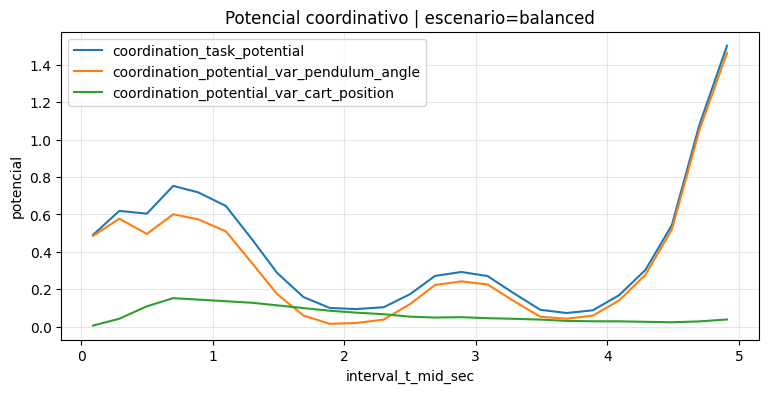

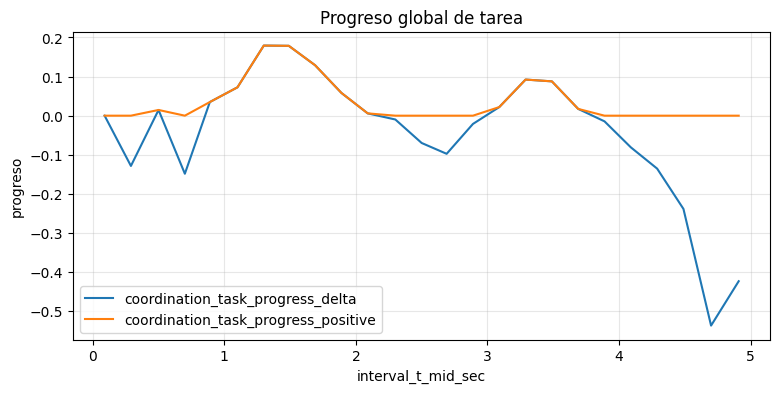

In [680]:
# ============================================================
# 6.4 Evolución temporal de potencial y progreso
# ============================================================

# Series disponibles:
#   "coordination_task_potential"
#   "coordination_task_progress_delta"
#   "coordination_task_progress_positive"
#   "coordination_potential_feature_L_e"
#   "coordination_potential_feature_L_edot"
#   "coordination_potential_feature_L_I"
#   "coordination_potential_feature_L_u"
#   "coordination_potential_var_pendulum_angle"
#   "coordination_potential_var_cart_position"

selected_potential_series_keys = [
    "coordination_task_potential",
    "coordination_potential_var_pendulum_angle",
    "coordination_potential_var_cart_position",
]

plt.figure(figsize=(9, 4))

for series_key in selected_potential_series_keys:
    plt.plot(
        coordination_potential_df["interval_t_mid_sec"],
        coordination_potential_df[series_key],
        label=series_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("potencial")
plt.title(f"Potencial coordinativo | escenario={active_potential_weight_scenario}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(9, 4))

plt.plot(
    coordination_potential_df["interval_t_mid_sec"],
    coordination_potential_df["coordination_task_progress_delta"],
    label="coordination_task_progress_delta",
)

plt.plot(
    coordination_potential_df["interval_t_mid_sec"],
    coordination_potential_df["coordination_task_progress_positive"],
    label="coordination_task_progress_positive",
)

plt.xlabel("interval_t_mid_sec")
plt.ylabel("progreso")
plt.title("Progreso global de tarea")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6.5 Comparar progreso positivo vs progreso firmado

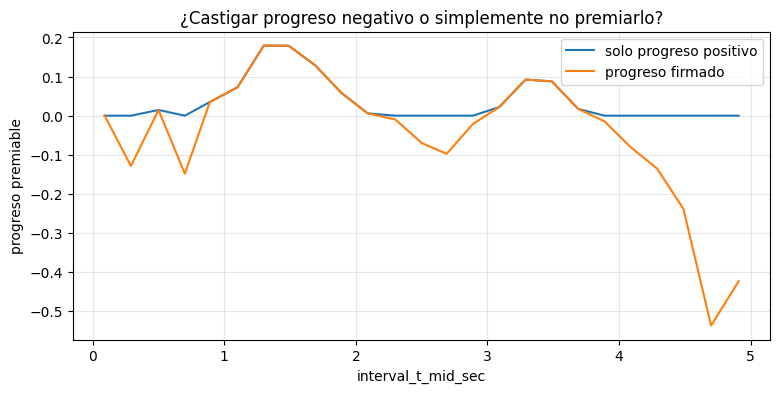

In [681]:
# ============================================================
# 6.5 Comparar progreso positivo vs progreso firmado
# ============================================================

coordination_potential_positive_df = compute_coordination_potential_table(
    interval_feature_df=interval_feature_df,
    var_objs=var_objs,
    potential_features=coordination_potential_features,
    potential_weights=coordination_potential_weights,
    progress_positive_only=True,
    progress_clip_max=progress_clip_max,
)

coordination_potential_signed_df = compute_coordination_potential_table(
    interval_feature_df=interval_feature_df,
    var_objs=var_objs,
    potential_features=coordination_potential_features,
    potential_weights=coordination_potential_weights,
    progress_positive_only=False,
    progress_clip_max=progress_clip_max,
)

plt.figure(figsize=(9, 4))

plt.plot(
    coordination_potential_positive_df["interval_t_mid_sec"],
    coordination_potential_positive_df["coordination_task_progress_positive"],
    label="solo progreso positivo",
)

plt.plot(
    coordination_potential_signed_df["interval_t_mid_sec"],
    coordination_potential_signed_df["coordination_task_progress_positive"],
    label="progreso firmado",
)

plt.xlabel("interval_t_mid_sec")
plt.ylabel("progreso premiable")
plt.title("¿Castigar progreso negativo o simplemente no premiarlo?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6.6 Scatter del potencial sobre el espacio de features

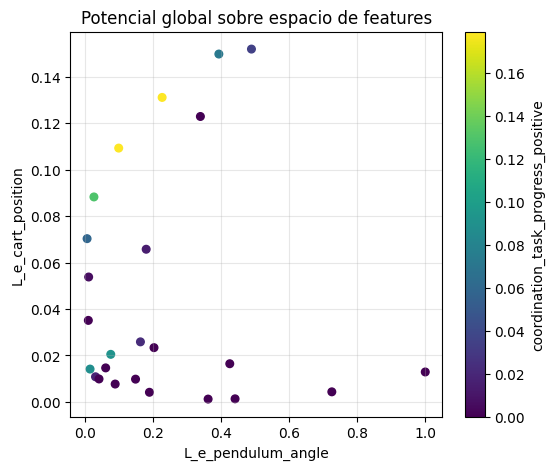

In [683]:
# ============================================================
# 6.6 Scatter del potencial sobre el espacio de features
# ============================================================

# Opciones para x_potential_feature_key:
#   "L_e_pendulum_angle"
#   "L_edot_pendulum_angle"
#   "L_I_pendulum_angle"
#   "L_u_pendulum_angle"
#   "L_e_cart_position"
#   "L_edot_cart_position"
#   "L_I_cart_position"
#   "L_u_cart_position"

x_potential_feature_key = "L_e_pendulum_angle"

# Opciones para y_potential_feature_key:
#   "L_e_pendulum_angle"
#   "L_edot_pendulum_angle"
#   "L_I_pendulum_angle"
#   "L_u_pendulum_angle"
#   "L_e_cart_position"
#   "L_edot_cart_position"
#   "L_I_cart_position"
#   "L_u_cart_position"

y_potential_feature_key = "L_e_cart_position"

# Opciones para color_key:
#   "coordination_task_potential"
#   "coordination_task_progress_delta"
#   "coordination_task_progress_positive"
#   "coordination_potential_var_pendulum_angle"
#   "coordination_potential_var_cart_position"

color_key = "coordination_task_progress_positive"

potential_scatter_df = interval_feature_df[
    [
        "interval_id",
        x_potential_feature_key,
        y_potential_feature_key,
    ]
].merge(
    coordination_potential_df[
        [
            "interval_id",
            color_key,
        ]
    ],
    on="interval_id",
)

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    potential_scatter_df[x_potential_feature_key],
    potential_scatter_df[y_potential_feature_key],
    c=potential_scatter_df[color_key],
    s=30,
)

plt.colorbar(scatter, label=color_key)
plt.xlabel(x_potential_feature_key)
plt.ylabel(y_potential_feature_key)
plt.title("Potencial global sobre espacio de features")
plt.grid(True, alpha=0.3)
plt.show()

## 6.7 — Distribución continua de potencial o progreso

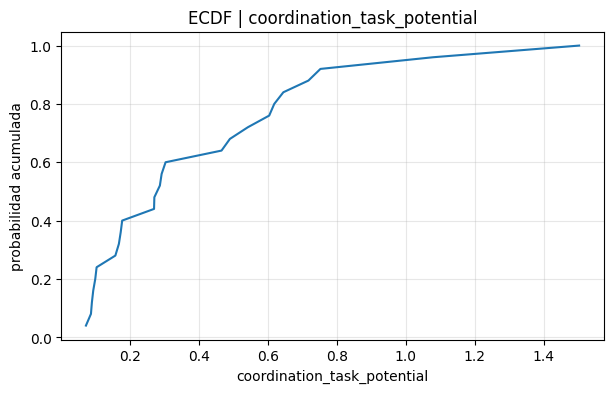

In [684]:
# ============================================================
# 6.7 Distribución continua de potencial o progreso
# ============================================================

# Opciones para distribution_potential_key:
#   "coordination_task_potential"
#   "coordination_task_progress_delta"
#   "coordination_task_progress_positive"
#   "coordination_potential_feature_L_e"
#   "coordination_potential_feature_L_edot"
#   "coordination_potential_feature_L_I"
#   "coordination_potential_feature_L_u"
#   "coordination_potential_var_pendulum_angle"
#   "coordination_potential_var_cart_position"

distribution_potential_key = "coordination_task_potential"

values = np.sort(coordination_potential_df[distribution_potential_key].to_numpy(dtype=float))
probability = np.arange(1, len(values) + 1) / len(values)

plt.figure(figsize=(7, 4))
plt.plot(values, probability)
plt.xlabel(distribution_potential_key)
plt.ylabel("probabilidad acumulada")
plt.title(f"ECDF | {distribution_potential_key}")
plt.grid(True, alpha=0.3)
plt.show()

## 6.8 Comparación entre escenarios de pesos del potencial

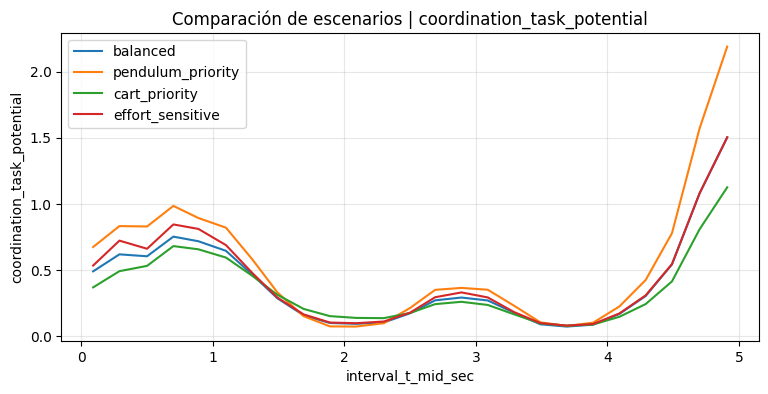

In [685]:
# ============================================================
# 6.8 Comparación entre escenarios de pesos del potencial
# ============================================================

# Opciones para scenario_comparison_series_key:
#   "coordination_task_potential"
#   "coordination_task_progress_delta"
#   "coordination_task_progress_positive"

scenario_comparison_series_key = "coordination_task_potential"

potential_scenario_tables = {}

for scenario_name, scenario_weights in potential_weight_scenarios.items():
    potential_scenario_tables[scenario_name] = compute_coordination_potential_table(
        interval_feature_df=interval_feature_df,
        var_objs=var_objs,
        potential_features=coordination_potential_features,
        potential_weights=scenario_weights,
        progress_positive_only=progress_positive_only,
        progress_clip_max=progress_clip_max,
    )

plt.figure(figsize=(9, 4))

for scenario_name, scenario_df in potential_scenario_tables.items():
    plt.plot(
        scenario_df["interval_t_mid_sec"],
        scenario_df[scenario_comparison_series_key],
        label=scenario_name,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel(scenario_comparison_series_key)
plt.title(f"Comparación de escenarios | {scenario_comparison_series_key}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6.9 Dashboard interactivo del potencial coordinativo

In [686]:
# ============================================================
# 6.9 Dashboard interactivo del potencial coordinativo
# ============================================================

last_interactive_coordination_potential_df = coordination_potential_df.copy()

def interactive_coordination_potential_preview(
    w_e_pendulum=1.00,
    w_edot_pendulum=0.45,
    w_I_pendulum=0.18,
    w_u_pendulum=0.08,
    w_e_cart=0.70,
    w_edot_cart=0.30,
    w_I_cart=0.22,
    w_u_cart=0.06,
    local_progress_positive_only=True,
    local_progress_clip_max=0.20,
):
    """
    Vista interactiva del potencial global y su progreso.
    """
    global last_interactive_coordination_potential_df

    local_potential_weights = {
        "L_e": {
            "pendulum_angle": w_e_pendulum,
            "cart_position": w_e_cart,
        },
        "L_edot": {
            "pendulum_angle": w_edot_pendulum,
            "cart_position": w_edot_cart,
        },
        "L_I": {
            "pendulum_angle": w_I_pendulum,
            "cart_position": w_I_cart,
        },
        "L_u": {
            "pendulum_angle": w_u_pendulum,
            "cart_position": w_u_cart,
        },
    }

    local_potential_df = compute_coordination_potential_table(
        interval_feature_df=interval_feature_df,
        var_objs=var_objs,
        potential_features=coordination_potential_features,
        potential_weights=local_potential_weights,
        progress_positive_only=local_progress_positive_only,
        progress_clip_max=local_progress_clip_max,
    )

    last_interactive_coordination_potential_df = local_potential_df.copy()

    plt.figure(figsize=(9, 4))
    plt.plot(
        local_potential_df["interval_t_mid_sec"],
        local_potential_df["coordination_task_potential"],
        label="coordination_task_potential",
    )
    plt.plot(
        local_potential_df["interval_t_mid_sec"],
        local_potential_df["coordination_potential_var_pendulum_angle"],
        label="coordination_potential_var_pendulum_angle",
    )
    plt.plot(
        local_potential_df["interval_t_mid_sec"],
        local_potential_df["coordination_potential_var_cart_position"],
        label="coordination_potential_var_cart_position",
    )
    plt.xlabel("interval_t_mid_sec")
    plt.ylabel("potencial")
    plt.title("Potencial coordinativo interactivo")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(
        local_potential_df["interval_t_mid_sec"],
        local_potential_df["coordination_task_progress_delta"],
        label="coordination_task_progress_delta",
    )
    plt.plot(
        local_potential_df["interval_t_mid_sec"],
        local_potential_df["coordination_task_progress_positive"],
        label="coordination_task_progress_positive",
    )
    plt.xlabel("interval_t_mid_sec")
    plt.ylabel("progreso")
    plt.title("Progreso coordinativo interactivo")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        interval_feature_df["L_e_pendulum_angle"],
        interval_feature_df["L_e_cart_position"],
        c=local_potential_df["coordination_task_potential"],
        s=30,
    )
    plt.colorbar(scatter, label="coordination_task_potential")
    plt.xlabel("L_e_pendulum_angle")
    plt.ylabel("L_e_cart_position")
    plt.title("Potencial sobre errores normalizados")
    plt.grid(True, alpha=0.3)
    plt.show()


widgets.interact(
    interactive_coordination_potential_preview,
    w_e_pendulum=widgets.FloatSlider(value=1.00, min=0.0, max=3.0, step=0.05),
    w_edot_pendulum=widgets.FloatSlider(value=0.45, min=0.0, max=3.0, step=0.05),
    w_I_pendulum=widgets.FloatSlider(value=0.18, min=0.0, max=3.0, step=0.05),
    w_u_pendulum=widgets.FloatSlider(value=0.08, min=0.0, max=3.0, step=0.01),
    w_e_cart=widgets.FloatSlider(value=0.70, min=0.0, max=3.0, step=0.05),
    w_edot_cart=widgets.FloatSlider(value=0.30, min=0.0, max=3.0, step=0.05),
    w_I_cart=widgets.FloatSlider(value=0.22, min=0.0, max=3.0, step=0.05),
    w_u_cart=widgets.FloatSlider(value=0.06, min=0.0, max=3.0, step=0.01),
    local_progress_positive_only=widgets.Checkbox(value=True),
    local_progress_clip_max=widgets.FloatSlider(value=0.20, min=0.01, max=1.0, step=0.01),
)

interactive(children=(FloatSlider(value=1.0, description='w_e_pendulum', max=3.0, step=0.05), FloatSlider(valu…

<function __main__.interactive_coordination_potential_preview(w_e_pendulum=1.0, w_edot_pendulum=0.45, w_I_pendulum=0.18, w_u_pendulum=0.08, w_e_cart=0.7, w_edot_cart=0.3, w_I_cart=0.22, w_u_cart=0.06, local_progress_positive_only=True, local_progress_clip_max=0.2)>

## 6.10 Persistencia mínima de la sección

In [687]:
# ============================================================
# 6.10 Persistencia mínima de esta sección
# ============================================================

reward_design["coordination_potential_design"] = {
    "active_potential_weight_scenario": active_potential_weight_scenario,
    "coordination_potential_features": list(coordination_potential_features),
    "coordination_potential_weights": coordination_potential_weights,
    "potential_weight_scenarios": potential_weight_scenarios,
    "progress_positive_only": progress_positive_only,
    "progress_clip_max": progress_clip_max,
    "coordination_potential_config_df": coordination_potential_config_df.copy(),
    "coordination_potential_df": coordination_potential_df.copy(),
    "last_interactive_coordination_potential_df": last_interactive_coordination_potential_df.copy(),
}

print("Potencial coordinativo registrado en reward_design['coordination_potential_design'].")
print(f"Trayectoria activa: {active_trajectory_name}")
print(f"Escenario activo de pesos: {active_potential_weight_scenario}")

Potencial coordinativo registrado en reward_design['coordination_potential_design'].
Trayectoria activa: manual_u_total_reference
Escenario activo de pesos: balanced


# 7. Crédito correctivo y bonus coordinativo por lazo

Esta sección reparte el progreso global entre los lazos que actuaron en la dirección correcta.

La formulación buscada es:

> Premiar a los lazos que actuaron en la dirección correcta cuando el sistema completo mejoró.

El progreso global ya fue calculado en la sección anterior:

$$
\Delta \Phi(k)
$$

Ahora se calcula un crédito por lazo usando series crudas por step:

$$
credit_{raw,var} =
reduce \left(
    \max(0, correction\_sign_{var} \cdot error_{var}(t) \cdot effort_{var}(t))
\right)
$$

Luego se reparte el crédito:

$$
credit\_share_{var} =
\frac{credit_{raw,var}}
{\epsilon + \sum_j credit_{raw,j}}
$$

Y el bonus final queda:

$$
bonus_{var} =
global\_weight \cdot credit\_share_{var} \cdot progress\_rewardable
$$

No se usan extra rewards.
La llave `extra_conditional_coordination_bonus_<var_obj>` se conserva porque es el nombre plano usado por el handler coordinativo del proyecto.

## 7.1 Inputs locales de crédito y bonus coordinativo

In [688]:
# ============================================================
# 7.1 Inputs configurables de esta sección
# ============================================================

system_context = reward_design["system_context"]
trajectory_design = reward_design["trajectory_design"]
coordination_potential_design = reward_design["coordination_potential_design"]

var_objs = system_context["var_objs"]
decision_interval_sec = system_context["decision_interval_sec"]

trajectory_registry = trajectory_design["trajectory_registry"]
active_trajectory_name = trajectory_design["active_trajectory_name"]
trajectory_df = trajectory_registry[active_trajectory_name].copy()

coordination_potential_features = coordination_potential_design["coordination_potential_features"]
coordination_potential_weights = coordination_potential_design["coordination_potential_weights"]
coordination_potential_df = coordination_potential_design["coordination_potential_df"].copy()
progress_positive_only = coordination_potential_design["progress_positive_only"]
progress_clip_max = coordination_potential_design["progress_clip_max"]

# Modo conceptual del bloque coordinativo.
#
# Opciones sugeridas:
#   "progress_credit"

coordination_reward_mode = "progress_credit"

# Modo de asignación conceptual.
#
# Opciones sugeridas:
#   "by_credit"

coordination_assign_mode = "by_credit"

# Peso global del bonus coordinativo.
#
# Lectura:
#   valor bajo -> coordinación actúa como complemento suave
#   valor alto -> coordinación puede dominar sobre la recompensa principal

coordination_global_weight = 1.00

# Señales usadas para crédito correctivo.
#
# Plantillas disponibles:
#   "error_{var_obj}"
#   "u_eff_{var_obj}"
#   "control_action_{var_obj}"
#
# Recomendación:
#   contribution_error_signal = "error_{var_obj}"
#   contribution_effort_signal = "u_eff_{var_obj}"

contribution_error_signal = "error_{var_obj}"
contribution_effort_signal = "u_eff_{var_obj}"

# Signo correctivo por variable.
#
# Interpretación:
#   +1.0 -> error * effort positivo se interpreta como correctivo
#   -1.0 -> error * effort negativo se interpreta como correctivo
#
# Variables disponibles:
#   "pendulum_angle"
#   "cart_position"
#
# Con la convención error = setpoint - pv y fuerza positiva sobre el carro,
# pendulum_angle suele requerir signo -1.0 para reconocer esfuerzo correctivo
# cuando el ángulo positivo es empujado de vuelta hacia cero.

correction_signs = {
    "pendulum_angle": -1.0,
    "cart_position": 1.0,
}

# Reducción del crédito dentro de cada intervalo.
#
# Opciones:
#   "average" -> crédito medio por step
#   "sum"     -> crédito acumulado por intervalo

credit_reduction_mode = "average"

# Epsilon para evitar división exacta por cero al repartir crédito.

epsilon_credit = 1e-8

# Variables disponibles para inspección:
#   "pendulum_angle"
#   "cart_position"

selected_credit_var_obj = "pendulum_angle"

## 7.2 Helpers locales para series crudas, crédito y bonus

In [689]:
def build_coordination_step_signal_df(
    trajectory_df: pd.DataFrame,
    var_objs: Sequence[str],
    decision_interval_sec: float,
    contribution_error_signal: str,
    contribution_effort_signal: str,
    correction_signs: Dict[str, float],
) -> pd.DataFrame:
    """
    Construye una tabla larga por step y var_obj para estudiar crédito correctivo.
    """
    trace_with_interval_df = add_interval_id(
        trace_df=trajectory_df,
        decision_interval_sec=decision_interval_sec,
    )

    records = []

    for var_obj in var_objs:
        error_key = contribution_error_signal.format(var_obj=var_obj)
        effort_key = contribution_effort_signal.format(var_obj=var_obj)
        correction_sign = float(correction_signs[var_obj])

        for _, step_row in trace_with_interval_df.iterrows():
            error_value = float(step_row[error_key])
            effort_value = float(step_row[effort_key])
            corrective_raw = correction_sign * error_value * effort_value
            corrective_positive = max(0.0, corrective_raw)

            records.append(
                {
                    "interval_id": int(step_row["interval_id"]),
                    "t_sec": float(step_row["t_sec"]),
                    "var_obj": var_obj,
                    "coordination_error": error_value,
                    "coordination_effort": effort_value,
                    "coordination_correction_sign": correction_sign,
                    "coordination_corrective_raw": corrective_raw,
                    "coordination_corrective_positive": corrective_positive,
                }
            )

    return pd.DataFrame(records)


def compute_coordination_credit_table(
    coordination_step_signal_df: pd.DataFrame,
    var_objs: Sequence[str],
    epsilon_credit: float,
    credit_reduction_mode: str,
) -> pd.DataFrame:
    """
    Calcula crédito bruto y proporción de crédito por intervalo.
    """
    records = []

    interval_ids = sorted(coordination_step_signal_df["interval_id"].unique())

    for interval_id in interval_ids:
        interval_df = coordination_step_signal_df[
            coordination_step_signal_df["interval_id"] == interval_id
        ]

        record = {
            "interval_id": int(interval_id),
            "interval_t_start_sec": float(interval_df["t_sec"].min()),
            "interval_t_end_sec": float(interval_df["t_sec"].max()),
            "interval_t_mid_sec": float(0.5 * (interval_df["t_sec"].min() + interval_df["t_sec"].max())),
        }

        credit_raw_total = 0.0

        for var_obj in var_objs:
            var_df = interval_df[interval_df["var_obj"] == var_obj]
            corrective_positive = var_df["coordination_corrective_positive"].to_numpy(dtype=float)

            if credit_reduction_mode == "average":
                credit_raw = float(np.mean(corrective_positive))
            else:
                credit_raw = float(np.sum(corrective_positive))

            record[f"coordination_credit_raw_{var_obj}"] = credit_raw
            credit_raw_total += credit_raw

        denominator = epsilon_credit + credit_raw_total

        for var_obj in var_objs:
            credit_raw = record[f"coordination_credit_raw_{var_obj}"]
            record[f"coordination_credit_share_{var_obj}"] = credit_raw / denominator

        record["coordination_credit_raw_total"] = credit_raw_total

        records.append(record)

    return pd.DataFrame(records)


def compute_coordination_reward_table(
    coordination_potential_df: pd.DataFrame,
    coordination_credit_df: pd.DataFrame,
    var_objs: Sequence[str],
    global_weight: float,
) -> pd.DataFrame:
    """
    Calcula bonus coordinativo final por lazo.
    """
    reward_df = coordination_potential_df[
        [
            "interval_id",
            "interval_t_start_sec",
            "interval_t_end_sec",
            "interval_t_mid_sec",
            "coordination_task_potential",
            "coordination_task_progress_delta",
            "coordination_task_progress_positive",
        ]
    ].merge(
        coordination_credit_df[
            [
                "interval_id",
                "coordination_credit_raw_total",
                *[f"coordination_credit_raw_{var_obj}" for var_obj in var_objs],
                *[f"coordination_credit_share_{var_obj}" for var_obj in var_objs],
            ]
        ],
        on="interval_id",
    )

    coordination_reward_total_values = []

    for row_idx, reward_row in reward_df.iterrows():
        coordination_reward_total = 0.0
        progress_value = float(reward_row["coordination_task_progress_positive"])

        for var_obj in var_objs:
            credit_share = float(reward_row[f"coordination_credit_share_{var_obj}"])
            coordination_bonus = float(global_weight) * credit_share * progress_value

            reward_df.loc[row_idx, f"extra_conditional_coordination_bonus_{var_obj}"] = coordination_bonus
            reward_df.loc[row_idx, f"coordination_bonus_{var_obj}"] = coordination_bonus

            coordination_reward_total += coordination_bonus

        coordination_reward_total_values.append(coordination_reward_total)

    reward_df["coordination_reward_total"] = coordination_reward_total_values

    return reward_df

## 7.3 Calcular crédito y bonus coordinativo

In [690]:
# ============================================================
# 7.3 Calcular crédito y bonus coordinativo
# ============================================================

coordination_step_signal_df = build_coordination_step_signal_df(
    trajectory_df=trajectory_df,
    var_objs=var_objs,
    decision_interval_sec=decision_interval_sec,
    contribution_error_signal=contribution_error_signal,
    contribution_effort_signal=contribution_effort_signal,
    correction_signs=correction_signs,
)

coordination_credit_df = compute_coordination_credit_table(
    coordination_step_signal_df=coordination_step_signal_df,
    var_objs=var_objs,
    epsilon_credit=epsilon_credit,
    credit_reduction_mode=credit_reduction_mode,
)

coordination_reward_df = compute_coordination_reward_table(
    coordination_potential_df=coordination_potential_df,
    coordination_credit_df=coordination_credit_df,
    var_objs=var_objs,
    global_weight=coordination_global_weight,
)

coordination_view_columns = [
    "interval_id",
    "interval_t_mid_sec",
    "coordination_task_potential",
    "coordination_task_progress_delta",
    "coordination_task_progress_positive",
    "coordination_reward_total",
]

for var_obj in var_objs:
    coordination_view_columns.extend(
        [
            f"coordination_credit_raw_{var_obj}",
            f"coordination_credit_share_{var_obj}",
            f"extra_conditional_coordination_bonus_{var_obj}",
        ]
    )

display(coordination_reward_df[coordination_view_columns].head(10))

,interval_id,interval_t_mid_sec,coordination_task_potential,coordination_task_progress_delta,coordination_task_progress_positive,coordination_reward_total,coordination_credit_raw_pendulum_angle,coordination_credit_share_pendulum_angle,extra_conditional_coordination_bonus_pendulum_angle,coordination_credit_raw_cart_position,coordination_credit_share_cart_position,extra_conditional_coordination_bonus_cart_position
0,0,0.09,0.489777,0.000000,0.000000,0.000000,3.590454e-02,1.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.29,0.618346,-0.128569,0.000000,0.000000,8.213678e-02,1.000000,0.000000,0.000000,0.000000,0.000000
2,2,0.50,0.603729,0.014617,0.014617,0.014617,1.379678e-02,0.815914,0.011927,0.003113,0.184085,0.002691
3,3,0.70,0.752236,-0.148506,0.000000,0.000000,3.478070e-02,0.484045,0.000000,0.037074,0.515955,0.000000
4,4,0.89,0.717357,0.034878,0.034878,0.034878,5.367739e-02,0.561374,0.019580,0.041940,0.438626,0.015299
5,5,1.10,0.644780,0.072577,0.072577,0.072577,1.841758e-02,0.469096,0.034046,0.020844,0.530904,0.038532
6,6,1.30,0.465483,0.179297,0.179297,0.179296,2.343749e-03,0.294802,0.052857,0.005606,0.705197,0.126439
7,7,1.49,0.286787,0.178696,0.178696,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
8,8,1.69,0.157756,0.129032,0.129032,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
9,9,1.89,0.099518,0.058238,0.058238,0.058177,1.916367e-08,0.001991,0.000116,0.000010,0.996970,0.058061


## 7.4 Evolución temporal de crédito bruto

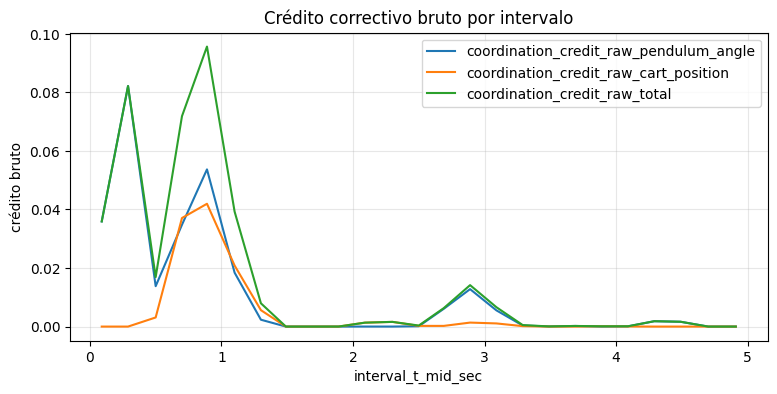

In [691]:
# ============================================================
# 7.4 Evolución temporal de crédito bruto
# ============================================================

# Series disponibles:
#   "coordination_credit_raw_pendulum_angle"
#   "coordination_credit_raw_cart_position"
#   "coordination_credit_raw_total"

selected_credit_raw_keys = [
    "coordination_credit_raw_pendulum_angle",
    "coordination_credit_raw_cart_position",
    "coordination_credit_raw_total",
]

plt.figure(figsize=(9, 4))

for credit_key in selected_credit_raw_keys:
    plt.plot(
        coordination_reward_df["interval_t_mid_sec"],
        coordination_reward_df[credit_key],
        label=credit_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("crédito bruto")
plt.title("Crédito correctivo bruto por intervalo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7.5 Evolución temporal de proporción de crédito

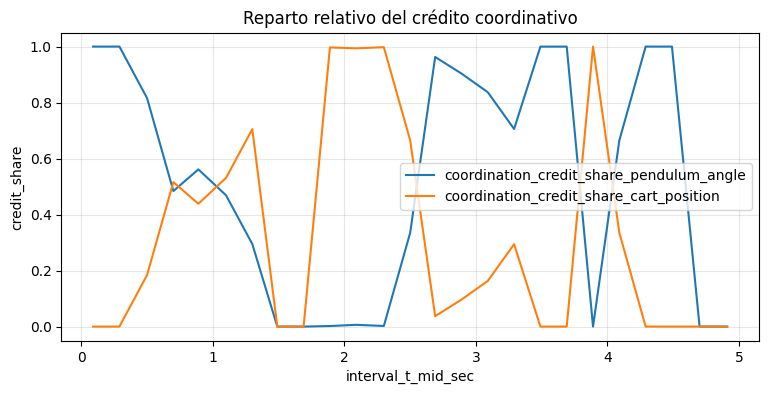

In [692]:
# ============================================================
# 7.5 Evolución temporal de proporción de crédito
# ============================================================

# Series disponibles:
#   "coordination_credit_share_pendulum_angle"
#   "coordination_credit_share_cart_position"

selected_credit_share_keys = [
    "coordination_credit_share_pendulum_angle",
    "coordination_credit_share_cart_position",
]

plt.figure(figsize=(9, 4))

for credit_key in selected_credit_share_keys:
    plt.plot(
        coordination_reward_df["interval_t_mid_sec"],
        coordination_reward_df[credit_key],
        label=credit_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("credit_share")
plt.title("Reparto relativo del crédito coordinativo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7.6 Scatter de contribución correctiva por step

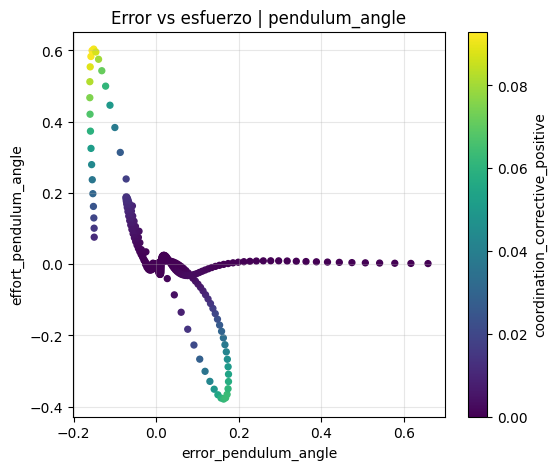

In [693]:
# ============================================================
# 7.6 Scatter de contribución correctiva por step
# ============================================================

# Opciones para selected_credit_var_obj:
#   "pendulum_angle"
#   "cart_position"

selected_credit_var_obj = "pendulum_angle"

selected_credit_step_df = coordination_step_signal_df[
    coordination_step_signal_df["var_obj"] == selected_credit_var_obj
]

# Opciones para color_key:
#   "t_sec"
#   "interval_id"
#   "coordination_corrective_raw"
#   "coordination_corrective_positive"

credit_scatter_color_key = "coordination_corrective_positive"

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    selected_credit_step_df["coordination_error"],
    selected_credit_step_df["coordination_effort"],
    c=selected_credit_step_df[credit_scatter_color_key],
    s=18,
)

plt.colorbar(scatter, label=credit_scatter_color_key)
plt.xlabel(f"error_{selected_credit_var_obj}")
plt.ylabel(f"effort_{selected_credit_var_obj}")
plt.title(f"Error vs esfuerzo | {selected_credit_var_obj}")
plt.grid(True, alpha=0.3)
plt.show()

## 7.7 — Evolución temporal del bonus coordinativo

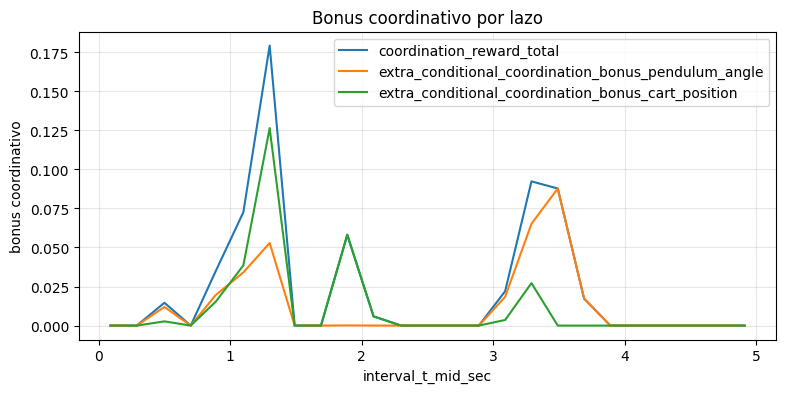

In [694]:
# ============================================================
# 7.7 Evolución temporal del bonus coordinativo
# ============================================================

# Series disponibles:
#   "coordination_reward_total"
#   "extra_conditional_coordination_bonus_pendulum_angle"
#   "extra_conditional_coordination_bonus_cart_position"
#   "coordination_bonus_pendulum_angle"
#   "coordination_bonus_cart_position"
#   "coordination_task_progress_positive"

selected_coordination_bonus_keys = [
    "coordination_reward_total",
    "extra_conditional_coordination_bonus_pendulum_angle",
    "extra_conditional_coordination_bonus_cart_position",
]

plt.figure(figsize=(9, 4))

for bonus_key in selected_coordination_bonus_keys:
    plt.plot(
        coordination_reward_df["interval_t_mid_sec"],
        coordination_reward_df[bonus_key],
        label=bonus_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("bonus coordinativo")
plt.title("Bonus coordinativo por lazo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7.8 Scatter: progreso global vs bonus coordinativo

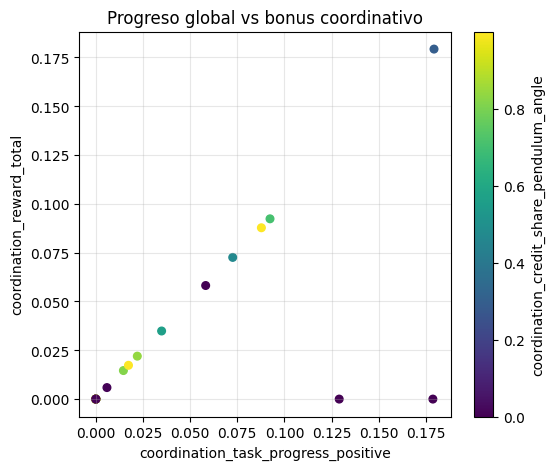

In [695]:
# ============================================================
# 7.8 Scatter: progreso global vs bonus coordinativo
# ============================================================

# Opciones para x_coordination_key:
#   "coordination_task_progress_delta"
#   "coordination_task_progress_positive"
#   "coordination_task_potential"

x_coordination_key = "coordination_task_progress_positive"

# Opciones para y_coordination_key:
#   "coordination_reward_total"
#   "extra_conditional_coordination_bonus_pendulum_angle"
#   "extra_conditional_coordination_bonus_cart_position"

y_coordination_key = "coordination_reward_total"

# Opciones para color_key:
#   "coordination_credit_share_pendulum_angle"
#   "coordination_credit_share_cart_position"
#   "coordination_credit_raw_total"
#   "interval_t_mid_sec"

coordination_color_key = "coordination_credit_share_pendulum_angle"

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    coordination_reward_df[x_coordination_key],
    coordination_reward_df[y_coordination_key],
    c=coordination_reward_df[coordination_color_key],
    s=30,
)

plt.colorbar(scatter, label=coordination_color_key)
plt.xlabel(x_coordination_key)
plt.ylabel(y_coordination_key)
plt.title("Progreso global vs bonus coordinativo")
plt.grid(True, alpha=0.3)
plt.show()

## 7.9 Distribución continua del crédito o bonus

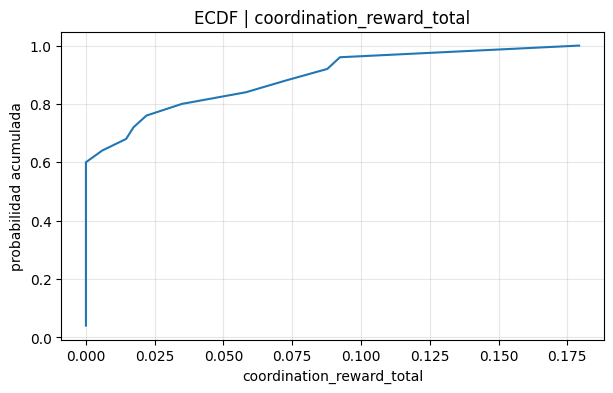

In [696]:
# ============================================================
# 7.9 Distribución continua del crédito o bonus
# ============================================================

# Opciones para distribution_coordination_key:
#   "coordination_reward_total"
#   "extra_conditional_coordination_bonus_pendulum_angle"
#   "extra_conditional_coordination_bonus_cart_position"
#   "coordination_credit_raw_pendulum_angle"
#   "coordination_credit_raw_cart_position"
#   "coordination_credit_share_pendulum_angle"
#   "coordination_credit_share_cart_position"
#   "coordination_task_progress_positive"

distribution_coordination_key = "coordination_reward_total"

values = np.sort(coordination_reward_df[distribution_coordination_key].to_numpy(dtype=float))
probability = np.arange(1, len(values) + 1) / len(values)

plt.figure(figsize=(7, 4))
plt.plot(values, probability)
plt.xlabel(distribution_coordination_key)
plt.ylabel("probabilidad acumulada")
plt.title(f"ECDF | {distribution_coordination_key}")
plt.grid(True, alpha=0.3)
plt.show()

## 7.10 Comparar reducción de crédito average vs sum

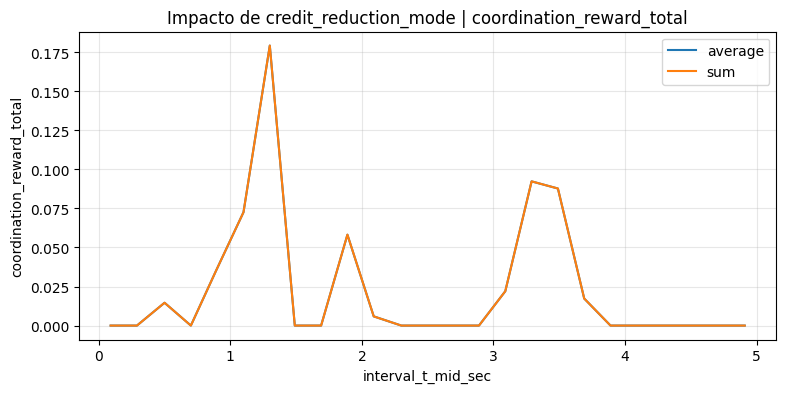

In [697]:
# ============================================================
# 7.10 Comparar reducción de crédito average vs sum
# ============================================================

credit_average_df = compute_coordination_credit_table(
    coordination_step_signal_df=coordination_step_signal_df,
    var_objs=var_objs,
    epsilon_credit=epsilon_credit,
    credit_reduction_mode="average",
)

reward_average_df = compute_coordination_reward_table(
    coordination_potential_df=coordination_potential_df,
    coordination_credit_df=credit_average_df,
    var_objs=var_objs,
    global_weight=coordination_global_weight,
)

credit_sum_df = compute_coordination_credit_table(
    coordination_step_signal_df=coordination_step_signal_df,
    var_objs=var_objs,
    epsilon_credit=epsilon_credit,
    credit_reduction_mode="sum",
)

reward_sum_df = compute_coordination_reward_table(
    coordination_potential_df=coordination_potential_df,
    coordination_credit_df=credit_sum_df,
    var_objs=var_objs,
    global_weight=coordination_global_weight,
)

# Opciones para comparison_coordination_key:
#   "coordination_reward_total"
#   "extra_conditional_coordination_bonus_pendulum_angle"
#   "extra_conditional_coordination_bonus_cart_position"
#   "coordination_credit_raw_pendulum_angle"
#   "coordination_credit_raw_cart_position"
#   "coordination_credit_share_pendulum_angle"
#   "coordination_credit_share_cart_position"

comparison_coordination_key = "coordination_reward_total"

plt.figure(figsize=(9, 4))

plt.plot(
    reward_average_df["interval_t_mid_sec"],
    reward_average_df[comparison_coordination_key],
    label="average",
)

plt.plot(
    reward_sum_df["interval_t_mid_sec"],
    reward_sum_df[comparison_coordination_key],
    label="sum",
)

plt.xlabel("interval_t_mid_sec")
plt.ylabel(comparison_coordination_key)
plt.title(f"Impacto de credit_reduction_mode | {comparison_coordination_key}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7.11 Sensibilidad continua de global_weight y progress_clip_max

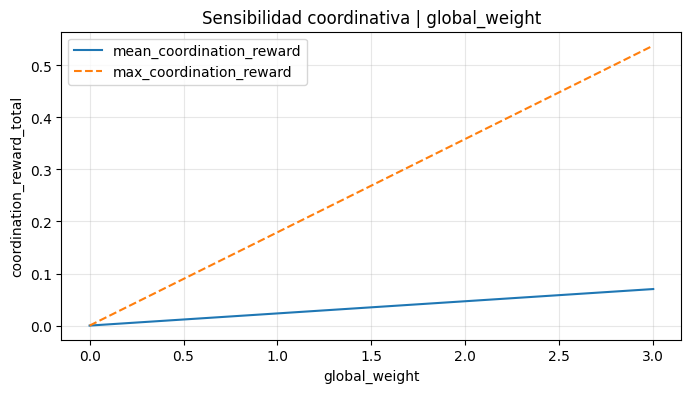

In [698]:
# ============================================================
# 7.11 Sensibilidad continua de global_weight y progress_clip_max
# ============================================================

# Variable que se moverá en el eje x.
#
# Opciones:
#   "global_weight"
#   "progress_clip_max"

coordination_sensitivity_axis = "global_weight"

coordination_global_weight_values = np.linspace(0.0, 3.0, 120)
coordination_progress_clip_values = np.linspace(0.01, 1.0, 120)

coordination_sensitivity_rows = []

if coordination_sensitivity_axis == "global_weight":
    for weight_value in coordination_global_weight_values:
        local_reward_df = compute_coordination_reward_table(
            coordination_potential_df=coordination_potential_df,
            coordination_credit_df=coordination_credit_df,
            var_objs=var_objs,
            global_weight=weight_value,
        )

        coordination_sensitivity_rows.append(
            {
                "param_value": weight_value,
                "mean_coordination_reward": float(local_reward_df["coordination_reward_total"].mean()),
                "max_coordination_reward": float(local_reward_df["coordination_reward_total"].max()),
            }
        )

else:
    for clip_value in coordination_progress_clip_values:
        local_potential_df = compute_coordination_potential_table(
            interval_feature_df=interval_feature_df,
            var_objs=var_objs,
            potential_features=coordination_potential_features,
            potential_weights=coordination_potential_weights,
            progress_positive_only=progress_positive_only,
            progress_clip_max=clip_value,
        )

        local_reward_df = compute_coordination_reward_table(
            coordination_potential_df=local_potential_df,
            coordination_credit_df=coordination_credit_df,
            var_objs=var_objs,
            global_weight=coordination_global_weight,
        )

        coordination_sensitivity_rows.append(
            {
                "param_value": clip_value,
                "mean_coordination_reward": float(local_reward_df["coordination_reward_total"].mean()),
                "max_coordination_reward": float(local_reward_df["coordination_reward_total"].max()),
            }
        )

coordination_sensitivity_df = pd.DataFrame(coordination_sensitivity_rows)

plt.figure(figsize=(8, 4))

plt.plot(
    coordination_sensitivity_df["param_value"],
    coordination_sensitivity_df["mean_coordination_reward"],
    label="mean_coordination_reward",
)

plt.plot(
    coordination_sensitivity_df["param_value"],
    coordination_sensitivity_df["max_coordination_reward"],
    linestyle="--",
    label="max_coordination_reward",
)

plt.xlabel(coordination_sensitivity_axis)
plt.ylabel("coordination_reward_total")
plt.title(f"Sensibilidad coordinativa | {coordination_sensitivity_axis}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7.12 Dashboard interactivo de crédito y bonus coordinativo

In [699]:
# ============================================================
# 7.12 Dashboard interactivo de crédito y bonus coordinativo
# ============================================================

last_interactive_coordination_credit_df = coordination_credit_df.copy()
last_interactive_coordination_reward_df = coordination_reward_df.copy()
last_interactive_coordination_step_signal_df = coordination_step_signal_df.copy()

def interactive_coordination_reward_preview(
    global_weight=1.00,
    progress_clip=0.20,
    positive_only=True,
    pendulum_correction_sign=-1.0,
    cart_correction_sign=1.0,
    epsilon_log10=-8.0,
    reduction_mode="average",
):
    """
    Vista interactiva del crédito correctivo y bonus coordinativo.
    """
    global last_interactive_coordination_credit_df
    global last_interactive_coordination_reward_df
    global last_interactive_coordination_step_signal_df

    local_correction_signs = {
        "pendulum_angle": pendulum_correction_sign,
        "cart_position": cart_correction_sign,
    }

    local_potential_df = compute_coordination_potential_table(
        interval_feature_df=interval_feature_df,
        var_objs=var_objs,
        potential_features=coordination_potential_features,
        potential_weights=coordination_potential_weights,
        progress_positive_only=positive_only,
        progress_clip_max=progress_clip,
    )

    local_step_signal_df = build_coordination_step_signal_df(
        trajectory_df=trajectory_df,
        var_objs=var_objs,
        decision_interval_sec=decision_interval_sec,
        contribution_error_signal=contribution_error_signal,
        contribution_effort_signal=contribution_effort_signal,
        correction_signs=local_correction_signs,
    )

    local_credit_df = compute_coordination_credit_table(
        coordination_step_signal_df=local_step_signal_df,
        var_objs=var_objs,
        epsilon_credit=10.0 ** epsilon_log10,
        credit_reduction_mode=reduction_mode,
    )

    local_reward_df = compute_coordination_reward_table(
        coordination_potential_df=local_potential_df,
        coordination_credit_df=local_credit_df,
        var_objs=var_objs,
        global_weight=global_weight,
    )

    last_interactive_coordination_credit_df = local_credit_df.copy()
    last_interactive_coordination_reward_df = local_reward_df.copy()
    last_interactive_coordination_step_signal_df = local_step_signal_df.copy()

    plt.figure(figsize=(9, 4))
    plt.plot(
        local_reward_df["interval_t_mid_sec"],
        local_reward_df["coordination_task_progress_positive"],
        label="coordination_task_progress_positive",
    )
    plt.plot(
        local_reward_df["interval_t_mid_sec"],
        local_reward_df["coordination_reward_total"],
        label="coordination_reward_total",
    )
    plt.xlabel("interval_t_mid_sec")
    plt.ylabel("valor")
    plt.title("Progreso y bonus coordinativo")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(
        local_reward_df["interval_t_mid_sec"],
        local_reward_df["coordination_credit_share_pendulum_angle"],
        label="coordination_credit_share_pendulum_angle",
    )
    plt.plot(
        local_reward_df["interval_t_mid_sec"],
        local_reward_df["coordination_credit_share_cart_position"],
        label="coordination_credit_share_cart_position",
    )
    plt.xlabel("interval_t_mid_sec")
    plt.ylabel("credit_share")
    plt.title("Reparto interactivo de crédito")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(
        local_reward_df["interval_t_mid_sec"],
        local_reward_df["extra_conditional_coordination_bonus_pendulum_angle"],
        label="bonus_pendulum_angle",
    )
    plt.plot(
        local_reward_df["interval_t_mid_sec"],
        local_reward_df["extra_conditional_coordination_bonus_cart_position"],
        label="bonus_cart_position",
    )
    plt.xlabel("interval_t_mid_sec")
    plt.ylabel("bonus")
    plt.title("Bonus coordinativo por lazo")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    selected_step_df = local_step_signal_df[
        local_step_signal_df["var_obj"] == selected_credit_var_obj
    ]

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        selected_step_df["coordination_error"],
        selected_step_df["coordination_effort"],
        c=selected_step_df["coordination_corrective_positive"],
        s=18,
    )
    plt.colorbar(scatter, label="coordination_corrective_positive")
    plt.xlabel(f"error_{selected_credit_var_obj}")
    plt.ylabel(f"effort_{selected_credit_var_obj}")
    plt.title(f"Crédito correctivo | {selected_credit_var_obj}")
    plt.grid(True, alpha=0.3)
    plt.show()


widgets.interact(
    interactive_coordination_reward_preview,
    global_weight=widgets.FloatSlider(value=1.00, min=0.0, max=5.0, step=0.05),
    progress_clip=widgets.FloatSlider(value=0.20, min=0.01, max=1.0, step=0.01),
    positive_only=widgets.Checkbox(value=True),
    pendulum_correction_sign=widgets.Dropdown(options=[-1.0, 1.0], value=-1.0),
    cart_correction_sign=widgets.Dropdown(options=[-1.0, 1.0], value=1.0),
    epsilon_log10=widgets.FloatSlider(value=-8.0, min=-12.0, max=-2.0, step=1.0),
    reduction_mode=widgets.Dropdown(options=["average", "sum"], value="average"),
)

interactive(children=(FloatSlider(value=1.0, description='global_weight', max=5.0, step=0.05), FloatSlider(val…

<function __main__.interactive_coordination_reward_preview(global_weight=1.0, progress_clip=0.2, positive_only=True, pendulum_correction_sign=-1.0, cart_correction_sign=1.0, epsilon_log10=-8.0, reduction_mode='average')>

## 7.13 Vista de configuración candidata del bloque coordinativo

In [700]:
# ============================================================
# 7.13 Vista de configuración candidata del bloque coordinativo
# ============================================================

coordination_reward_candidate_config = {
    "enabled": True,
    "module_path": "rewards.coordination_reward_handler",
    "class_name": "CoordinationRewardHandler",
    "reward_mode": coordination_reward_mode,
    "assign_mode": coordination_assign_mode,
    "global_weight": coordination_global_weight,
    "potential_features": list(coordination_potential_features),
    "potential_weights": coordination_potential_weights,
    "progress_positive_only": progress_positive_only,
    "progress_clip_max": progress_clip_max,
    "contribution_error_signal": contribution_error_signal,
    "contribution_effort_signal": contribution_effort_signal,
    "correction_signs": correction_signs,
    "epsilon_credit": epsilon_credit,
    "credit_reduction_mode": credit_reduction_mode,
}

display(
    pd.DataFrame(
        [
            {
                "parameter": key,
                "value": value,
            }
            for key, value in coordination_reward_candidate_config.items()
            if key not in ("potential_weights", "correction_signs")
        ]
    )
)

display(
    pd.DataFrame(
        [
            {
                "feature": feature_name,
                "var_obj": var_obj,
                "weight": coordination_potential_weights[feature_name][var_obj],
            }
            for feature_name in coordination_potential_features
            for var_obj in var_objs
        ]
    )
)

display(
    pd.DataFrame(
        [
            {
                "var_obj": var_obj,
                "correction_sign": correction_signs[var_obj],
            }
            for var_obj in var_objs
        ]
    )
)

,parameter,value
0,enabled,True
1,module_path,rewards.coordination_reward_handler
2,class_name,CoordinationRewardHandler
3,reward_mode,progress_credit
4,assign_mode,by_credit
5,global_weight,1.0
6,potential_features,"[L_e, L_edot, L_I, L_u]"
7,progress_positive_only,True
8,progress_clip_max,0.2
9,contribution_error_signal,error_{var_obj}


,feature,var_obj,weight
0,L_e,pendulum_angle,1.00
1,L_e,cart_position,0.70
2,L_edot,pendulum_angle,0.45
3,L_edot,cart_position,0.30
4,L_I,pendulum_angle,0.18
5,L_I,cart_position,0.22
6,L_u,pendulum_angle,0.08
7,L_u,cart_position,0.06


,var_obj,correction_sign
0,pendulum_angle,-1.0
1,cart_position,1.0


## 7.14 Persistencia mínima de la sección

In [701]:
# ============================================================
# 7.14 Persistencia mínima de esta sección
# ============================================================

reward_design["coordination_reward_design"] = {
    "coordination_reward_candidate_config": coordination_reward_candidate_config,
    "coordination_step_signal_df": coordination_step_signal_df.copy(),
    "coordination_credit_df": coordination_credit_df.copy(),
    "coordination_reward_df": coordination_reward_df.copy(),
    "coordination_global_weight": coordination_global_weight,
    "contribution_error_signal": contribution_error_signal,
    "contribution_effort_signal": contribution_effort_signal,
    "correction_signs": dict(correction_signs),
    "epsilon_credit": epsilon_credit,
    "credit_reduction_mode": credit_reduction_mode,
    "last_interactive_coordination_credit_df": last_interactive_coordination_credit_df.copy(),
    "last_interactive_coordination_reward_df": last_interactive_coordination_reward_df.copy(),
    "last_interactive_coordination_step_signal_df": last_interactive_coordination_step_signal_df.copy(),
}

print("Crédito y bonus coordinativo registrados en reward_design['coordination_reward_design'].")
print(f"Trayectoria activa: {active_trajectory_name}")
print(f"global_weight: {coordination_global_weight}")
print(f"credit_reduction_mode: {credit_reduction_mode}")

Crédito y bonus coordinativo registrados en reward_design['coordination_reward_design'].
Trayectoria activa: manual_u_total_reference
global_weight: 1.0
credit_reduction_mode: average


# 8. Composición total y validación visual

Esta sección integra las piezas diseñadas hasta ahora:

1. recompensa principal gaussiana;
2. compuertas de recompensa principal;
3. potencial global coordinativo;
4. crédito correctivo;
5. bonus coordinativo por lazo.

No se usan extra rewards.

La recompensa total del intervalo queda:

$$
global\_interval\_reward =
principal\_reward +
coordination\_reward\_total
$$

Por lazo, la señal conceptual queda:

$$
reward\_total\_{var} =
principal\_reward\_{var} +
extra\_conditional\_coordination\_bonus\_{var}
$$

La llave `extra_conditional_coordination_bonus_<var_obj>` conserva el nombre usado por el handler coordinativo del proyecto,
pero en este notebook no representa un extra reward externo: representa el bonus de coordinación.

La intención de esta sección es observar visualmente:

- cómo se compone la recompensa total;
- cuándo domina la recompensa principal;
- cuándo aparece el bonus coordinativo;
- qué lazo recibe crédito;
- cómo cambia la composición cuando se modifica la trayectoria física.

## 8.1 Inputs locales de composición total

In [702]:
# ============================================================
# 8.1 Inputs configurables de esta sección
# ============================================================

system_context = reward_design["system_context"]
trajectory_design = reward_design["trajectory_design"]
normalization_design = reward_design["normalization_design"]
interval_features = reward_design["interval_features"]
principal_reward_design = reward_design["principal_reward_design"]
coordination_potential_design = reward_design["coordination_potential_design"]
coordination_reward_design = reward_design["coordination_reward_design"]

var_objs = system_context["var_objs"]
state_vars = system_context["state_vars"]
setpoints_raw = system_context["setpoints_raw"]
error_definitions = system_context["error_definitions"]

physical_params = system_context["physical_params"]
actuator_params = system_context["actuator_params"]
state_ranges_params = system_context["state_ranges_params"]
state_output_limits = system_context["state_output_limits"]
state_normalization_enabled = system_context["state_normalization_enabled"]

dt_sec = system_context["dt_sec"]
decision_interval_sec = system_context["decision_interval_sec"]
preview_duration_sec = system_context["preview_duration_sec"]
u_total_limits = system_context["u_total_limits"]

trajectory_registry = trajectory_design["trajectory_registry"]
u_eff_weights = trajectory_design["u_eff_weights"]
active_trajectory_name = trajectory_design["active_trajectory_name"]
trajectory_df = trajectory_registry[active_trajectory_name].copy()

aggregation_config = normalization_design["aggregation_config"]
reward_component_output_limits = normalization_design["reward_component_output_limits"]

principal_reward_feature_config = principal_reward_design["principal_reward_feature_config"]
feature_gates = principal_reward_design["feature_gates"]

principal_reward_df = principal_reward_design["principal_reward_df"].copy()
gated_principal_reward_df = principal_reward_design["gated_principal_reward_df"].copy()

coordination_potential_features = coordination_potential_design["coordination_potential_features"]
coordination_potential_weights = coordination_potential_design["coordination_potential_weights"]
progress_positive_only = coordination_potential_design["progress_positive_only"]
progress_clip_max = coordination_potential_design["progress_clip_max"]

coordination_reward_candidate_config = coordination_reward_design["coordination_reward_candidate_config"]
coordination_global_weight = coordination_reward_candidate_config["global_weight"]
contribution_error_signal = coordination_reward_candidate_config["contribution_error_signal"]
contribution_effort_signal = coordination_reward_candidate_config["contribution_effort_signal"]
correction_signs = coordination_reward_candidate_config["correction_signs"]
epsilon_credit = coordination_reward_candidate_config["epsilon_credit"]
credit_reduction_mode = coordination_reward_candidate_config["credit_reduction_mode"]

coordination_reward_df = coordination_reward_design["coordination_reward_df"].copy()

# Switches de composición.
#
# Opciones:
#   True
#   False

principal_reward_enabled = True
coordination_reward_enabled = True

# Fuente de recompensa principal.
#
# Opciones:
#   True  -> usa recompensa principal con compuertas
#   False -> usa recompensa principal sin compuertas

use_gated_principal_reward = True

# Variables disponibles para inspección:
#   "pendulum_angle"
#   "cart_position"

selected_total_var_obj = "pendulum_angle"

KeyError: 'u_eff_weights'

## 8.2 Helpers locales de composición total

In [703]:
def compute_total_reward_table(
    principal_reward_df: pd.DataFrame,
    gated_principal_reward_df: pd.DataFrame,
    coordination_reward_df: pd.DataFrame,
    var_objs: Sequence[str],
    principal_enabled: bool,
    coordination_enabled: bool,
    use_gated_principal: bool,
) -> pd.DataFrame:
    """
    Compone recompensa total desde principal y coordinación.

    No incluye extra rewards.
    """
    principal_prefix = "gated_principal" if use_gated_principal else "principal"
    selected_principal_df = gated_principal_reward_df if use_gated_principal else principal_reward_df

    principal_factor = 1.0 if principal_enabled else 0.0
    coordination_factor = 1.0 if coordination_enabled else 0.0

    total_df = selected_principal_df[
        [
            "interval_id",
            "interval_t_start_sec",
            "interval_t_end_sec",
            "interval_t_mid_sec",
            f"{principal_prefix}_reward",
            *[f"{principal_prefix}_reward_{var_obj}" for var_obj in var_objs],
        ]
    ].copy()

    total_df["principal_reward_used"] = principal_factor * total_df[f"{principal_prefix}_reward"]

    coordination_index = coordination_reward_df.set_index("interval_id")

    total_df["coordination_reward_used"] = [
        coordination_factor * coordination_index.loc[interval_id, "coordination_reward_total"]
        for interval_id in total_df["interval_id"]
    ]

    total_df["coordination_task_potential"] = [
        coordination_index.loc[interval_id, "coordination_task_potential"]
        for interval_id in total_df["interval_id"]
    ]

    total_df["coordination_task_progress_delta"] = [
        coordination_index.loc[interval_id, "coordination_task_progress_delta"]
        for interval_id in total_df["interval_id"]
    ]

    total_df["coordination_task_progress_positive"] = [
        coordination_index.loc[interval_id, "coordination_task_progress_positive"]
        for interval_id in total_df["interval_id"]
    ]

    total_df["coordination_credit_raw_total"] = [
        coordination_index.loc[interval_id, "coordination_credit_raw_total"]
        for interval_id in total_df["interval_id"]
    ]

    for var_obj in var_objs:
        total_df[f"principal_reward_used_{var_obj}"] = (
            principal_factor * total_df[f"{principal_prefix}_reward_{var_obj}"]
        )

        total_df[f"coordination_reward_used_{var_obj}"] = [
            coordination_factor * coordination_index.loc[
                interval_id,
                f"extra_conditional_coordination_bonus_{var_obj}",
            ]
            for interval_id in total_df["interval_id"]
        ]

        total_df[f"coordination_credit_share_{var_obj}"] = [
            coordination_index.loc[interval_id, f"coordination_credit_share_{var_obj}"]
            for interval_id in total_df["interval_id"]
        ]

        total_df[f"reward_total_{var_obj}"] = (
            total_df[f"principal_reward_used_{var_obj}"]
            + total_df[f"coordination_reward_used_{var_obj}"]
        )

    total_df["global_interval_reward"] = (
        total_df["principal_reward_used"]
        + total_df["coordination_reward_used"]
    )

    return total_df


def build_step_reward_overlay_df(
    trajectory_df: pd.DataFrame,
    total_reward_df: pd.DataFrame,
    decision_interval_sec: float,
) -> pd.DataFrame:
    """
    Proyecta recompensas interval-level sobre registros step-level
    para colorear espacios físicos continuos.
    """
    step_df = add_interval_id(
        trace_df=trajectory_df,
        decision_interval_sec=decision_interval_sec,
    )

    reward_columns = [
        "interval_id",
        "global_interval_reward",
        "principal_reward_used",
        "coordination_reward_used",
        "coordination_task_progress_positive",
        "coordination_task_potential",
    ]

    return step_df.merge(
        total_reward_df[reward_columns],
        on="interval_id",
        how="left",
    )

## Código 8.3 Helper local para recalcular el diseño completo desde una trayectoria

In [704]:
def evaluate_total_reward_design(
    trajectory_df: pd.DataFrame,
    var_objs: Sequence[str],
    aggregation_config: Dict[str, Dict[str, Dict[str, object]]],
    reward_component_output_limits: Tuple[float, float],
    decision_interval_sec: float,
    principal_reward_feature_config: Dict[str, Dict[str, float]],
    feature_gates: Dict[str, Dict[str, object]],
    coordination_potential_features: Sequence[str],
    coordination_potential_weights: Dict[str, Dict[str, float]],
    progress_positive_only: bool,
    progress_clip_max: float,
    contribution_error_signal: str,
    contribution_effort_signal: str,
    correction_signs: Dict[str, float],
    epsilon_credit: float,
    credit_reduction_mode: str,
    coordination_global_weight: float,
    principal_enabled: bool,
    coordination_enabled: bool,
    use_gated_principal: bool,
) -> Dict[str, pd.DataFrame]:
    """
    Recalcula todo el pipeline de diseño para una trayectoria dada:

        trayectoria -> L_* -> principal -> gates -> coordinación -> total
    """
    local_interval_feature_df = compute_interval_feature_table(
        trace_df=trajectory_df,
        var_objs=var_objs,
        aggregation_config=aggregation_config,
        output_limits=reward_component_output_limits,
        decision_interval_sec=decision_interval_sec,
    )

    local_principal_reward_df = compute_principal_reward_table(
        interval_feature_df=local_interval_feature_df,
        var_objs=var_objs,
        feature_config=principal_reward_feature_config,
        gate_table_df=None,
        record_prefix="principal",
    )

    local_principal_gate_df = compute_principal_gate_table(
        interval_feature_df=local_interval_feature_df,
        var_objs=var_objs,
        feature_gates=feature_gates,
    )

    local_gated_principal_reward_df = compute_principal_reward_table(
        interval_feature_df=local_interval_feature_df,
        var_objs=var_objs,
        feature_config=principal_reward_feature_config,
        gate_table_df=local_principal_gate_df,
        record_prefix="gated_principal",
    )

    local_coordination_potential_df = compute_coordination_potential_table(
        interval_feature_df=local_interval_feature_df,
        var_objs=var_objs,
        potential_features=coordination_potential_features,
        potential_weights=coordination_potential_weights,
        progress_positive_only=progress_positive_only,
        progress_clip_max=progress_clip_max,
    )

    local_coordination_step_signal_df = build_coordination_step_signal_df(
        trajectory_df=trajectory_df,
        var_objs=var_objs,
        decision_interval_sec=decision_interval_sec,
        contribution_error_signal=contribution_error_signal,
        contribution_effort_signal=contribution_effort_signal,
        correction_signs=correction_signs,
    )

    local_coordination_credit_df = compute_coordination_credit_table(
        coordination_step_signal_df=local_coordination_step_signal_df,
        var_objs=var_objs,
        epsilon_credit=epsilon_credit,
        credit_reduction_mode=credit_reduction_mode,
    )

    local_coordination_reward_df = compute_coordination_reward_table(
        coordination_potential_df=local_coordination_potential_df,
        coordination_credit_df=local_coordination_credit_df,
        var_objs=var_objs,
        global_weight=coordination_global_weight,
    )

    local_total_reward_df = compute_total_reward_table(
        principal_reward_df=local_principal_reward_df,
        gated_principal_reward_df=local_gated_principal_reward_df,
        coordination_reward_df=local_coordination_reward_df,
        var_objs=var_objs,
        principal_enabled=principal_enabled,
        coordination_enabled=coordination_enabled,
        use_gated_principal=use_gated_principal,
    )

    local_reward_step_overlay_df = build_step_reward_overlay_df(
        trajectory_df=trajectory_df,
        total_reward_df=local_total_reward_df,
        decision_interval_sec=decision_interval_sec,
    )

    return {
        "interval_feature_df": local_interval_feature_df,
        "principal_reward_df": local_principal_reward_df,
        "principal_gate_df": local_principal_gate_df,
        "gated_principal_reward_df": local_gated_principal_reward_df,
        "coordination_potential_df": local_coordination_potential_df,
        "coordination_step_signal_df": local_coordination_step_signal_df,
        "coordination_credit_df": local_coordination_credit_df,
        "coordination_reward_df": local_coordination_reward_df,
        "total_reward_df": local_total_reward_df,
        "reward_step_overlay_df": local_reward_step_overlay_df,
    }

## 8.4 Calcular composición total base

In [ ]:
# ============================================================
# 8.4 Calcular composición total base
# ============================================================

total_reward_analysis = evaluate_total_reward_design(
    trajectory_df=trajectory_df,
    var_objs=var_objs,
    aggregation_config=aggregation_config,
    reward_component_output_limits=reward_component_output_limits,
    decision_interval_sec=decision_interval_sec,
    principal_reward_feature_config=principal_reward_feature_config,
    feature_gates=feature_gates,
    coordination_potential_features=coordination_potential_features,
    coordination_potential_weights=coordination_potential_weights,
    progress_positive_only=progress_positive_only,
    progress_clip_max=progress_clip_max,
    contribution_error_signal=contribution_error_signal,
    contribution_effort_signal=contribution_effort_signal,
    correction_signs=correction_signs,
    epsilon_credit=epsilon_credit,
    credit_reduction_mode=credit_reduction_mode,
    coordination_global_weight=coordination_global_weight,
    principal_enabled=principal_reward_enabled,
    coordination_enabled=coordination_reward_enabled,
    use_gated_principal=use_gated_principal_reward,
)

total_reward_df = total_reward_analysis["total_reward_df"].copy()
reward_step_overlay_df = total_reward_analysis["reward_step_overlay_df"].copy()

display(
    total_reward_df[
        [
            "interval_id",
            "interval_t_mid_sec",
            "principal_reward_used",
            "coordination_reward_used",
            "global_interval_reward",
            *[f"reward_total_{var_obj}" for var_obj in var_objs],
        ]
    ].head(10)
)

## 8.5 Evolución temporal de la composición total

In [ ]:
# ============================================================
# 8.5 Evolución temporal de la composición total
# ============================================================

# Series disponibles:
#   "global_interval_reward"
#   "principal_reward_used"
#   "coordination_reward_used"
#   "coordination_task_potential"
#   "coordination_task_progress_delta"
#   "coordination_task_progress_positive"
#   "coordination_credit_raw_total"
#   "reward_total_pendulum_angle"
#   "reward_total_cart_position"
#   "principal_reward_used_pendulum_angle"
#   "principal_reward_used_cart_position"
#   "coordination_reward_used_pendulum_angle"
#   "coordination_reward_used_cart_position"

selected_total_series_keys = [
    "global_interval_reward",
    "principal_reward_used",
    "coordination_reward_used",
]

plt.figure(figsize=(9, 4))

for series_key in selected_total_series_keys:
    plt.plot(
        total_reward_df["interval_t_mid_sec"],
        total_reward_df[series_key],
        label=series_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("recompensa")
plt.title(f"Composición total | trayectoria={active_trajectory_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8.6 Evolución temporal por lazo

In [ ]:
# ============================================================
# 8.6 Evolución temporal por lazo
# ============================================================

# Variables disponibles:
#   "pendulum_angle"
#   "cart_position"

selected_total_var_obj = "pendulum_angle"

# Series por lazo disponibles:
#   f"reward_total_{selected_total_var_obj}"
#   f"principal_reward_used_{selected_total_var_obj}"
#   f"coordination_reward_used_{selected_total_var_obj}"

selected_loop_series_keys = [
    f"reward_total_{selected_total_var_obj}",
    f"principal_reward_used_{selected_total_var_obj}",
    f"coordination_reward_used_{selected_total_var_obj}",
]

plt.figure(figsize=(9, 4))

for series_key in selected_loop_series_keys:
    plt.plot(
        total_reward_df["interval_t_mid_sec"],
        total_reward_df[series_key],
        label=series_key,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel("recompensa por lazo")
plt.title(f"Composición por lazo | {selected_total_var_obj}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8.7 Recompensa total sobre espacios físicos

In [705]:
# ============================================================
# 8.7 Recompensa total sobre espacios físicos
# ============================================================

# Opciones para reward_overlay_color_key:
#   "global_interval_reward"
#   "principal_reward_used"
#   "coordination_reward_used"
#   "coordination_task_progress_positive"
#   "coordination_task_potential"

reward_overlay_color_key = "global_interval_reward"

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    reward_step_overlay_df["pendulum_angle_raw"],
    reward_step_overlay_df["pendulum_velocity_raw"],
    c=reward_step_overlay_df[reward_overlay_color_key],
    s=18,
)

plt.colorbar(scatter, label=reward_overlay_color_key)
plt.xlabel("pendulum_angle_raw")
plt.ylabel("pendulum_velocity_raw")
plt.title("Ángulo vs velocidad angular coloreado por recompensa")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    reward_step_overlay_df["cart_position_raw"],
    reward_step_overlay_df["cart_velocity_raw"],
    c=reward_step_overlay_df[reward_overlay_color_key],
    s=18,
)

plt.colorbar(scatter, label=reward_overlay_color_key)
plt.xlabel("cart_position_raw")
plt.ylabel("cart_velocity_raw")
plt.title("Posición vs velocidad del carro coloreado por recompensa")
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'reward_step_overlay_df' is not defined

<Figure size 600x500 with 0 Axes>

## 8.8 Relación entre recompensa principal y coordinación

In [ ]:
# ============================================================
# 8.8 Relación entre recompensa principal y coordinación
# ============================================================

# Opciones para x_component_key:
#   "principal_reward_used"
#   "coordination_reward_used"
#   "coordination_task_progress_positive"
#   "coordination_task_potential"

x_component_key = "principal_reward_used"

# Opciones para y_component_key:
#   "coordination_reward_used"
#   "global_interval_reward"
#   "coordination_task_progress_positive"
#   "coordination_task_potential"

y_component_key = "coordination_reward_used"

# Opciones para component_color_key:
#   "global_interval_reward"
#   "coordination_task_progress_positive"
#   "coordination_credit_raw_total"
#   "interval_t_mid_sec"
#   "coordination_credit_share_pendulum_angle"
#   "coordination_credit_share_cart_position"

component_color_key = "coordination_task_progress_positive"

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    total_reward_df[x_component_key],
    total_reward_df[y_component_key],
    c=total_reward_df[component_color_key],
    s=32,
)

plt.colorbar(scatter, label=component_color_key)
plt.xlabel(x_component_key)
plt.ylabel(y_component_key)
plt.title("Relación principal vs coordinación")
plt.grid(True, alpha=0.3)
plt.show()

## 8.9 Distribución continua de recompensa total

In [ ]:
# ============================================================
# 8.9 Distribución continua de recompensa total
# ============================================================

# Opciones para distribution_total_reward_key:
#   "global_interval_reward"
#   "principal_reward_used"
#   "coordination_reward_used"
#   "reward_total_pendulum_angle"
#   "reward_total_cart_position"
#   "coordination_task_progress_positive"
#   "coordination_credit_raw_total"

distribution_total_reward_key = "global_interval_reward"

values = np.sort(total_reward_df[distribution_total_reward_key].to_numpy(dtype=float))
probability = np.arange(1, len(values) + 1) / len(values)

plt.figure(figsize=(7, 4))
plt.plot(values, probability)
plt.xlabel(distribution_total_reward_key)
plt.ylabel("probabilidad acumulada")
plt.title(f"ECDF | {distribution_total_reward_key}")
plt.grid(True, alpha=0.3)
plt.show()

## 8.10 Dashboard interactivo de trayectoria + composición total

In [ ]:
# ============================================================
# 8.10 Dashboard interactivo de trayectoria + composición total
# ============================================================

last_interactive_total_reward_analysis = total_reward_analysis
last_interactive_total_reward_df = total_reward_df.copy()
last_interactive_reward_step_overlay_df = reward_step_overlay_df.copy()

def interactive_total_reward_preview(
    initial_angle_deg=8.0,
    initial_cart_position=0.0,
    k_cart_position=1.0,
    k_cart_velocity=2.4,
    k_pendulum_angle=34.0,
    k_pendulum_velocity=7.8,
    soft_u_limit=0.25,
    open_loop_amplitude=0.0,
    open_loop_frequency_hz=0.5,
    open_loop_decay_rate=0.6,
    show_principal=True,
    show_coordination=True,
    use_gated=True,
):
    """
    Vista interactiva para observar cómo cambia la composición total
    al modificar la trayectoria física.
    """
    global last_interactive_total_reward_analysis
    global last_interactive_total_reward_df
    global last_interactive_reward_step_overlay_df

    local_t_sec = build_time_vector(
        duration_sec=preview_duration_sec,
        dt_sec=dt_sec,
    )

    local_initial_state = {
        "cart_position": initial_cart_position,
        "cart_velocity": 0.0,
        "pendulum_angle": np.deg2rad(initial_angle_deg),
        "pendulum_velocity": 0.0,
    }

    local_policy_params = {
        "k_cart_position": k_cart_position,
        "k_cart_velocity": k_cart_velocity,
        "k_pendulum_angle": k_pendulum_angle,
        "k_pendulum_velocity": k_pendulum_velocity,
        "bias_force": 0.0,
        "use_tanh": True,
        "soft_u_limit": soft_u_limit,
    }

    local_profile_params = {
        "amplitude": open_loop_amplitude,
        "frequency_hz": open_loop_frequency_hz,
        "decay_rate": open_loop_decay_rate,
        "start_time_sec": 0.0,
        "duration_sec": 1.0,
    }

    local_open_loop_u_total = build_open_loop_u_total(
        t_sec=local_t_sec,
        profile_name="damped_sine",
        profile_params=local_profile_params,
        manual_u_knots=[(0.0, 0.0), (preview_duration_sec, 0.0)],
        u_total_limits=u_total_limits,
        smoothing_window_samples=1,
    )

    local_trace_df = simulate_cartpole_from_policy(
        t_sec=local_t_sec,
        initial_state=local_initial_state,
        policy_params=local_policy_params,
        open_loop_u_total=local_open_loop_u_total,
        physical_params=physical_params,
        actuator_params=actuator_params,
        u_total_limits=u_total_limits,
    )

    local_trace_df = add_controller_like_signals(
        trace_df=local_trace_df,
        var_objs=var_objs,
        setpoints_raw=setpoints_raw,
        error_definitions=error_definitions,
        state_ranges_params=state_ranges_params,
        state_output_limits=state_output_limits,
        state_normalization_enabled=state_normalization_enabled,
        u_eff_weights=u_eff_weights,
    )

    local_analysis = evaluate_total_reward_design(
        trajectory_df=local_trace_df,
        var_objs=var_objs,
        aggregation_config=aggregation_config,
        reward_component_output_limits=reward_component_output_limits,
        decision_interval_sec=decision_interval_sec,
        principal_reward_feature_config=principal_reward_feature_config,
        feature_gates=feature_gates,
        coordination_potential_features=coordination_potential_features,
        coordination_potential_weights=coordination_potential_weights,
        progress_positive_only=progress_positive_only,
        progress_clip_max=progress_clip_max,
        contribution_error_signal=contribution_error_signal,
        contribution_effort_signal=contribution_effort_signal,
        correction_signs=correction_signs,
        epsilon_credit=epsilon_credit,
        credit_reduction_mode=credit_reduction_mode,
        coordination_global_weight=coordination_global_weight,
        principal_enabled=show_principal,
        coordination_enabled=show_coordination,
        use_gated_principal=use_gated,
    )

    local_total_df = local_analysis["total_reward_df"]
    local_overlay_df = local_analysis["reward_step_overlay_df"]

    last_interactive_total_reward_analysis = local_analysis
    last_interactive_total_reward_df = local_total_df.copy()
    last_interactive_reward_step_overlay_df = local_overlay_df.copy()

    plt.figure(figsize=(9, 4))
    plt.plot(local_trace_df["t_sec"], local_trace_df["pendulum_angle_raw"], label="pendulum_angle_raw")
    plt.plot(local_trace_df["t_sec"], local_trace_df["cart_position_raw"], label="cart_position_raw")
    plt.xlabel("t_sec")
    plt.ylabel("estado físico")
    plt.title("Trayectoria física interactiva")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        local_overlay_df["pendulum_angle_raw"],
        local_overlay_df["pendulum_velocity_raw"],
        c=local_overlay_df["global_interval_reward"],
        s=18,
    )
    plt.colorbar(scatter, label="global_interval_reward")
    plt.xlabel("pendulum_angle_raw")
    plt.ylabel("pendulum_velocity_raw")
    plt.title("Espacio de fase coloreado por recompensa total")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(
        local_total_df["interval_t_mid_sec"],
        local_total_df["global_interval_reward"],
        label="global_interval_reward",
    )
    plt.plot(
        local_total_df["interval_t_mid_sec"],
        local_total_df["principal_reward_used"],
        label="principal_reward_used",
    )
    plt.plot(
        local_total_df["interval_t_mid_sec"],
        local_total_df["coordination_reward_used"],
        label="coordination_reward_used",
    )
    plt.xlabel("interval_t_mid_sec")
    plt.ylabel("recompensa")
    plt.title("Composición total interactiva")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(
        local_total_df["principal_reward_used"],
        local_total_df["coordination_reward_used"],
        c=local_total_df["coordination_task_progress_positive"],
        s=32,
    )
    plt.colorbar(scatter, label="coordination_task_progress_positive")
    plt.xlabel("principal_reward_used")
    plt.ylabel("coordination_reward_used")
    plt.title("Principal vs coordinación")
    plt.grid(True, alpha=0.3)
    plt.show()


widgets.interact(
    interactive_total_reward_preview,
    initial_angle_deg=widgets.FloatSlider(value=8.0, min=-25.0, max=25.0, step=1.0),
    initial_cart_position=widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.05),
    k_cart_position=widgets.FloatSlider(value=1.0, min=-5.0, max=5.0, step=0.1),
    k_cart_velocity=widgets.FloatSlider(value=2.4, min=-8.0, max=8.0, step=0.1),
    k_pendulum_angle=widgets.FloatSlider(value=34.0, min=0.0, max=80.0, step=1.0),
    k_pendulum_velocity=widgets.FloatSlider(value=7.8, min=0.0, max=30.0, step=0.2),
    soft_u_limit=widgets.FloatSlider(value=0.25, min=0.02, max=1.0, step=0.01),
    open_loop_amplitude=widgets.FloatSlider(value=0.0, min=-0.2, max=0.2, step=0.01),
    open_loop_frequency_hz=widgets.FloatSlider(value=0.5, min=0.1, max=3.0, step=0.1),
    open_loop_decay_rate=widgets.FloatSlider(value=0.6, min=0.0, max=3.0, step=0.1),
    show_principal=widgets.Checkbox(value=True),
    show_coordination=widgets.Checkbox(value=True),
    use_gated=widgets.Checkbox(value=True),
)

## 8.11 Persistencia mínima de la sección

In [ ]:
# ============================================================
# 8.11 Persistencia mínima de esta sección
# ============================================================

reward_design["total_reward_design"] = {
    "principal_reward_enabled": principal_reward_enabled,
    "coordination_reward_enabled": coordination_reward_enabled,
    "use_gated_principal_reward": use_gated_principal_reward,
    "total_reward_df": total_reward_df.copy(),
    "reward_step_overlay_df": reward_step_overlay_df.copy(),
    "last_interactive_total_reward_df": last_interactive_total_reward_df.copy(),
    "last_interactive_reward_step_overlay_df": last_interactive_reward_step_overlay_df.copy(),
}

print("Composición total registrada en reward_design['total_reward_design'].")
print(f"Trayectoria activa: {active_trajectory_name}")
print(f"Principal activo: {principal_reward_enabled}")
print(f"Coordinación activa: {coordination_reward_enabled}")
print(f"Usando principal con compuertas: {use_gated_principal_reward}")

# 9. Análisis de sensibilidad

Esta sección estudia cómo cambia la recompensa total cuando se modifica una decisión de diseño.

La pregunta no es todavía cuál configuración entrena mejor.
La pregunta es más básica y visual:

> ¿La recompensa responde de forma coherente cuando alteramos una variable del diseño?

Se estudian sensibilidades sobre:

- rangos de normalización;
- pesos de recompensa principal;
- sensibilidad gaussiana;
- compuertas;
- activación/desactivación de bloques;
- peso global de coordinación;
- límite máximo de progreso coordinativo;
- pesos del potencial global;
- perturbaciones físicas de trayectoria.

Todos los gráficos son continuos:

- líneas para sensibilidad uno-a-uno;
- scatter coloreado para sensibilidad dos-a-dos;
- ECDF para distribución de resultados.

No se usan gráficos de barras.
No se usan extra rewards.

## 9.1 Inputs locales de sensibilidad

In [ ]:
# ============================================================
# 9.1 Inputs configurables de esta sección
# ============================================================

total_reward_design = reward_design["total_reward_design"]

base_trajectory_df = trajectory_df.copy()
base_aggregation_config = aggregation_config
base_principal_reward_feature_config = principal_reward_feature_config
base_feature_gates = feature_gates
base_coordination_potential_weights = coordination_potential_weights

base_principal_enabled = total_reward_design["principal_reward_enabled"]
base_coordination_enabled = total_reward_design["coordination_reward_enabled"]
base_use_gated_principal = total_reward_design["use_gated_principal_reward"]

base_coordination_global_weight = coordination_global_weight
base_progress_clip_max = progress_clip_max

# Variable objetivo para sensibilidad local.
#
# Opciones:
#   "pendulum_angle"
#   "cart_position"

sensitivity_var_obj = "pendulum_angle"

# Feature de recompensa principal.
#
# Opciones:
#   "L_e"
#   "L_edot"
#   "L_I"
#   "L_u"

sensitivity_feature_name = "L_e"

# Feature local de normalización.
#
# Opciones:
#   "e"
#   "edot"
#   "I"
#   "u"

sensitivity_local_feature_key = "e"

# Eje de sensibilidad uno-a-uno.
#
# Opciones:
#   "normalization_range_multiplier"
#   "principal_weight"
#   "principal_sigma"
#   "gate_strength"
#   "gate_min_factor"
#   "coordination_global_weight"
#   "coordination_progress_clip_max"
#   "coordination_potential_weight"
#   "principal_enabled_switch"
#   "coordination_enabled_switch"

sensitivity_axis = "principal_sigma"

# Métrica de lectura.
#
# Opciones:
#   "mean_global_interval_reward"
#   "sum_global_interval_reward"
#   "min_global_interval_reward"
#   "max_global_interval_reward"
#   "mean_principal_reward"
#   "mean_coordination_reward"
#   "mean_reward_total_pendulum_angle"
#   "mean_reward_total_cart_position"

sensitivity_metric_key = "mean_global_interval_reward"

sensitivity_param_values_by_axis = {
    "normalization_range_multiplier": np.linspace(0.50, 2.50, 100),
    "principal_weight": np.linspace(0.00, 3.00, 100),
    "principal_sigma": np.linspace(0.03, 1.00, 100),
    "gate_strength": np.linspace(0.03, 2.00, 100),
    "gate_min_factor": np.linspace(0.00, 1.00, 100),
    "coordination_global_weight": np.linspace(0.00, 5.00, 100),
    "coordination_progress_clip_max": np.linspace(0.01, 1.00, 100),
    "coordination_potential_weight": np.linspace(0.00, 3.00, 100),
    "principal_enabled_switch": np.array([0.0, 1.0]),
    "coordination_enabled_switch": np.array([0.0, 1.0]),
}

## 9.2 Helpers locales para mutar y evaluar diseño

In [706]:
import copy


def scale_single_normalization_range(
    aggregation_config: Dict[str, Dict[str, Dict[str, object]]],
    var_obj: str,
    local_feature_key: str,
    multiplier: float,
) -> Dict[str, Dict[str, Dict[str, object]]]:
    """
    Escala el rango de normalización de una sola feature.
    """
    local_config = copy.deepcopy(aggregation_config)

    range_min, range_max = local_config[var_obj][local_feature_key]["range"]
    local_config[var_obj][local_feature_key]["range"] = (
        float(range_min) * float(multiplier),
        float(range_max) * float(multiplier),
    )

    return local_config


def set_gate_override(
    feature_gates: Dict[str, Dict[str, object]],
    feature_name: str,
    var_obj: str,
    field_name: str,
    value,
) -> Dict[str, Dict[str, object]]:
    """
    Modifica una compuerta específica feature-var_obj.
    """
    local_gates = copy.deepcopy(feature_gates)

    local_gates[feature_name]["enabled"] = True

    per_var = dict(local_gates[feature_name].get("per_var", {}))
    local_override = dict(per_var.get(var_obj, {}))
    local_override[field_name] = value
    per_var[var_obj] = local_override

    local_gates[feature_name]["per_var"] = per_var

    return local_gates


def build_design_variant(
    mutations: Sequence[Tuple[str, float]],
) -> Dict[str, object]:
    """
    Construye una variante local del diseño aplicando una o más mutaciones.
    """
    local_aggregation_config = copy.deepcopy(base_aggregation_config)
    local_principal_config = copy.deepcopy(base_principal_reward_feature_config)
    local_feature_gates = copy.deepcopy(base_feature_gates)
    local_potential_weights = copy.deepcopy(base_coordination_potential_weights)

    local_principal_enabled = base_principal_enabled
    local_coordination_enabled = base_coordination_enabled
    local_use_gated_principal = base_use_gated_principal

    local_global_weight = base_coordination_global_weight
    local_progress_clip_max = base_progress_clip_max

    for axis_name, axis_value in mutations:
        if axis_name == "normalization_range_multiplier":
            local_aggregation_config = scale_single_normalization_range(
                aggregation_config=local_aggregation_config,
                var_obj=sensitivity_var_obj,
                local_feature_key=sensitivity_local_feature_key,
                multiplier=axis_value,
            )

        elif axis_name == "principal_weight":
            local_principal_config[sensitivity_feature_name]["weight"] = float(axis_value)

        elif axis_name == "principal_sigma":
            local_principal_config[sensitivity_feature_name]["sigma"] = float(axis_value)

        elif axis_name == "gate_strength":
            local_feature_gates = set_gate_override(
                feature_gates=local_feature_gates,
                feature_name=sensitivity_feature_name,
                var_obj=sensitivity_var_obj,
                field_name="strength",
                value=float(axis_value),
            )

        elif axis_name == "gate_min_factor":
            local_feature_gates = set_gate_override(
                feature_gates=local_feature_gates,
                feature_name=sensitivity_feature_name,
                var_obj=sensitivity_var_obj,
                field_name="min_factor",
                value=float(axis_value),
            )

        elif axis_name == "coordination_global_weight":
            local_global_weight = float(axis_value)

        elif axis_name == "coordination_progress_clip_max":
            local_progress_clip_max = float(axis_value)

        elif axis_name == "coordination_potential_weight":
            local_potential_weights[sensitivity_feature_name][sensitivity_var_obj] = float(axis_value)

        elif axis_name == "principal_enabled_switch":
            local_principal_enabled = bool(axis_value)

        elif axis_name == "coordination_enabled_switch":
            local_coordination_enabled = bool(axis_value)

    return {
        "aggregation_config": local_aggregation_config,
        "principal_reward_feature_config": local_principal_config,
        "feature_gates": local_feature_gates,
        "coordination_potential_weights": local_potential_weights,
        "principal_enabled": local_principal_enabled,
        "coordination_enabled": local_coordination_enabled,
        "use_gated_principal": local_use_gated_principal,
        "coordination_global_weight": local_global_weight,
        "progress_clip_max": local_progress_clip_max,
    }


def summarize_total_reward_result(
    total_reward_df: pd.DataFrame,
    var_objs: Sequence[str],
) -> Dict[str, float]:
    """
    Resume una evaluación de recompensa total.
    """
    summary = {
        "mean_global_interval_reward": float(total_reward_df["global_interval_reward"].mean()),
        "sum_global_interval_reward": float(total_reward_df["global_interval_reward"].sum()),
        "min_global_interval_reward": float(total_reward_df["global_interval_reward"].min()),
        "max_global_interval_reward": float(total_reward_df["global_interval_reward"].max()),
        "mean_principal_reward": float(total_reward_df["principal_reward_used"].mean()),
        "mean_coordination_reward": float(total_reward_df["coordination_reward_used"].mean()),
        "mean_progress_positive": float(total_reward_df["coordination_task_progress_positive"].mean()),
        "mean_task_potential": float(total_reward_df["coordination_task_potential"].mean()),
    }

    for var_obj in var_objs:
        summary[f"mean_reward_total_{var_obj}"] = float(total_reward_df[f"reward_total_{var_obj}"].mean())
        summary[f"mean_principal_reward_{var_obj}"] = float(total_reward_df[f"principal_reward_used_{var_obj}"].mean())
        summary[f"mean_coordination_reward_{var_obj}"] = float(total_reward_df[f"coordination_reward_used_{var_obj}"].mean())

    return summary


def evaluate_design_variant(
    mutations: Sequence[Tuple[str, float]],
    trajectory_df: pd.DataFrame = None,
) -> Dict[str, object]:
    """
    Evalúa una variante del diseño sobre una trayectoria.
    """
    if trajectory_df is None:
        trajectory_df = base_trajectory_df

    variant = build_design_variant(mutations)

    analysis = evaluate_total_reward_design(
        trajectory_df=trajectory_df,
        var_objs=var_objs,
        aggregation_config=variant["aggregation_config"],
        reward_component_output_limits=reward_component_output_limits,
        decision_interval_sec=decision_interval_sec,
        principal_reward_feature_config=variant["principal_reward_feature_config"],
        feature_gates=variant["feature_gates"],
        coordination_potential_features=coordination_potential_features,
        coordination_potential_weights=variant["coordination_potential_weights"],
        progress_positive_only=progress_positive_only,
        progress_clip_max=variant["progress_clip_max"],
        contribution_error_signal=contribution_error_signal,
        contribution_effort_signal=contribution_effort_signal,
        correction_signs=correction_signs,
        epsilon_credit=epsilon_credit,
        credit_reduction_mode=credit_reduction_mode,
        coordination_global_weight=variant["coordination_global_weight"],
        principal_enabled=variant["principal_enabled"],
        coordination_enabled=variant["coordination_enabled"],
        use_gated_principal=variant["use_gated_principal"],
    )

    summary = summarize_total_reward_result(
        total_reward_df=analysis["total_reward_df"],
        var_objs=var_objs,
    )

    return {
        "variant": variant,
        "analysis": analysis,
        "summary": summary,
    }

## 9.3 Sensibilidad uno-a-uno

In [ ]:
# ============================================================
# 9.3 Sensibilidad uno-a-uno
# ============================================================

param_values = sensitivity_param_values_by_axis[sensitivity_axis]

sensitivity_1d_rows = []

for param_value in param_values:
    result = evaluate_design_variant(
        mutations=[
            (sensitivity_axis, float(param_value)),
        ]
    )

    row = {
        "sensitivity_axis": sensitivity_axis,
        "param_value": float(param_value),
    }
    row.update(result["summary"])

    sensitivity_1d_rows.append(row)

sensitivity_1d_df = pd.DataFrame(sensitivity_1d_rows)

display(sensitivity_1d_df.head(10))

## 9.4 Curvas de sensibilidad uno-a-uno

In [ ]:
# ============================================================
# 9.4 Curvas de sensibilidad uno-a-uno
# ============================================================

# Series disponibles:
#   "mean_global_interval_reward"
#   "sum_global_interval_reward"
#   "min_global_interval_reward"
#   "max_global_interval_reward"
#   "mean_principal_reward"
#   "mean_coordination_reward"
#   "mean_progress_positive"
#   "mean_task_potential"
#   "mean_reward_total_pendulum_angle"
#   "mean_reward_total_cart_position"
#   "mean_principal_reward_pendulum_angle"
#   "mean_principal_reward_cart_position"
#   "mean_coordination_reward_pendulum_angle"
#   "mean_coordination_reward_cart_position"

selected_sensitivity_series_keys = [
    "mean_global_interval_reward",
    "mean_principal_reward",
    "mean_coordination_reward",
]

plt.figure(figsize=(9, 4))

for series_key in selected_sensitivity_series_keys:
    plt.plot(
        sensitivity_1d_df["param_value"],
        sensitivity_1d_df[series_key],
        label=series_key,
    )

plt.xlabel(sensitivity_axis)
plt.ylabel("métrica de recompensa")
plt.title(
    f"Sensibilidad 1D | {sensitivity_axis} | "
    f"{sensitivity_feature_name}_{sensitivity_var_obj}"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9.5 Distribución continua de resultados de sensibilidad

In [ ]:
# ============================================================
# 9.5 Distribución continua de resultados de sensibilidad
# ============================================================

# Opciones para sensitivity_distribution_key:
#   "mean_global_interval_reward"
#   "sum_global_interval_reward"
#   "mean_principal_reward"
#   "mean_coordination_reward"
#   "mean_reward_total_pendulum_angle"
#   "mean_reward_total_cart_position"

sensitivity_distribution_key = sensitivity_metric_key

values = np.sort(sensitivity_1d_df[sensitivity_distribution_key].to_numpy(dtype=float))
probability = np.arange(1, len(values) + 1) / len(values)

plt.figure(figsize=(7, 4))
plt.plot(values, probability)
plt.xlabel(sensitivity_distribution_key)
plt.ylabel("probabilidad acumulada")
plt.title(f"ECDF sensibilidad | {sensitivity_distribution_key}")
plt.grid(True, alpha=0.3)
plt.show()

## 9.6 Sensibilidad dos-a-dos como scatter continuo

In [ ]:
# ============================================================
# 9.6 Sensibilidad dos-a-dos como scatter continuo
# ============================================================

# Opciones para x_sensitivity_axis:
#   "normalization_range_multiplier"
#   "principal_weight"
#   "principal_sigma"
#   "gate_strength"
#   "gate_min_factor"
#   "coordination_global_weight"
#   "coordination_progress_clip_max"
#   "coordination_potential_weight"

x_sensitivity_axis = "principal_weight"

# Opciones para y_sensitivity_axis:
#   "normalization_range_multiplier"
#   "principal_weight"
#   "principal_sigma"
#   "gate_strength"
#   "gate_min_factor"
#   "coordination_global_weight"
#   "coordination_progress_clip_max"
#   "coordination_potential_weight"

y_sensitivity_axis = "principal_sigma"

# Métrica para colorear.
#
# Opciones:
#   "mean_global_interval_reward"
#   "sum_global_interval_reward"
#   "mean_principal_reward"
#   "mean_coordination_reward"
#   "mean_progress_positive"
#   "mean_reward_total_pendulum_angle"
#   "mean_reward_total_cart_position"

two_dim_color_metric = "mean_global_interval_reward"

x_values = np.linspace(
    sensitivity_param_values_by_axis[x_sensitivity_axis][0],
    sensitivity_param_values_by_axis[x_sensitivity_axis][-1],
    25,
)

y_values = np.linspace(
    sensitivity_param_values_by_axis[y_sensitivity_axis][0],
    sensitivity_param_values_by_axis[y_sensitivity_axis][-1],
    25,
)

sensitivity_2d_rows = []

for x_value in x_values:
    for y_value in y_values:
        result = evaluate_design_variant(
            mutations=[
                (x_sensitivity_axis, float(x_value)),
                (y_sensitivity_axis, float(y_value)),
            ]
        )

        row = {
            x_sensitivity_axis: float(x_value),
            y_sensitivity_axis: float(y_value),
        }
        row.update(result["summary"])

        sensitivity_2d_rows.append(row)

sensitivity_2d_df = pd.DataFrame(sensitivity_2d_rows)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    sensitivity_2d_df[x_sensitivity_axis],
    sensitivity_2d_df[y_sensitivity_axis],
    c=sensitivity_2d_df[two_dim_color_metric],
    s=34,
)

plt.colorbar(scatter, label=two_dim_color_metric)
plt.xlabel(x_sensitivity_axis)
plt.ylabel(y_sensitivity_axis)
plt.title(
    f"Sensibilidad 2D | {sensitivity_feature_name}_{sensitivity_var_obj}"
)
plt.grid(True, alpha=0.3)
plt.show()

## 9.7 Comparación de activación de bloques

In [ ]:
# ============================================================
# 9.7 Comparación de activación de bloques
# ============================================================

switch_scenarios = {
    "principal_plus_coordination": {
        "principal_enabled_switch": 1.0,
        "coordination_enabled_switch": 1.0,
    },
    "principal_only": {
        "principal_enabled_switch": 1.0,
        "coordination_enabled_switch": 0.0,
    },
    "coordination_only": {
        "principal_enabled_switch": 0.0,
        "coordination_enabled_switch": 1.0,
    },
}

switch_scenario_tables = {}

for scenario_name, scenario_switches in switch_scenarios.items():
    result = evaluate_design_variant(
        mutations=[
            ("principal_enabled_switch", scenario_switches["principal_enabled_switch"]),
            ("coordination_enabled_switch", scenario_switches["coordination_enabled_switch"]),
        ]
    )

    switch_scenario_tables[scenario_name] = result["analysis"]["total_reward_df"].copy()

# Opciones para switch_comparison_key:
#   "global_interval_reward"
#   "principal_reward_used"
#   "coordination_reward_used"
#   "reward_total_pendulum_angle"
#   "reward_total_cart_position"

switch_comparison_key = "global_interval_reward"

plt.figure(figsize=(9, 4))

for scenario_name, scenario_df in switch_scenario_tables.items():
    plt.plot(
        scenario_df["interval_t_mid_sec"],
        scenario_df[switch_comparison_key],
        label=scenario_name,
    )

plt.xlabel("interval_t_mid_sec")
plt.ylabel(switch_comparison_key)
plt.title(f"Activar/desactivar bloques | {switch_comparison_key}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9.8 Sensibilidad física de trayectoria

In [ ]:
# ============================================================
# 9.8 Sensibilidad física de trayectoria
# ============================================================

# Parámetro físico o de política a mover.
#
# Opciones:
#   "initial_angle_deg"
#   "initial_cart_position"
#   "k_cart_position"
#   "k_cart_velocity"
#   "k_pendulum_angle"
#   "k_pendulum_velocity"
#   "soft_u_limit"

physical_sensitivity_axis = "initial_angle_deg"

physical_sensitivity_values_by_axis = {
    "initial_angle_deg": np.linspace(-20.0, 20.0, 80),
    "initial_cart_position": np.linspace(-1.0, 1.0, 80),
    "k_cart_position": np.linspace(-5.0, 5.0, 80),
    "k_cart_velocity": np.linspace(-8.0, 8.0, 80),
    "k_pendulum_angle": np.linspace(0.0, 80.0, 80),
    "k_pendulum_velocity": np.linspace(0.0, 30.0, 80),
    "soft_u_limit": np.linspace(0.02, 1.0, 80),
}

physical_base_initial_state = {
    "cart_position": 0.0,
    "cart_velocity": 0.0,
    "pendulum_angle": np.deg2rad(8.0),
    "pendulum_velocity": 0.0,
}

physical_base_policy_params = {
    "k_cart_position": 1.0,
    "k_cart_velocity": 2.4,
    "k_pendulum_angle": 34.0,
    "k_pendulum_velocity": 7.8,
    "bias_force": 0.0,
    "use_tanh": True,
    "soft_u_limit": 0.25,
}

physical_sensitivity_t_sec = build_time_vector(
    duration_sec=preview_duration_sec,
    dt_sec=dt_sec,
)

physical_sensitivity_rows = []

for physical_value in physical_sensitivity_values_by_axis[physical_sensitivity_axis]:
    local_initial_state = dict(physical_base_initial_state)
    local_policy_params = dict(physical_base_policy_params)

    if physical_sensitivity_axis == "initial_angle_deg":
        local_initial_state["pendulum_angle"] = np.deg2rad(float(physical_value))

    elif physical_sensitivity_axis == "initial_cart_position":
        local_initial_state["cart_position"] = float(physical_value)

    else:
        local_policy_params[physical_sensitivity_axis] = float(physical_value)

    local_open_loop_u_total = np.zeros_like(physical_sensitivity_t_sec)

    local_trace_df = simulate_cartpole_from_policy(
        t_sec=physical_sensitivity_t_sec,
        initial_state=local_initial_state,
        policy_params=local_policy_params,
        open_loop_u_total=local_open_loop_u_total,
        physical_params=physical_params,
        actuator_params=actuator_params,
        u_total_limits=u_total_limits,
    )

    local_trace_df = add_controller_like_signals(
        trace_df=local_trace_df,
        var_objs=var_objs,
        setpoints_raw=setpoints_raw,
        error_definitions=error_definitions,
        state_ranges_params=state_ranges_params,
        state_output_limits=state_output_limits,
        state_normalization_enabled=state_normalization_enabled,
        u_eff_weights=u_eff_weights,
    )

    result = evaluate_design_variant(
        mutations=[],
        trajectory_df=local_trace_df,
    )

    row = {
        "physical_sensitivity_axis": physical_sensitivity_axis,
        "physical_value": float(physical_value),
    }
    row.update(result["summary"])

    physical_sensitivity_rows.append(row)

physical_sensitivity_df = pd.DataFrame(physical_sensitivity_rows)

# Series disponibles:
#   "mean_global_interval_reward"
#   "sum_global_interval_reward"
#   "mean_principal_reward"
#   "mean_coordination_reward"
#   "mean_progress_positive"
#   "mean_reward_total_pendulum_angle"
#   "mean_reward_total_cart_position"

selected_physical_sensitivity_series_keys = [
    "mean_global_interval_reward",
    "mean_principal_reward",
    "mean_coordination_reward",
]

plt.figure(figsize=(9, 4))

for series_key in selected_physical_sensitivity_series_keys:
    plt.plot(
        physical_sensitivity_df["physical_value"],
        physical_sensitivity_df[series_key],
        label=series_key,
    )

plt.xlabel(physical_sensitivity_axis)
plt.ylabel("métrica de recompensa")
plt.title(f"Sensibilidad física | {physical_sensitivity_axis}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9.9 Scatter de sensibilidad física

In [ ]:
# ============================================================
# 9.9 Scatter de sensibilidad física
# ============================================================

# Opciones para physical_x_key:
#   "physical_value"
#   "mean_principal_reward"
#   "mean_coordination_reward"
#   "mean_progress_positive"
#   "mean_task_potential"
#   "mean_reward_total_pendulum_angle"
#   "mean_reward_total_cart_position"

physical_x_key = "mean_principal_reward"

# Opciones para physical_y_key:
#   "mean_global_interval_reward"
#   "mean_principal_reward"
#   "mean_coordination_reward"
#   "mean_progress_positive"
#   "mean_task_potential"
#   "mean_reward_total_pendulum_angle"
#   "mean_reward_total_cart_position"

physical_y_key = "mean_coordination_reward"

# Opciones para physical_color_key:
#   "physical_value"
#   "mean_global_interval_reward"
#   "mean_progress_positive"
#   "mean_task_potential"

physical_color_key = "physical_value"

plt.figure(figsize=(6, 5))

scatter = plt.scatter(
    physical_sensitivity_df[physical_x_key],
    physical_sensitivity_df[physical_y_key],
    c=physical_sensitivity_df[physical_color_key],
    s=32,
)

plt.colorbar(scatter, label=physical_color_key)
plt.xlabel(physical_x_key)
plt.ylabel(physical_y_key)
plt.title(f"Sensibilidad física | {physical_sensitivity_axis}")
plt.grid(True, alpha=0.3)
plt.show()

## 9.10 Persistencia mínima de la sección

In [ ]:
# ============================================================
# 9.10 Persistencia mínima de esta sección
# ============================================================

reward_design["sensitivity_design"] = {
    "sensitivity_axis": sensitivity_axis,
    "sensitivity_var_obj": sensitivity_var_obj,
    "sensitivity_feature_name": sensitivity_feature_name,
    "sensitivity_local_feature_key": sensitivity_local_feature_key,
    "sensitivity_metric_key": sensitivity_metric_key,
    "sensitivity_1d_df": sensitivity_1d_df.copy(),
    "x_sensitivity_axis": x_sensitivity_axis,
    "y_sensitivity_axis": y_sensitivity_axis,
    "two_dim_color_metric": two_dim_color_metric,
    "sensitivity_2d_df": sensitivity_2d_df.copy(),
    "switch_scenario_tables": {
        name: df.copy()
        for name, df in switch_scenario_tables.items()
    },
    "physical_sensitivity_axis": physical_sensitivity_axis,
    "physical_sensitivity_df": physical_sensitivity_df.copy(),
}

print("Análisis de sensibilidad registrado en reward_design['sensitivity_design'].")
print(f"Sensibilidad 1D: {sensitivity_axis}")
print(f"Sensibilidad 2D: {x_sensitivity_axis} vs {y_sensitivity_axis}")
print(f"Sensibilidad física: {physical_sensitivity_axis}")